# Lección 6.1 · Tecnologías de secuenciación: Sanger, Illumina, Nanopore y PacBio

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-06-ngs/6.1_tecnologias_secuenciacion.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 6 — Secuenciación de nueva generación (NGS)** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3.5 horas | Intermedio | Lecciones 2.1 (FASTQ y escala Phred) y 4.3 (modelos ocultos de Márkov y Viterbi); probabilidad básica, NumPy |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Describir** con datos reales del NHGRI cómo cayó el costo de secuenciar una megabase entre 2001 y 2022, y
   **explicar** por qué la curva "se despega" de la ley de Moore en 2008.
2. **Explicar** el método de **Sanger** (terminadores didesoxi), **calcular** la distribución de longitudes de los
   fragmentos y **leer** un electroferograma simulado, entendiendo por qué la lectura rinde 400–800 bases (hasta ~1 000 en capilares optimizados).
3. **Seguir** paso a paso la química de **Illumina**: preparación de la librería, amplificación en puente, clústeres y
   **secuenciación por síntesis** con terminadores reversibles, en versión de **4 colores** y de **2 colores**.
4. **Derivar** con un modelo de **phasing / pre-phasing** por qué la calidad Phred cae con el ciclo (en la Lección 2.1
   la supusimos; aquí la deduciremos) y **explicar** las colas de poli-G de los equipos de 2 colores.
5. **Explicar** las lecturas **pareadas** (*paired-end*) y el **tamaño de inserto**, y **estimarlo** a partir de
   lecturas simuladas.
6. **Simular** la señal de corriente de **Oxford Nanopore** (el *squiggle*) a partir de k-meros y **programar** un
   *basecaller* ingenuo con Viterbi; **reconocer** por qué los homopolímeros producen deleciones.
7. **Calcular** cómo crece la precisión de **PacBio HiFi** con el número de pasadas del **consenso circular (CCS)**.
8. **Construir** un simulador propio de lecturas de las tres tecnologías sobre el genoma real de **SARS-CoV-2** y
   **comparar** longitudes, precisión y tipos de error.

## 🗺️ Mapa de la clase

1. Veinte años de secuenciación en una gráfica: el costo por megabase (datos reales del NHGRI)
2. Sanger: terminadores didesoxi y el electroferograma; pirosecuenciación (454, Ion Torrent) y los homopolímeros
3. Illumina I: la librería, el puente y los clústeres
4. Illumina II: secuenciación por síntesis y llamado de bases (🎬 animación)
5. Illumina III: phasing, pre-phasing y la caída de la calidad
6. Lecturas pareadas y tamaño de inserto
7. Oxford Nanopore: la señal de corriente y un *basecaller* ingenuo (🎬 animación y explorador interactivo)
8. PacBio HiFi: el consenso circular (🎬 animación)
9. 🧪 Nuestro propio simulador de lecturas sobre SARS-CoV-2 (explorador interactivo)
10. Tabla comparativa final
11. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import io, re, itertools, time
from collections import Counter
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Polygon
from matplotlib.colors import to_rgb
from scipy.signal import find_peaks
from scipy.stats import binom

try:
    import Bio
except ImportError:
    %pip install -q biopython
from Bio import SeqIO

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_bytes(name, live_url=None):
    """Lee un archivo del curso: 1) copia local ../data; 2) servicio original (NCBI…);
    3) copia de respaldo en el repositorio de GitHub. Devuelve los bytes."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return open(local, "rb").read()
    for url in [live_url, f"{RAW}/data/{name}"]:
        if url is None:
            continue
        try:
            with urllib.request.urlopen(url, timeout=60) as r:
                return r.read()
        except Exception as err:
            print(f"⚠️ No se pudo descargar {url[:70]}… ({err}); pruebo la siguiente fuente")
    raise RuntimeError(f"No se encontró {name}")

BASES = "ACGT"
COMP = str.maketrans("ACGT", "TGCA")

def revcomp(s):
    """Complemento reverso de una secuencia de ADN."""
    return s.translate(COMP)[::-1]

def align_ops(ref, query):
    """Alineamiento global de distancia de edición (Levenshtein) con recuperación del camino.
    Devuelve un diccionario con el número de coincidencias, sustituciones, inserciones y deleciones
    (inserción = base de más en la lectura; deleción = base de la referencia que falta en la lectura)."""
    r = np.frombuffer(ref.encode(), np.uint8); q = np.frombuffer(query.encode(), np.uint8)
    n, m = len(r), len(q)
    D = np.zeros((n + 1, m + 1), dtype=np.int32); D[0] = np.arange(m + 1)
    j = np.arange(m + 1)
    for i in range(1, n + 1):
        tmp = np.empty(m + 1, dtype=np.int32); tmp[0] = i
        tmp[1:] = np.minimum(D[i - 1, 1:] + 1, D[i - 1, :-1] + (q != r[i - 1]))
        D[i] = np.minimum.accumulate(tmp - j) + j          # las inserciones, vectorizadas
    i, k = n, m
    ops = Counter()
    while i > 0 or k > 0:
        if i > 0 and k > 0 and D[i, k] == D[i - 1, k - 1] + (r[i - 1] != q[k - 1]):
            ops["coincidencia" if r[i - 1] == q[k - 1] else "sustitución"] += 1; i -= 1; k -= 1
        elif i > 0 and D[i, k] == D[i - 1, k] + 1:
            ops["deleción"] += 1; i -= 1
        else:
            ops["inserción"] += 1; k -= 1
    ops["distancia"] = int(D[n, m])
    return ops

# El genoma de referencia de SARS-CoV-2 (Wuhan-Hu-1), que ya usamos en los módulos 1 y 2
gb = course_bytes("NC_045512.2.gb",
                  "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id=NC_045512.2&rettype=gb&retmode=text")
sars = SeqIO.read(io.StringIO(gb.decode()), "genbank")
GENOME = str(sars.seq).upper()
rng = np.random.default_rng(61)       # semilla fija: todos obtenemos los mismos números
print(f"{sars.id}: {sars.description[:60]}… · {len(GENOME):,} nt")
print("Listo para la Lección 6.1")

Entorno listo ✔  |  Colab: False


NC_045512.2: Severe acute respiratory syndrome coronavirus 2 isolate Wuha… · 29,903 nt
Listo para la Lección 6.1


## 1. Veinte años de secuenciación en una gráfica

El Proyecto Genoma Humano completo costó cerca de **3 000 millones de dólares** y tomó más de una década (1990–2003);
esa cifra incluye todo el proyecto (mapas, tecnología, años de ensayo). El **costo de producción** de un genoma, el que
mide el NHGRI, era en 2001 de unos **100 millones de dólares**. Hoy un
genoma humano a 30× de cobertura se secuencia en un día por unos cientos de dólares. Ese cambio no fue gradual: hubo un
**salto** alrededor de 2008, cuando los secuenciadores capilares de Sanger fueron reemplazados por las plataformas
"de nueva generación" (*next-generation sequencing*, **NGS**), que leen **millones de fragmentos en paralelo**.

El Instituto Nacional de Investigación del Genoma Humano de EE. UU. (**NHGRI**) publica desde 2001 el costo de producción
de sus centros de secuenciación (Wetterstrand, *DNA Sequencing Costs: Data from the NHGRI Genome Sequencing Program*).
Guardamos en `data/nhgri_sequencing_costs.csv` la tabla de la actualización de mayo de 2022: 78 fechas con el costo por
**megabase** (1 Mb = un millón de bases de calidad) y por genoma humano. Son dólares **nominales** (sin ajustar por
inflación) e incluyen reactivos, personal, equipos y análisis primario.

### ¿Contra qué comparamos? La ley de Moore

En computación, la **ley de Moore** dice que la capacidad de los chips se duplica cada ~2 años; dicho al revés, el costo
de una misma tarea se reduce a la mitad cada 2 años. Si la secuenciación siguiera ese ritmo:

$$
C(t) \;=\; C_0 \cdot 2^{-(t - t_0)/T_{1/2}}
\qquad\Longleftrightarrow\qquad
\log_{10} C(t) \;=\; \log_{10} C_0 \;-\; \frac{\log_{10} 2}{T_{1/2}}\,(t - t_0)
$$

| Símbolo | Significado |
|---|---|
| $C(t)$ | costo por megabase en el año $t$ |
| $C_0$ | costo en el año de partida $t_0$ (septiembre de 2001: 5 292 USD/Mb) |
| $T_{1/2}$ | tiempo que tarda el costo en reducirse a la mitad (2 años en la ley de Moore) |

En escala **logarítmica**, una caída exponencial se ve como una **recta**: por eso la gráfica usa eje log.

### Ejemplo a mano

De 2001 a 2022 pasan 21 años, es decir $21/2 = 10.5$ mitades: con la ley de Moore, el costo habría bajado
$2^{10.5} \approx 1\,450$ veces, a $5\,292 / 1\,450 \approx 3.6$ USD/Mb. El dato real de 2022 es **0.0058 USD/Mb**:
$5\,292 / 0.0058 \approx 900\,000$ veces menos, unas **620 veces más barato** de lo que habría predicho Moore.

**¿Por megabase o por genoma?** La tabla trae las dos columnas y no caen igual. Por genoma, el costo pasó de
$\approx 95$ millones de USD (2001) a $\approx 525$ USD (2022), un factor de "sólo" $\approx 180\,000$; con la ley de Moore,
partiendo de 95 millones, un genoma costaría hoy unos **70 000 USD**, frente a los ~500 reales (son las cifras del libro).
La diferencia entre ambos factores está en la **cobertura**: $95 \times 10^6 / 5\,292 \approx 18\,000$ Mb por genoma en
2001 (unas 6× con lecturas de Sanger) frente a $525 / 0.0058 \approx 90\,000$ Mb en 2022 (unas 30× con lecturas cortas,
que necesitan más redundancia). La megabase se abarató más que el genoma porque hoy leemos cada genoma más veces.

> 🤔 **Antes de ejecutar, prediga:** si ajustamos una recta en escala log a los datos de 2001–2007 (sólo Sanger) y otra a
> los de 2008–2022 (NGS), ¿cuál tendrá el tiempo de reducción a la mitad $T_{1/2}$ más corto?

In [2]:
costs = pd.read_csv(io.BytesIO(course_bytes("nhgri_sequencing_costs.csv")), parse_dates=["date"])
costs["year"] = costs.date.dt.year + (costs.date.dt.dayofyear - 1) / 365.25
print(costs.head(3).to_string(index=False)); print("…"); print(costs.tail(2).to_string(index=False))

def halving_time(df):
    """Ajuste lineal de log10(costo) contra el año: devuelve el tiempo (años) en que el costo se reduce a la mitad."""
    slope, intercept = np.polyfit(df.year, np.log10(df.cost_per_mb_usd), 1)
    return -np.log10(2) / slope, slope, intercept

eras = {"Sanger capilar (2001–2007)": costs[costs.year < 2008],
        "NGS, primeros años (2008–2011)": costs[(costs.year >= 2008) & (costs.year < 2012)],
        "NGS madura (2012–2022)": costs[costs.year >= 2012]}
for name, df in eras.items():
    t_half, *_ = halving_time(df)
    print(f"{name:32s} T½ = {t_half * 12:5.1f} meses")

# Por genoma: costo real frente a la ley de Moore, y megabases implícitas por genoma (≈ cobertura × 3 100 Mb)
g0, g1 = costs.cost_per_genome_usd.iloc[0], costs.cost_per_genome_usd.iloc[-1]
moore_genome = g0 * 2 ** (-(costs.year.iloc[-1] - costs.year.iloc[0]) / 2)   # mitad cada 2 años desde 2001
print(f"\nPor genoma: {g0:,.0f} USD (2001) → {g1:,.0f} USD (2022) · factor real {g0 / g1:,.0f}× · "
      f"con Moore: {moore_genome:,.0f} USD")
for i in (0, -1):
    mb = costs.cost_per_genome_usd.iloc[i] / costs.cost_per_mb_usd.iloc[i]
    print(f"{costs.date.iloc[i]:%Y}: {mb:,.0f} Mb por genoma ≈ {mb / 3100:.0f}× de cobertura")

      date  cost_per_mb_usd  cost_per_genome_usd        year
2001-09-30          5292.39           95263100.0 2001.744695
2002-03-31          3898.64           70175400.0 2002.243669
2002-09-30          3413.80           61448400.0 2002.744695
…
      date  cost_per_mb_usd  cost_per_genome_usd        year
2022-02-28         0.005829              524.625 2022.158795
2022-05-31         0.005829              524.625 2022.410678
Sanger capilar (2001–2007)       T½ =  20.0 meses
NGS, primeros años (2008–2011)   T½ =   5.4 meses
NGS madura (2012–2022)           T½ =  30.0 meses

Por genoma: 95,263,100 USD (2001) → 525 USD (2022) · factor real 181,583× · con Moore: 73,856 USD
2001: 18,000 Mb por genoma ≈ 6× de cobertura
2022: 90,000 Mb por genoma ≈ 29× de cobertura


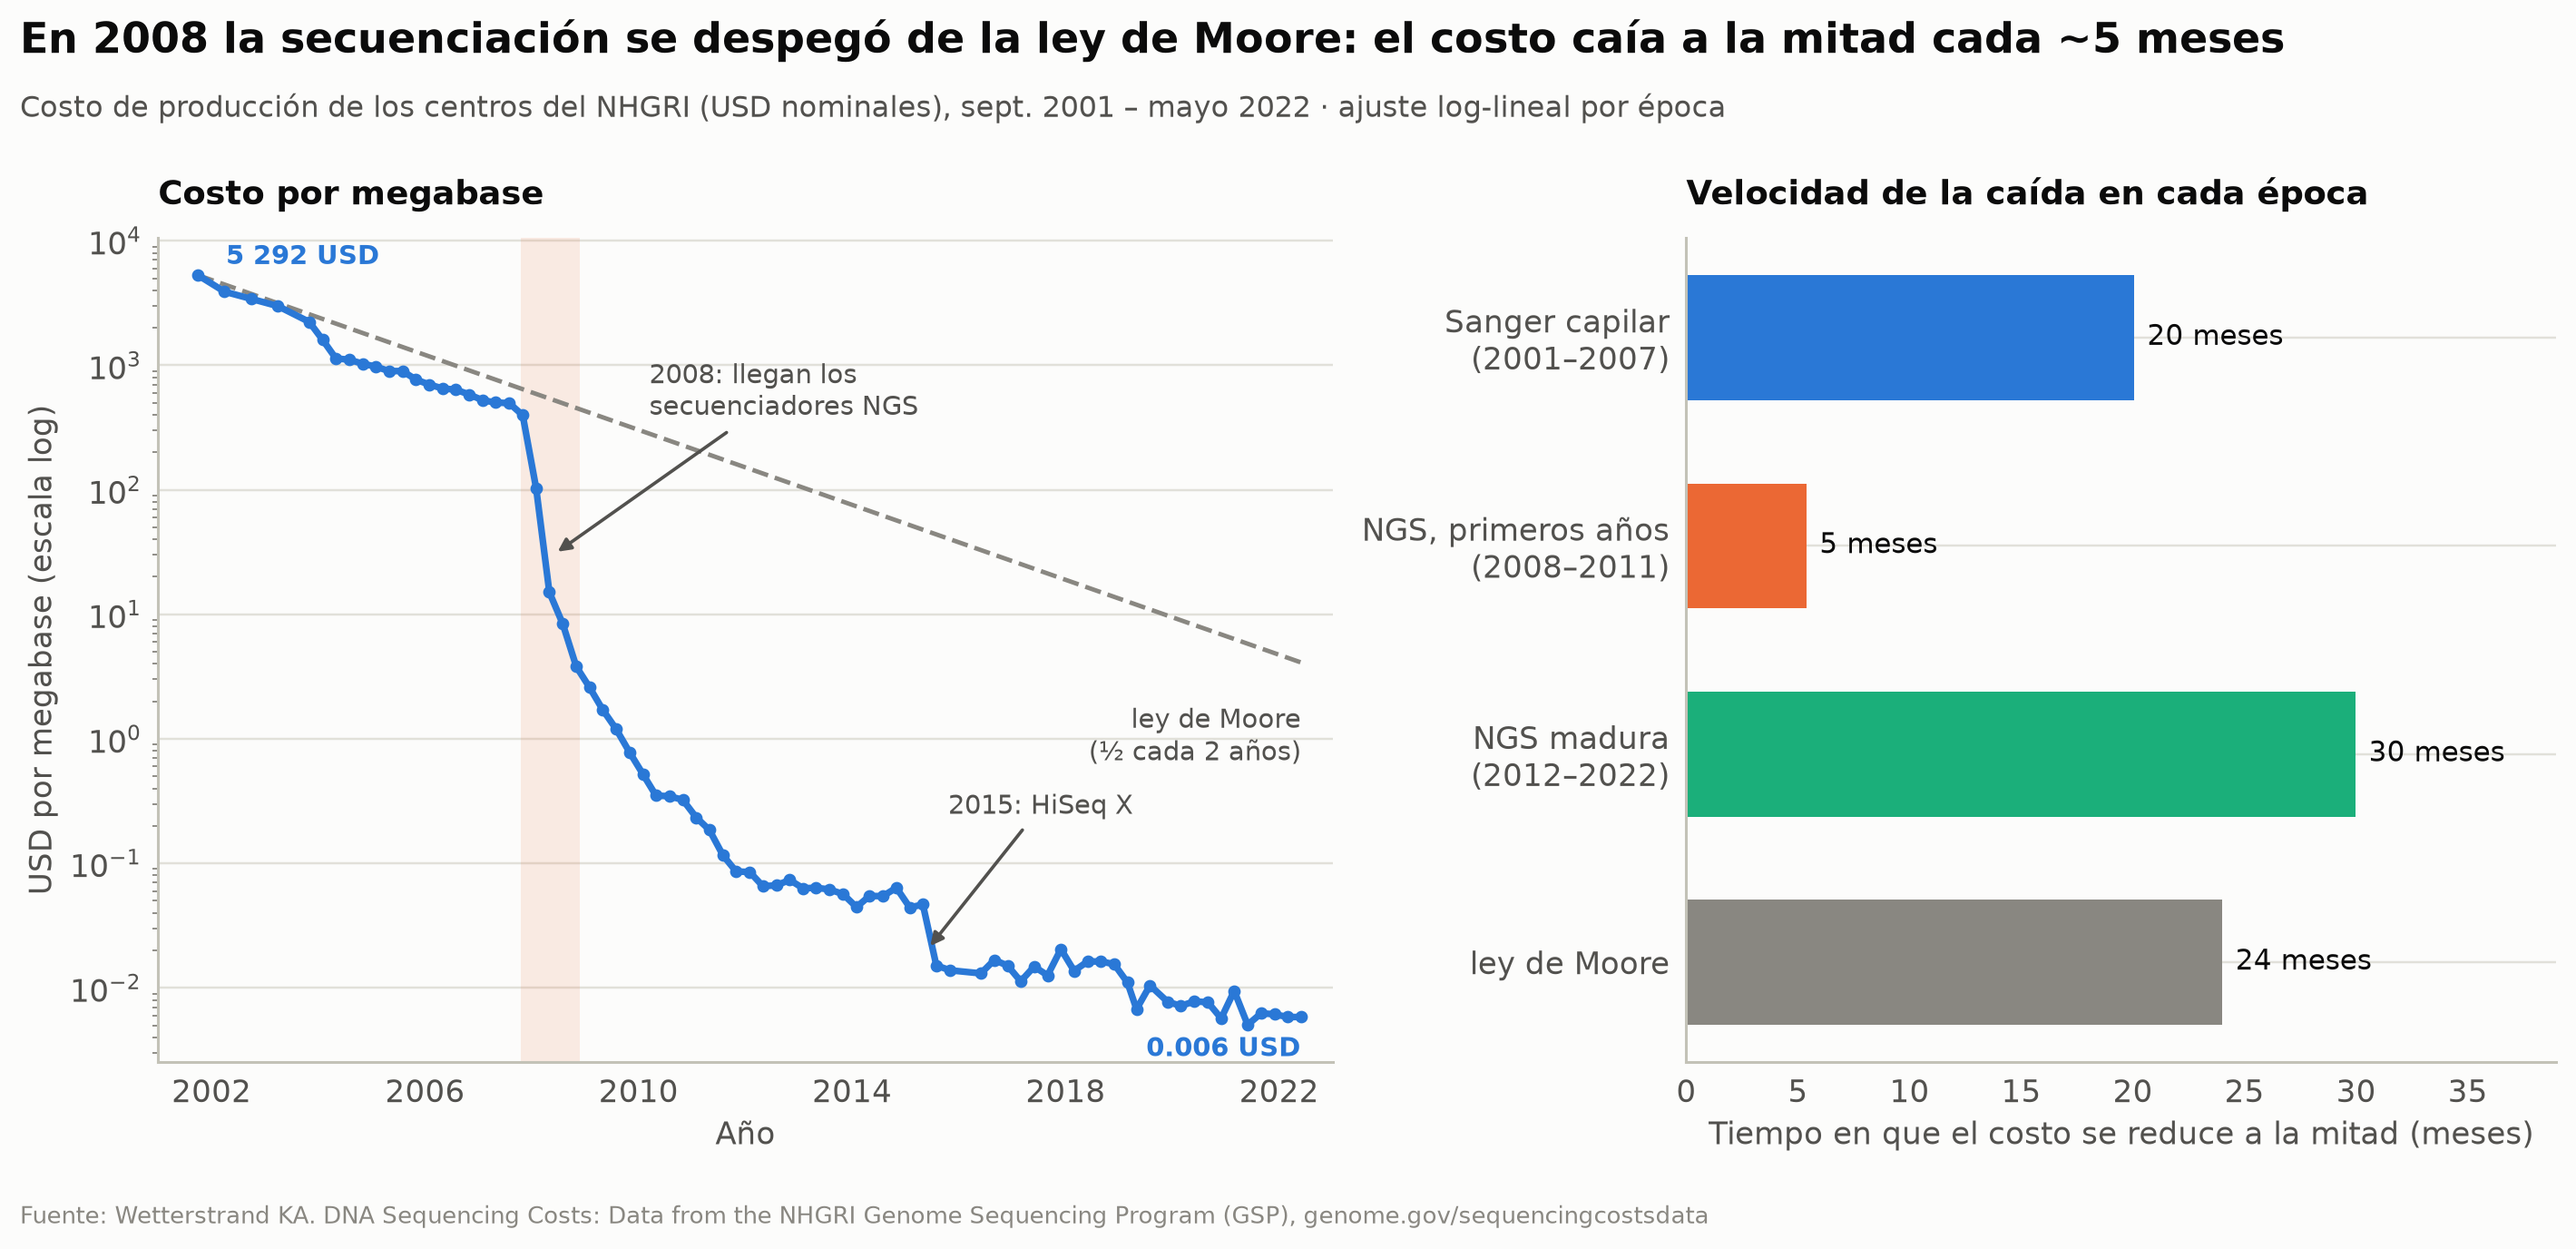

In [3]:
t0, c0 = costs.year.iloc[0], costs.cost_per_mb_usd.iloc[0]
tt = np.linspace(t0, costs.year.max(), 100)
moore = c0 * 2 ** (-(tt - t0) / 2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw=dict(width_ratios=[1.35, 1]))
ax = axes[0]
ax.plot(tt, moore, color=ec.MUTED, lw=1.6, ls="--")
ax.text(tt[-1], moore[-1] / 2.2, "ley de Moore\n(½ cada 2 años)", ha="right", va="top", fontsize=9.5, color=ec.INK_2)
ax.plot(costs.year, costs.cost_per_mb_usd, color=ec.BLUE, lw=2.4, marker="o", ms=3.5)
ax.set_yscale("log"); ax.set_xlim(2001, 2023)
ax.axvspan(2007.8, 2008.9, color=ec.ORANGE, alpha=0.12, lw=0)
ax.annotate("2008: llegan los\nsecuenciadores NGS", xy=(2008.4, 30), xytext=(2010.2, 400), fontsize=9.5,
            color=ec.INK_2, arrowprops=dict(arrowstyle="-|>", color=ec.INK_2, lw=1.2))
ax.annotate("2015: HiSeq X", xy=(2015.4, 0.02), xytext=(2015.8, 0.25), fontsize=9.5, color=ec.INK_2,
            arrowprops=dict(arrowstyle="-|>", color=ec.INK_2, lw=1.2))
ax.annotate("5 292 USD", (2001.75, 5292), xytext=(10, 4), textcoords="offset points", ha="left", fontsize=9.5,
            color=ec.BLUE, fontweight="bold")
ax.annotate("0.006 USD", (2022.4, 0.0058), xytext=(0, -14), textcoords="offset points", ha="right", fontsize=9.5,
            color=ec.BLUE, fontweight="bold")
ax.set_xticks(range(2002, 2023, 4))
ax.set_ylabel("USD por megabase (escala log)"); ax.set_xlabel("Año")
ax.set_title("Costo por megabase", loc="left", fontsize=12)

ax = axes[1]
labels, vals = [], []
for name, df in eras.items():
    labels.append(name.replace(" (", "\n(")); vals.append(halving_time(df)[0] * 12)
labels.append("ley de Moore"); vals.append(24)
cols = [ec.BLUE, ec.ORANGE, ec.AQUA, ec.MUTED]
ax.barh(labels[::-1], vals[::-1], color=cols[::-1], height=0.6)
for i, v in enumerate(vals[::-1]):
    ax.text(v + 0.6, i, f"{v:.0f} meses", va="center", fontsize=10, color=ec.INK)
ax.set_xlabel("Tiempo en que el costo se reduce a la mitad (meses)"); ax.set_xlim(0, max(vals) * 1.3)
ax.set_title("Velocidad de la caída en cada época", loc="left", fontsize=12)
ec.fig_title(fig, "En 2008 la secuenciación se despegó de la ley de Moore: el costo caía a la mitad cada ~5 meses",
             "Costo de producción de los centros del NHGRI (USD nominales), sept. 2001 – mayo 2022 · ajuste log-lineal por época")
ec.source(fig, "Fuente: Wetterstrand KA. DNA Sequencing Costs: Data from the NHGRI Genome Sequencing Program (GSP), genome.gov/sequencingcostsdata")
plt.tight_layout(); plt.show()

> 🔎 **Qué observamos.** Hasta 2007, con Sanger capilar, el costo bajaba a la mitad cada ~20 meses, un ritmo parecido
> al de Moore. Entre 2008 y 2011, con la llegada de 454, Illumina (Solexa) y SOLiD, la mitad se alcanzaba en unos
> **cinco meses**: el cambio no fue un chip más rápido, sino una **idea nueva**, leer millones de moléculas a la vez en
> lugar de 96 capilares. Desde 2012 la caída es lenta y escalonada (la HiSeq X de 2015, la NovaSeq de 2017). La gráfica
> tiene un límite: la tabla que usamos termina en mayo de 2022, y no mide la **longitud** ni la **exactitud** de las lecturas,
> que es lo que realmente distingue a las tecnologías de este módulo.

✅ **Compruebe su comprensión.** Con los datos de 2022 (0.0058 USD/Mb), ¿cuánto costaría secuenciar el genoma de
SARS-CoV-2 (0.03 Mb) a 1 000× de cobertura? (Respuesta: $0.03 \times 1\,000 \times 0.0058 \approx 0.17$ USD; en la
práctica el costo lo domina la preparación de la librería, no la secuenciación, y por eso se agrupan cientos de muestras
en una misma corrida con **índices**.)

## 2. Sanger: terminadores didesoxi y el electroferograma; pirosecuenciación (454, Ion Torrent) y los homopolímeros

En 1977 Frederick Sanger, Steve Nicklen y Alan Coulson publicaron un método tan robusto que dominó la secuenciación
durante 30 años y con el que se leyó el primer genoma humano. Hoy se sigue usando para **confirmar** variantes, verificar
clones y plásmidos, y como estándar de oro para leer un fragmento concreto (un amplicón de PCR o un clon), del que el capilar lee una
población clonal de millones de copias idénticas.

La idea: una ADN polimerasa copia el molde a partir de un cebador. En el tubo hay los cuatro **dNTP** normales y, en
pequeña proporción, **ddNTP** (didesoxinucleótidos): nucleótidos a los que les falta el grupo **3′-OH**. Cuando la
polimerasa incorpora un ddNTP, **no puede añadir el siguiente nucleótido**: la cadena termina. Como la incorporación del
ddNTP es al azar, al final hay copias que terminan en **cada posición** del molde. En la versión moderna (*dye
terminators*), cada uno de los cuatro ddNTP lleva un **fluoróforo de distinto color**.

Los fragmentos se separan por tamaño en un **capilar** con un polímero (electroforesis): los cortos avanzan más rápido. Un
láser al final del capilar excita los fluoróforos y un detector registra, en el tiempo, la intensidad de los cuatro
colores. Ese registro es el **electroferograma** (o cromatograma), y cada pico es una posición del molde. Es como una
carrera de corredores de tallas distintas: los más pequeños llegan primero, y el color de la camiseta de cada uno dice con
qué base terminó.

### ¿Cuántos fragmentos hay de cada longitud?

Pensemos primero en una sola base, digamos la **C**, como en las cuatro reacciones separadas del artículo original de
Sanger (una por ddNTP). Cada vez que la polimerasa llega frente a una posición del molde que pide una C, "tira una
moneda muy cargada": casi siempre pone el dCTP normal y sigue, pero con una probabilidad pequeña $r$ pone el ddCTP y se
detiene. Los fragmentos que terminan en C sólo "ven" las C del molde; las demás bases las atraviesan sin riesgo.

Sea $K$ el número de apariciones de la base $b$ que la polimerasa atraviesa hasta terminar (incluida la última). Si las
incorporaciones son independientes, $K$ sigue una distribución **geométrica** (ecuación 6.1 del libro):

$$
P(K = k) \;=\; (1 - r)^{k - 1}\, r, \qquad k = 1, 2, \dots
\qquad\qquad
\mathbb{E}[K] = \frac{1}{r}
$$

Como cada base aparece, en promedio, una vez cada cuatro posiciones, la señal de los fragmentos que terminan cerca de la
posición $\ell$ decae aproximadamente como

$$
\frac{S(\ell)}{S(0)} \;\approx\; (1 - r)^{\ell/4}.
$$

| Símbolo | Significado |
|---|---|
| $r$ | probabilidad de terminación **por aparición** de la base $b$ (depende del cociente ddNTP/dNTP y de la preferencia de la enzima) |
| $K$ | número de apariciones de $b$ que la polimerasa atraviesa hasta terminar (incluida la última) |
| $k$ | valor concreto de $K$ |
| $\ell$ | posición en el molde, en bases desde el cebador ($\ell \approx 4k$) |
| $(1-r)^{k-1}$ | probabilidad de **no** haber terminado en las $k - 1$ apariciones previas |

Si se prefiere pensar "por posición", la tasa equivalente es $r' \approx r/4$: el fragmento sobrevive a cada posición con
probabilidad $\approx 1 - r/4$, y $(1 - r/4)^{\ell} \approx (1-r)^{\ell/4}$. Es la forma que usará nuestro
simulador, porque así los cuatro canales decaen igual sin depender de la composición local del molde.

### Ejemplo a mano

| $r$ | Señal a $\ell = 400$: $(1-r)^{100}$ | Señal a $\ell = 800$: $(1-r)^{200}$ |
|---|---|---|
| 0.005 | $0.995^{100} = 0.61$ (61 %) | $0.995^{200} = 0.37$ (37 %) |
| 0.01 | $0.99^{100} = 0.37$ (37 %) | $0.99^{200} = 0.13$ (13 %) |

Con $r = 0.01$, a las 800 bases queda sólo el **13 %** de la intensidad inicial. Aumentar $r$ produce más fragmentos
cortos (más señal al principio); disminuirlo alarga la lectura pero debilita todas las bandas. Además, los picos se
**ensanchan** con la longitud (la difusión en el capilar), y la diferencia de movilidad entre $\ell$ y $\ell + 1$ bases es
cada vez menor. Ambos efectos juntos explican por qué una lectura de Sanger rinde, en el uso rutinario, **400–800 bases**
de buena calidad (hasta ~1 000 en capilares optimizados) y no más.
La escala **Phred** que conocimos en la Lección 2.1 nació justamente para dar una calidad a cada pico de estos
electroferogramas (Ewing y Green, 1998).

In [4]:
def sanger_trace(template, r=0.01, spacing=10, rng=rng):
    """Electroferograma simulado de Sanger con terminadores de colores.
    r es la probabilidad de terminación POR APARICIÓN de la base (convención del libro). Usamos la tasa equivalente
    por posición r' = r/4, de modo que la altura del pico ℓ es (1 - r')^(ℓ-1)·r' ≈ r'·(1 - r)^(ℓ/4): la misma caída
    para los cuatro canales, sin depender de la composición local. Cada pico es una gaussiana en el canal de su base,
    centrada en ℓ·spacing y con ancho creciente con ℓ. Devuelve (tiempo, matriz 4 x tiempo, alturas)."""
    n = len(template)
    t = np.arange(0, (n + 3) * spacing)
    signal = np.zeros((4, len(t)))
    ell = np.arange(1, n + 1)
    r_pos = r / 4                                         # r' ≈ r/4: cada base aparece ~1 de cada 4 posiciones
    height = (1 - r_pos) ** (ell - 1) * r_pos
    height *= rng.lognormal(0, 0.2, n)                  # variación de altura pico a pico (dependiente del contexto)
    dye = np.array([1.0, 0.8, 0.65, 0.9])                 # eficiencia distinta de cada fluoróforo (A, C, G, T)
    sigma = spacing * (0.2 + 0.0003 * ell)               # los picos se ensanchan con la longitud
    center = ell * spacing + rng.normal(0, 0.6, n).cumsum() * 0.05   # pequeñas irregularidades de movilidad
    for k, b in enumerate(template):
        c = BASES.index(b)
        signal[c] += dye[c] * height[k] * np.exp(-0.5 * ((t - center[k]) / sigma[k]) ** 2)
    signal /= height[0]
    signal += np.abs(rng.normal(0, 0.004, signal.shape))  # ruido de fondo
    return t, signal, height

def call_sanger(t, signal, spacing=10):
    """Llamado de bases ingenuo: picos de la señal máxima (normalizada por la señal local, que decae con la longitud)
    y, en cada pico, el color dominante."""
    top = signal.max(0)
    local = pd.Series(top).rolling(8 * spacing, center=True, min_periods=1).max().values
    peaks, _ = find_peaks(top / local, height=0.1, distance=int(0.5 * spacing), prominence=0.02)
    calls = "".join(BASES[signal[:, p].argmax()] for p in peaks)
    s = np.sort(signal[:, peaks], axis=0)
    purity = s[-1] / (s[-1] + s[-2])                      # qué tanto domina el color principal
    return peaks, calls, purity

SPIKE_START = 21562                                       # inicio del gen S (espiga), coordenada 0-based
template = GENOME[SPIKE_START:SPIKE_START + 1000]
t_s, sig_s, h_s = sanger_trace(template)
peaks_s, calls_s, purity_s = call_sanger(t_s, sig_s)
r_book = 0.01
print(f"Caída de la señal con r = {r_book}: a 400 pb {(1 - r_book / 4) ** 399:.2f}, a 800 pb {(1 - r_book / 4) ** 799:.2f}   "
      f"(fórmula del libro: 0.99^100 = {0.99 ** 100:.2f}, 0.99^200 = {0.99 ** 200:.2f})")
print("Molde (primeras 60):   ", template[:60])
print("Llamado (primeras 60): ", calls_s[:60])
for a, b in [(0, 300), (300, 600), (600, 800), (800, 1000)]:
    seg_true = template[a:b]
    sel = (peaks_s >= a * 10 + 5) & (peaks_s < b * 10 + 5)
    ops = align_ops(seg_true, "".join(np.array(list(calls_s))[sel]))
    print(f"posiciones {a + 1:4d}–{b:4d}: identidad = {1 - ops['distancia'] / len(seg_true):.1%}   "
          f"(sust. {ops['sustitución']}, ins. {ops['inserción']}, del. {ops['deleción']})")

Caída de la señal con r = 0.01: a 400 pb 0.37, a 800 pb 0.14   (fórmula del libro: 0.99^100 = 0.37, 0.99^200 = 0.13)
Molde (primeras 60):    ATGTTTGTTTTTCTTGTTTTATTGCCACTAGTCTCTAGTCAGTGTGTTAATCTTACAACC
Llamado (primeras 60):  ATGTTTGTTTTTCTTGTTTTATTGCCACTAGTCTCTAGTCAGTGTGTTAATCTTACAACC
posiciones    1– 300: identidad = 100.0%   (sust. 0, ins. 0, del. 0)
posiciones  301– 600: identidad = 99.7%   (sust. 0, ins. 0, del. 1)
posiciones  601– 800: identidad = 92.5%   (sust. 0, ins. 0, del. 15)
posiciones  801–1000: identidad = 82.0%   (sust. 0, ins. 0, del. 36)


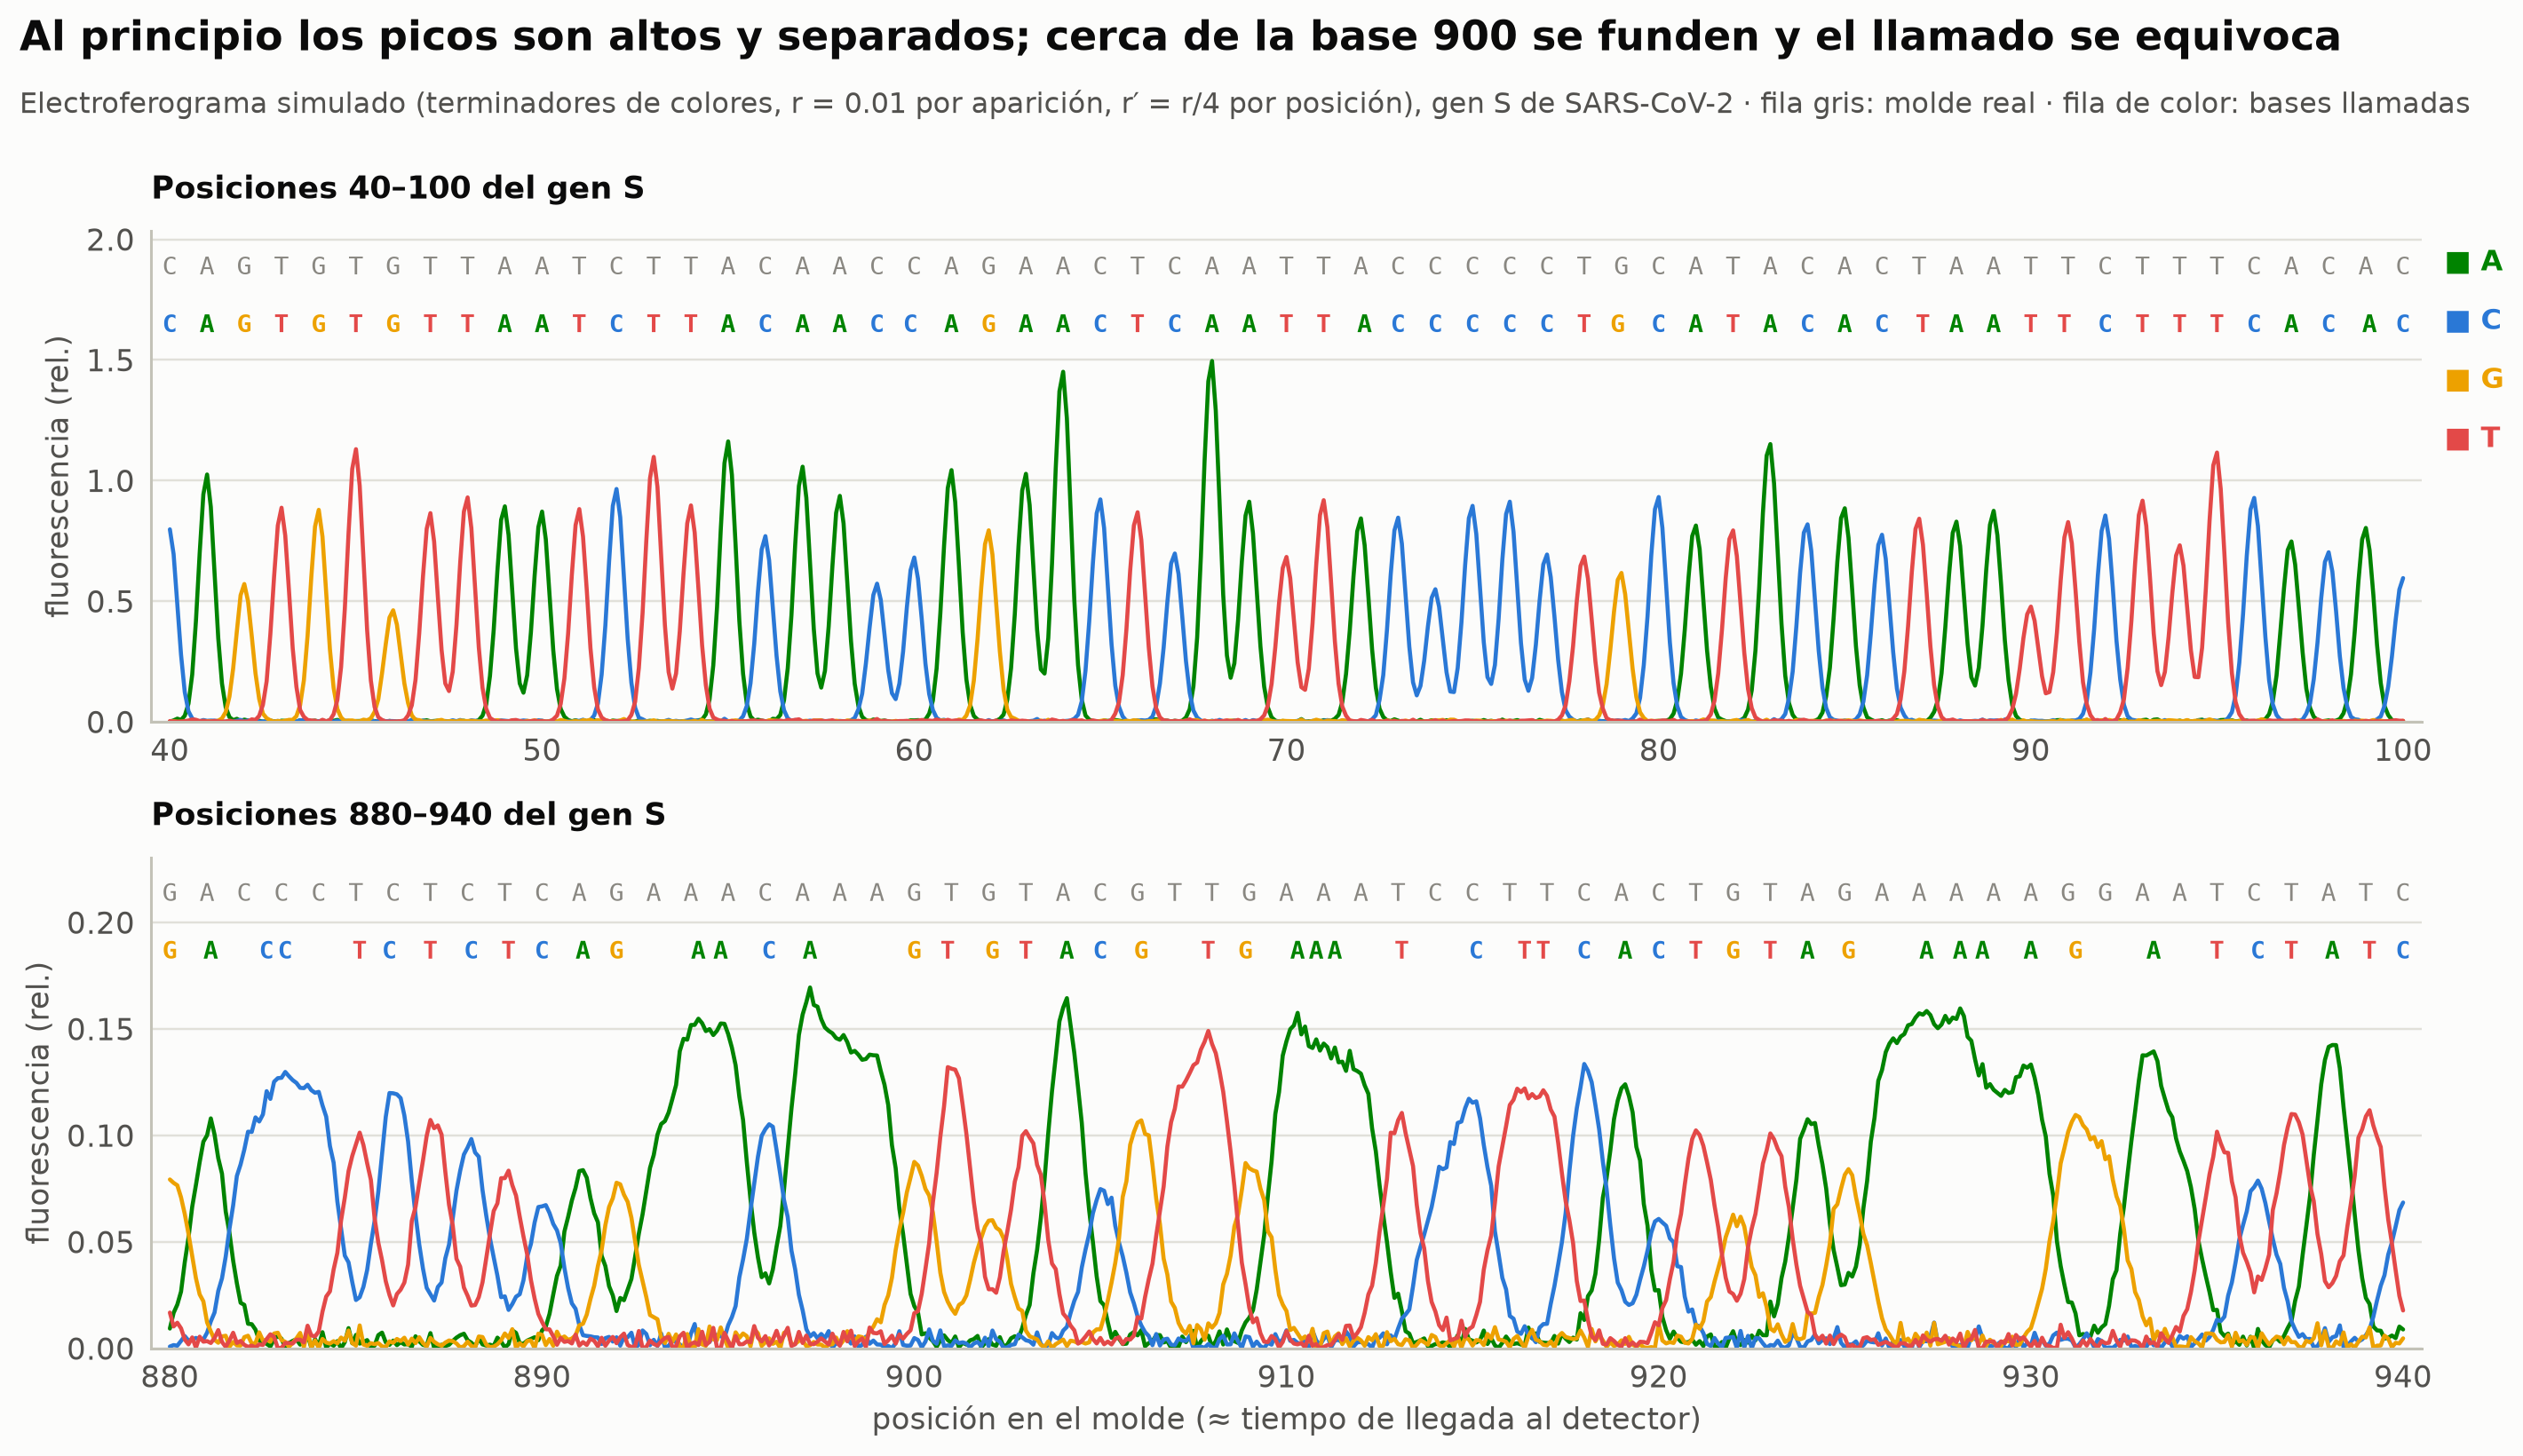

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6.8))
for ax, (a, b) in zip(axes, [(40, 100), (880, 940)]):
    sel = (t_s >= a * 10) & (t_s <= b * 10)
    for c, base in enumerate(BASES):
        ax.plot(t_s[sel] / 10, sig_s[c, sel], color=ec.NUC_COLORS[base], lw=1.5)
    ymax = sig_s[:, sel].max()
    for p in peaks_s[(peaks_s >= a * 10) & (peaks_s <= b * 10)]:
        pos = p / 10
        call = BASES[sig_s[:, p].argmax()]
        truth = template[int(round(pos)) - 1] if 0 < round(pos) <= len(template) else "?"
        ax.text(pos, ymax * 1.08, call, ha="center", fontsize=9, fontweight="bold", color=ec.NUC_COLORS[call],
                family="monospace")
    for pos in range(a, b + 1):
        ax.text(pos, ymax * 1.24, template[pos - 1], ha="center", fontsize=9, color=ec.MUTED, family="monospace")
    ax.set_ylim(0, ymax * 1.36); ax.set_xlim(a - 0.5, b + 0.5)
    ax.set_ylabel("fluorescencia (rel.)")
    ax.set_title(f"Posiciones {a}–{b} del gen S", loc="left", fontsize=11.5)
axes[1].set_xlabel("posición en el molde (≈ tiempo de llegada al detector)")
for i, base in enumerate(BASES):
    axes[0].text(1.01, 0.92 - i * 0.12, f"■ {base}", transform=axes[0].transAxes, color=ec.NUC_COLORS[base],
                 fontsize=10.5, fontweight="bold", ha="left")
ec.fig_title(fig, "Al principio los picos son altos y separados; cerca de la base 900 se funden y el llamado se equivoca",
             "Electroferograma simulado (terminadores de colores, r = 0.01 por aparición, r′ = r/4 por posición), gen S de SARS-CoV-2 · fila gris: molde real · fila de color: bases llamadas")
plt.tight_layout(); plt.show()

> 🔎 **Qué observamos.** En la primera ventana cada pico está aislado y el color dominante coincide con el molde: la
> identidad es prácticamente del 100 %. Cerca de la posición 900 los picos son anchos, se **solapan** y la señal es
> débil (compare el eje vertical): aparecen picos que no se detectan (**deleciones**) o que se cuentan dos veces
> (**inserciones**). Por eso los laboratorios secuencian cada amplicón desde **ambos extremos**. En los cromatogramas
> de los equipos ABI la G se dibuja en negro; aquí usamos los colores del curso (A verde, C azul, G amarillo, T rojo).

✅ **Compruebe su comprensión.** Si duplicamos la proporción de ddNTP ($r$ de 0.01 a 0.02), ¿las lecturas serán más
largas o más cortas? (Respuesta: más cortas; el número medio de apariciones atravesadas $\mathbb E[K] = 1/r$ baja de 100
a 50, es decir, de unas 400 a unas 200 bases, y la señal a 800 bases cae del 13 % a $0.98^{200} \approx 1.8$ %.)

### 2.1 Entre Sanger e Illumina: pirosecuenciación, 454 e Ion Torrent

La primera ruptura con Sanger fue dejar de separar fragmentos por tamaño y, en cambio, **observar la síntesis mientras
ocurre**. En la **pirosecuenciación** (Ronaghi et al., 1998), cada vez que la polimerasa incorpora un nucleótido libera
una molécula de pirofosfato (PPᵢ); una cascada de enzimas la convierte en ATP (ATP sulfurilasa) y el ATP en un destello
de luz (luciferasa). La máquina inyecta **un solo tipo de nucleótido a la vez** (un *flujo*): si hay destello, esa base
es la siguiente del molde; si no, se lava y se prueba la siguiente.

La plataforma **454** (Margulies et al., 2005) llevó esta química a gran escala: cada fragmento se amplificaba sobre una
microesfera dentro de una gota de agua en aceite (**PCR en emulsión**) y las esferas se repartían en cientos de miles de
pocillos de picolitros. En una corrida de cuatro horas leía 25 millones de bases con exactitud ≥ 99 %, y con ella se
ensambló *de novo* el genoma de *Mycoplasma genitalium*: había nacido la "nueva generación". **Ion Torrent** usa la
misma lógica de flujos, pero en lugar de luz mide el **cambio de pH** (los protones) que libera cada incorporación.

El punto débil se deduce del propio principio. Si el molde tiene un **homopolímero** como `AAAAAA`, la polimerasa
incorpora las seis A en un mismo flujo y el destello es, idealmente, seis veces más intenso. Distinguir 1 de 2 es fácil
(el doble de luz); distinguir 6 de 7 es difícil (un 17 % más), porque el ruido de la medición **crece con la señal**.

### Ejemplo a mano

Supongamos que la intensidad de un flujo con $h$ bases idénticas es $h$ más un ruido cuya desviación estándar es un 5 %
de la señal ($c = 0.05$), y que redondeamos la intensidad al entero más próximo. Nos equivocamos si el ruido supera media
unidad, es decir, si $|z| > 0.5/(c\,h)$:

| $h$ | Desviación $c\,h$ | Umbral $0.5/(c\,h)$ en desviaciones estándar | $P(\text{error en } h)$ |
|---|---|---|---|
| 1 | 0.05 | 10 | prácticamente 0 |
| 2 | 0.10 | 5 | $6 \times 10^{-7}$ |
| 4 | 0.20 | 2.5 | 0.012 |
| 6 | 0.30 | 1.67 | 0.096 |
| 8 | 0.40 | 1.25 | 0.21 |

$$
I_h \;=\; h + \eta,\quad \eta \sim \mathcal N\!\big(0,\,(c\,h)^2\big)
\qquad\qquad
P(\text{error en } h) \;=\; 2\left[1 - \Phi\!\left(\frac{0.5}{c\,h}\right)\right]
$$

| Símbolo | Significado |
|---|---|
| $h$ | longitud del homopolímero (bases idénticas incorporadas en un flujo) |
| $I_h$ | intensidad medida en ese flujo (luz en 454, pH en Ion Torrent), en unidades de "una base" |
| $c$ | ruido relativo: desviación estándar como fracción de la señal (valor ilustrativo) |
| $\Phi$ | función de distribución de la normal estándar |

Un error en $h$ no cambia una base por otra: añade o quita una copia. Por eso el error dominante de 454 e Ion Torrent son
las **inserciones y deleciones en homopolímeros**, no las sustituciones (Metzker, 2010).

homopolímero de 1: P(llamar mal la longitud) = 0
homopolímero de 2: P(llamar mal la longitud) = 5.7e-07
homopolímero de 3: P(llamar mal la longitud) = 0.00086
homopolímero de 4: P(llamar mal la longitud) = 0.012
homopolímero de 5: P(llamar mal la longitud) = 0.046
homopolímero de 6: P(llamar mal la longitud) = 0.096
homopolímero de 7: P(llamar mal la longitud) = 0.15
homopolímero de 8: P(llamar mal la longitud) = 0.21


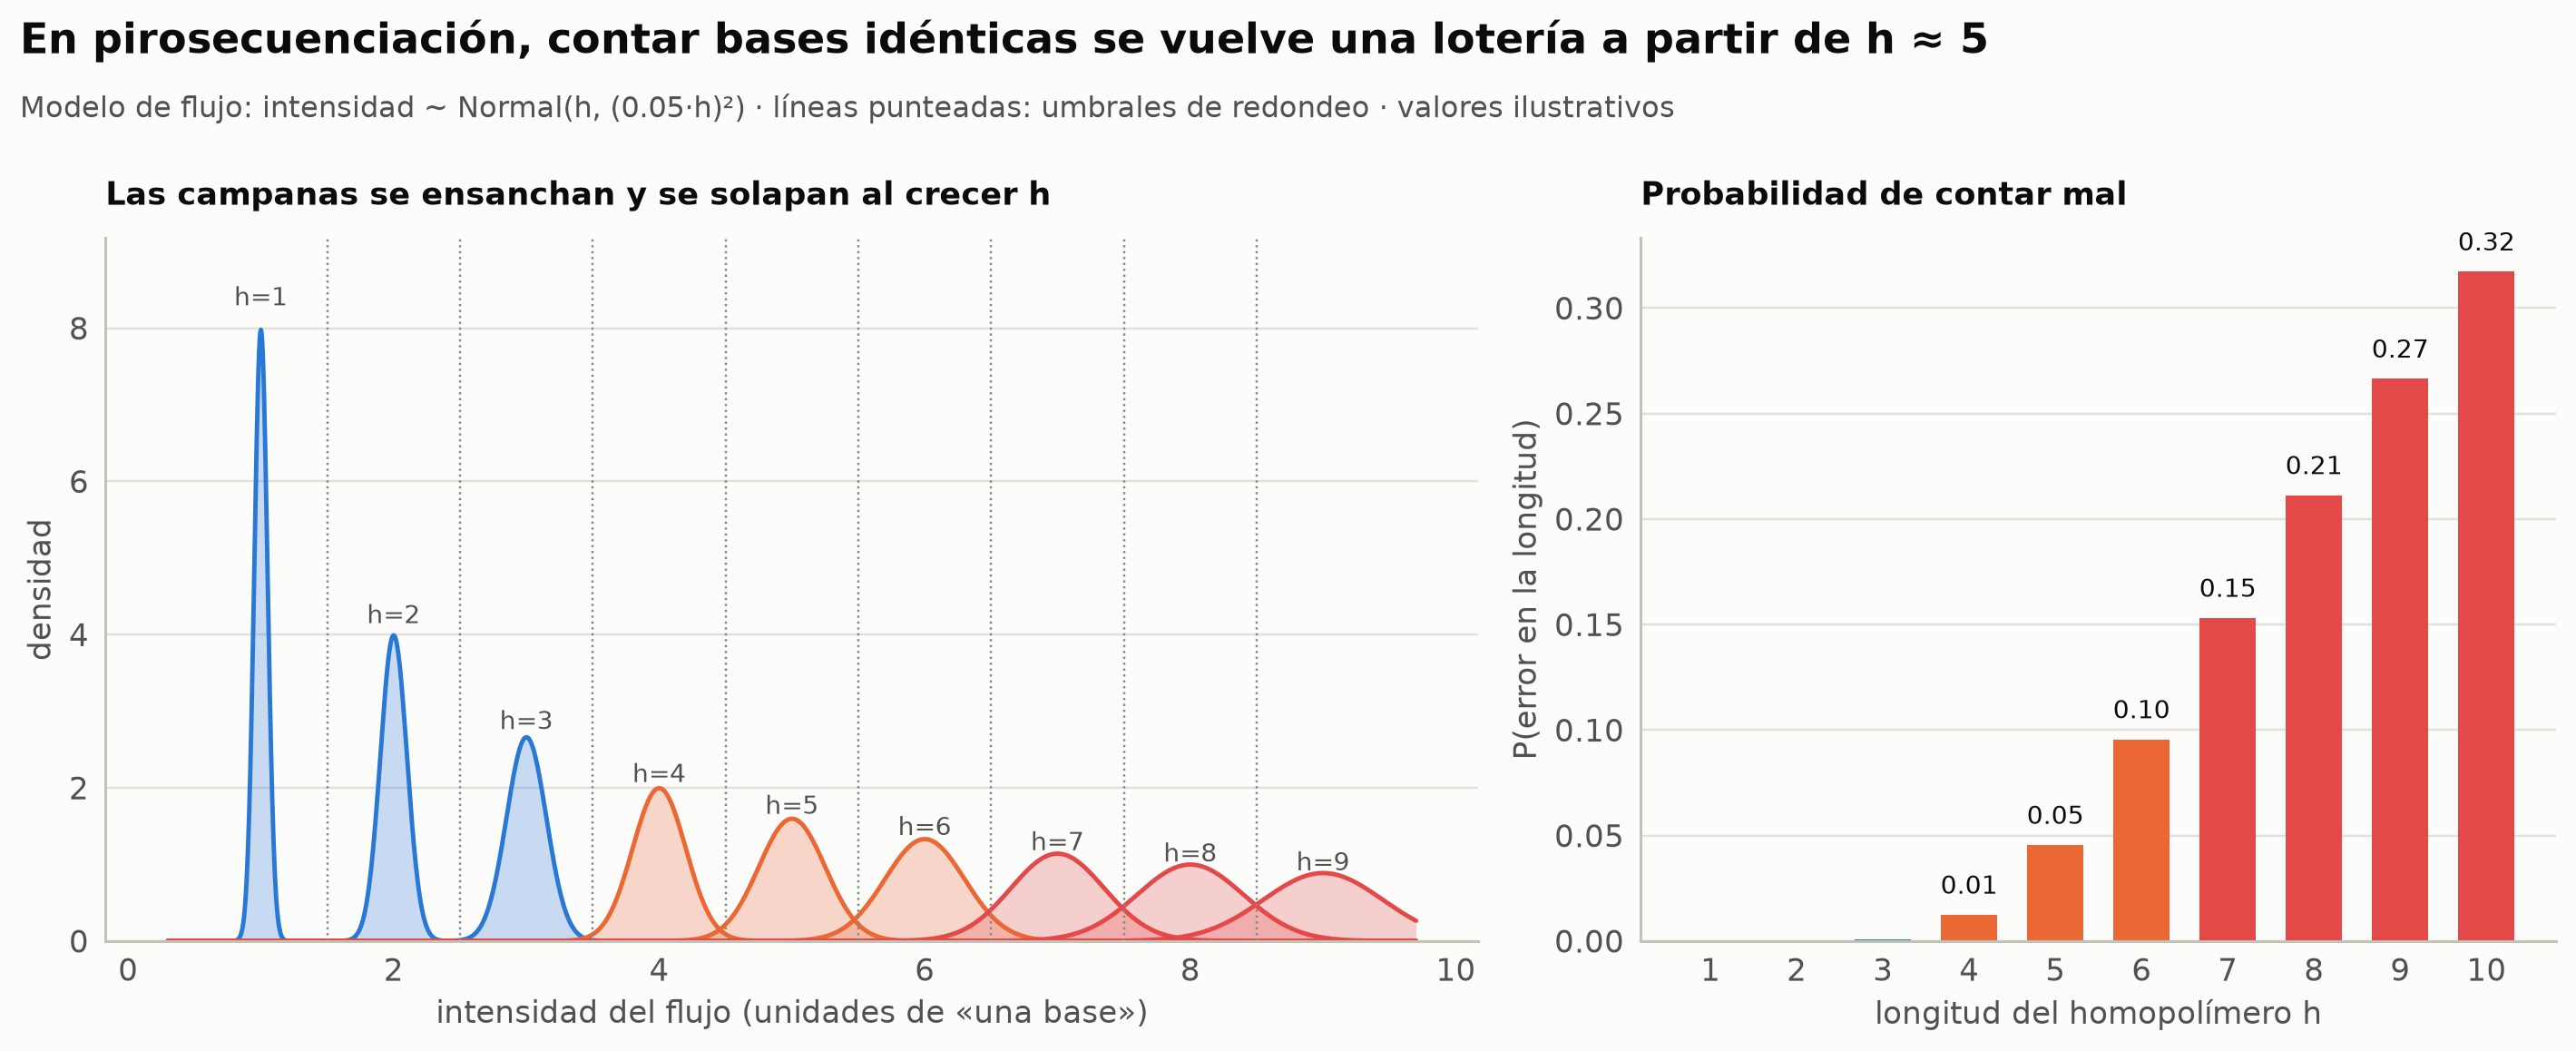

In [6]:
from scipy.stats import norm
c_noise = 0.05                                            # ruido relativo (ilustrativo)
hs = np.arange(1, 11)
p_err = 2 * (1 - norm.cdf(0.5 / (c_noise * hs)))
for h, pe in zip(hs[:8], p_err[:8]):
    print(f"homopolímero de {h}: P(llamar mal la longitud) = {pe:.2g}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw=dict(width_ratios=[1.5, 1]))
ax = axes[0]
x = np.linspace(0.3, 9.7, 2000)
for h in range(1, 10):
    col = ec.BLUE if h <= 3 else (ec.ORANGE if h <= 6 else ec.RED)
    ax.fill_between(x, norm.pdf(x, h, c_noise * h), color=col, alpha=0.25, lw=0)
    ax.plot(x, norm.pdf(x, h, c_noise * h), color=col, lw=1.6)
    ax.text(h, norm.pdf(h, h, c_noise * h) * 1.04, f"h={h}", ha="center", fontsize=9, color=ec.INK_2)
for b in np.arange(1.5, 9.5, 1):
    ax.axvline(b, color=ec.MUTED, lw=0.8, ls=":")
ax.set_xlabel("intensidad del flujo (unidades de «una base»)"); ax.set_ylabel("densidad")
ax.set_ylim(0, norm.pdf(1, 1, c_noise) * 1.15)
ax.set_title("Las campanas se ensanchan y se solapan al crecer h", loc="left", fontsize=11.5)
ax = axes[1]
ax.bar(hs, p_err, color=[ec.BLUE if h <= 3 else (ec.ORANGE if h <= 6 else ec.RED) for h in hs], width=0.65)
for h, pe in zip(hs, p_err):
    if pe > 1e-3:
        ax.text(h, pe + 0.01, f"{pe:.2f}", ha="center", fontsize=9, color=ec.INK)
ax.set_xlabel("longitud del homopolímero h"); ax.set_ylabel("P(error en la longitud)")
ax.set_xticks(hs)
ax.set_title("Probabilidad de contar mal", loc="left", fontsize=11.5)
ec.fig_title(fig, "En pirosecuenciación, contar bases idénticas se vuelve una lotería a partir de h ≈ 5",
             f"Modelo de flujo: intensidad ~ Normal(h, ({c_noise}·h)²) · líneas punteadas: umbrales de redondeo · valores ilustrativos")
plt.tight_layout(); plt.show()

> 🔎 **Qué observamos.** Para $h = 1$–$3$ las campanas son estrechas y no se tocan: el número de bases se lee sin
> dudas. A partir de $h \approx 5$ cada campana invade a sus vecinas y la probabilidad de contar una base de más o de
> menos ronda el 5 % (casi 10 % para $h = 6$ y más del 20 % para $h = 8$). El error no depende de qué base es sino de **cuántas** hay seguidas: es
> la huella física de la química por flujos. Illumina, que veremos a continuación, evita el problema incorporando
> **una sola base por ciclo** gracias a un bloqueo reversible; Nanopore (sección 7) tropieza con los homopolímeros por
> otra razón.

✅ **Compruebe su comprensión.** Si un instrumento reduce el ruido relativo a $c = 0.025$, ¿qué homopolímero tiene
ahora la misma probabilidad de error que el de 4 bases con $c = 0.05$? (Respuesta: el de 8, porque el error sólo depende
del producto $c\,h$.)

## 3. Illumina I: la librería, el puente y los clústeres

Sanger lee **una** molécula (bueno, una población de copias de un mismo amplicón) por capilar: 96 lecturas por corrida.
La idea de Illumina, heredera de la química de Solexa (Bentley et al., 2008), es leer **cientos de millones** de
fragmentos distintos a la vez sobre una lámina de vidrio, la **celda de flujo** (*flow cell*). Para lograrlo hay que
resolver tres problemas: que cada fragmento tenga "asas" iguales para poder manipularlo, que cada fragmento se vea con una
cámara y que todos avancen al mismo ritmo, una base por ciclo.

### 3.1 Preparación de la librería

1. **Fragmentar** el ADN (con ultrasonido o con enzimas, como la *tagmentación* con transposasa) en trozos de 200–600 pb.
2. **Reparar los extremos** y añadir una **A** protuberante en el extremo 3′.
3. **Ligar adaptadores**: secuencias sintéticas conocidas que traen todo lo necesario para la máquina.
4. **Amplificar** por PCR unos pocos ciclos para enriquecer las moléculas con adaptadores en ambos extremos.

Cada molécula de la librería termina con esta estructura:

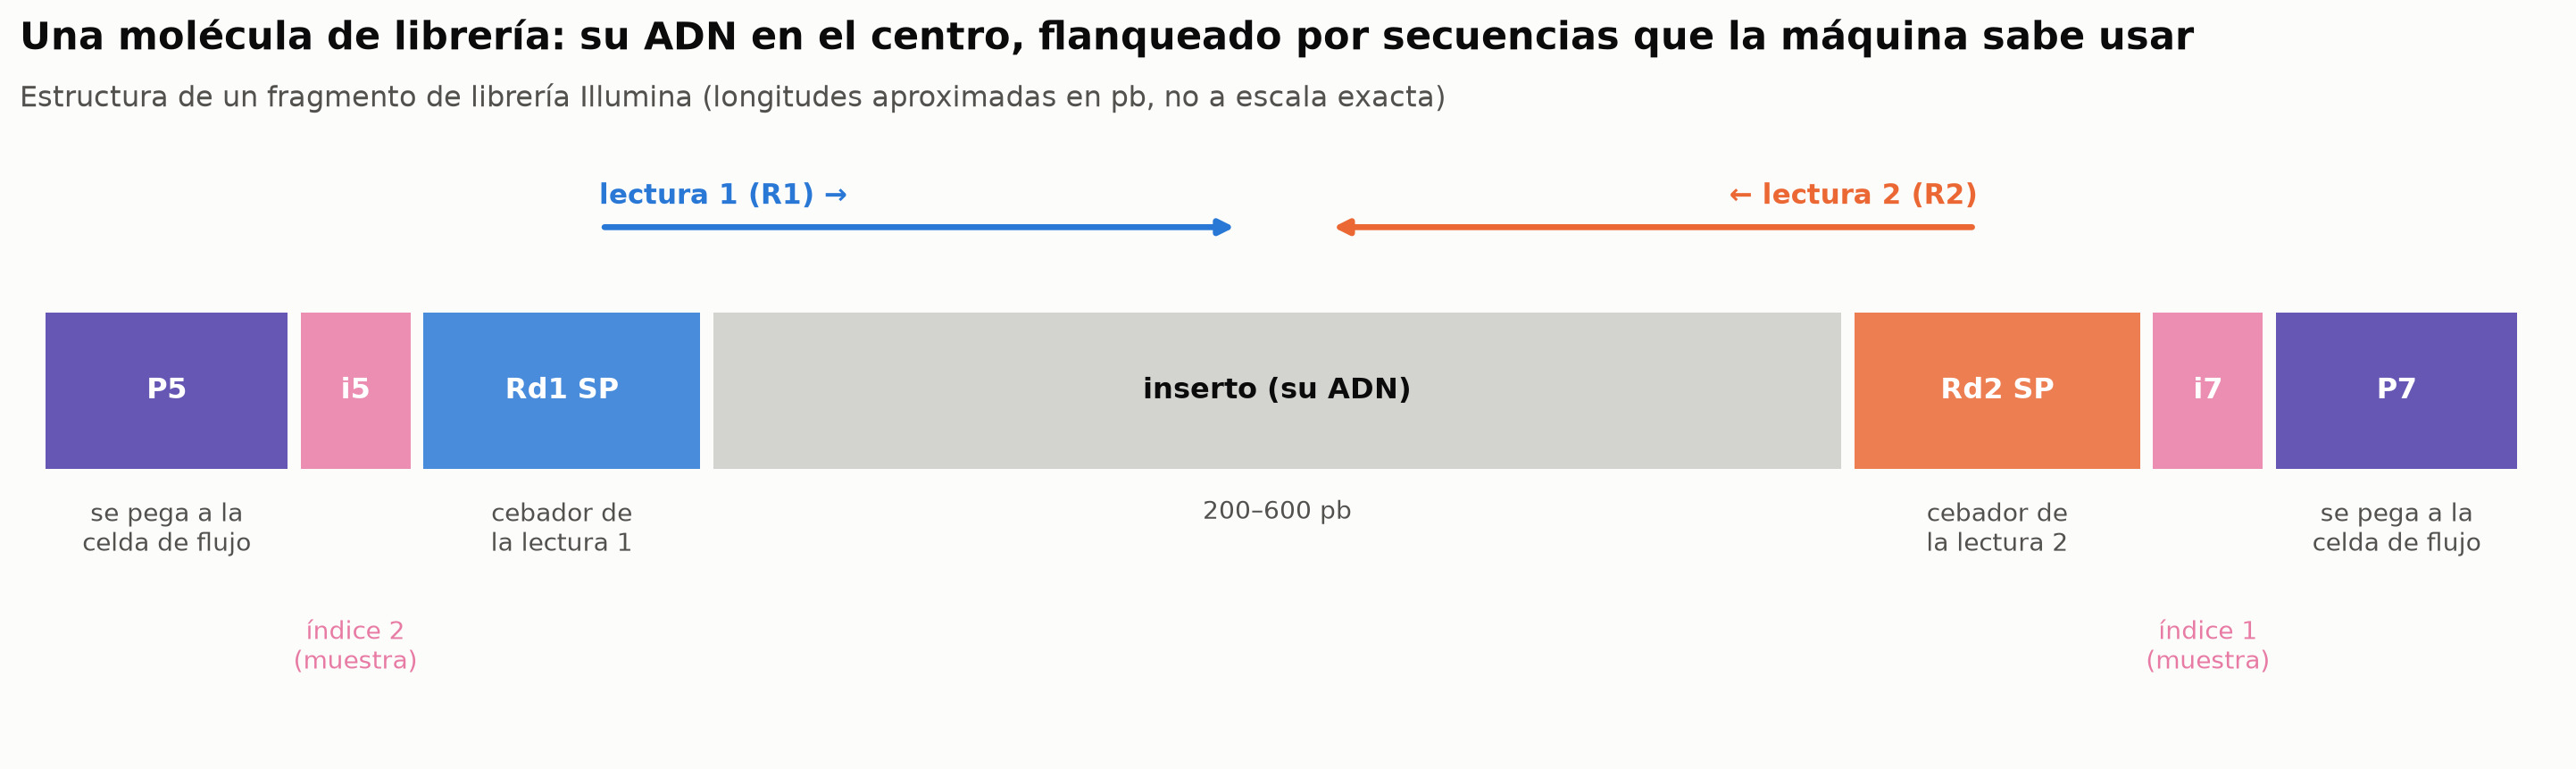

In [7]:
parts = [("P5", 29, ec.VIOLET, "se pega a la\ncelda de flujo"), ("i5", 14, ec.MAGENTA, "índice 2\n(muestra)"),
         ("Rd1 SP", 33, ec.BLUE, "cebador de\nla lectura 1"), ("inserto (su ADN)", 130, ec.MUTED, "200–600 pb"),
         ("Rd2 SP", 34, ec.ORANGE, "cebador de\nla lectura 2"), ("i7", 14, ec.MAGENTA, "índice 1\n(muestra)"),
         ("P7", 29, ec.VIOLET, "se pega a la\ncelda de flujo")]
fig, ax = plt.subplots(figsize=(13, 3.8))
x = 0
for name, w, col, note in parts:
    ax.add_patch(Rectangle((x, 0), w - 1.5, 1, fc=col, alpha=0.35 if name.startswith("inserto") else 0.85, ec="none"))
    ax.text(x + (w - 1.5) / 2, 0.5, name, ha="center", va="center", fontsize=10.5, fontweight="bold",
            color=ec.INK if name.startswith("inserto") else "white")
    ax.text(x + (w - 1.5) / 2, -0.95 if name in ("i5", "i7") else -0.2, note, ha="center", va="top", fontsize=9,
            color=ec.MAGENTA if name in ("i5", "i7") else ec.INK_2)
    x += w
ax.annotate("", (29 + 14 + 33 + 60, 1.55), (29 + 14 + 20, 1.55),
            arrowprops=dict(arrowstyle="-|>", color=ec.BLUE, lw=2.2))
ax.text(29 + 14 + 20, 1.7, "lectura 1 (R1) →", color=ec.BLUE, fontsize=10, fontweight="bold")
ax.annotate("", (x - 29 - 14 - 34 - 60, 1.55), (x - 29 - 14 - 20, 1.55),
            arrowprops=dict(arrowstyle="-|>", color=ec.ORANGE, lw=2.2))
ax.text(x - 29 - 14 - 20, 1.7, "← lectura 2 (R2)", color=ec.ORANGE, fontsize=10, fontweight="bold", ha="right")
ax.set_xlim(-3, x + 3); ax.set_ylim(-1.8, 2.2); ax.axis("off")
ec.title(ax, "Una molécula de librería: su ADN en el centro, flanqueado por secuencias que la máquina sabe usar",
         "Estructura de un fragmento de librería Illumina (longitudes aproximadas en pb, no a escala exacta)")
plt.show()

> 🔎 **Qué observamos.** Todo lo que no es gris es **sintético** y conocido. Los extremos **P5** y **P7** son
> complementarios a los oligonucleótidos que tapizan la celda de flujo; los sitios **Rd1 SP** y **Rd2 SP** son donde se
> pegan los cebadores de secuenciación; los **índices** i5/i7 son "códigos de barras" de 8–10 bases que identifican de
> qué muestra viene cada fragmento, para mezclar cientos de muestras en una corrida y separarlas después
> (*demultiplexing*). Si el inserto es más corto que la lectura, la máquina sigue leyendo **dentro del adaptador**:
> por eso el recorte de adaptadores es un paso obligatorio del control de calidad.

### 3.2 Amplificación en puente: de una molécula a un clúster

Una sola molécula fluorescente es demasiado tenue para fotografiarla. Por eso, cada fragmento que se pega a la celda de
flujo se copia en su sitio: su extremo libre se dobla y se engancha a un oligo vecino formando un **puente**, la
polimerasa lo copia, el puente se desnaturaliza y el proceso se repite. Después de unas 30–35 rondas quedan unas
**1 000 copias idénticas** agrupadas en un punto de ~1 µm: un **clúster**. Todas las copias emiten el mismo color al
mismo tiempo, y ese coro sí se ve con la cámara.

$$
N_{\text{copias}} \;\approx\; 2^{\,n} \quad\text{(sin límite de espacio)}
\qquad\qquad
2^{10} = 1\,024
$$

Con sólo 10 duplicaciones efectivas ya tenemos un millar de copias; en la práctica el crecimiento se frena porque el
clúster se queda sin oligos libres a su alrededor. En las celdas **con patrón** (*patterned flow cells*, NovaSeq) cada
clúster crece en un pocillo de posición fija, y así caben miles de millones por celda.

## 4. Illumina II: secuenciación por síntesis y llamado de bases

Con los clústeres listos, empieza la **secuenciación por síntesis** (*sequencing by synthesis*, **SBS**). Cada ciclo tiene
cuatro pasos:

1. **Incorporar.** Se inundan los clústeres con los cuatro nucleótidos modificados y la polimerasa. Cada nucleótido tiene
   el **3′-OH bloqueado** (un *terminador reversible*) y un **fluoróforo** unido a la base. La polimerasa añade **una sola**
   base en cada hebra y se detiene: el bloqueo le impide seguir.
2. **Lavar** los nucleótidos que sobraron.
3. **Fotografiar** la celda: la cámara registra el color de cada clúster.
4. **Desbloquear.** Un reactivo corta el fluoróforo y el bloqueo, y el 3′-OH queda libre para el siguiente ciclo.

A diferencia de Sanger, aquí el terminador es **reversible**: la cadena no muere, sólo hace una pausa. Tras 150 ciclos
tenemos, para cada clúster, una serie de 150 fotografías: esa es la lectura.

### Cuatro colores o dos colores

* **4 colores** (MiSeq, HiSeq): un fluoróforo distinto por base y cuatro imágenes por ciclo.
* **2 colores** (NextSeq, NovaSeq, iSeq): sólo dos imágenes por ciclo, roja y verde. **C** se marca en rojo, **T** en verde,
  **A** con ambos, y **G no lleva marca**: se reconoce porque el clúster se queda **oscuro**. Es más rápido y barato
  (la mitad de las fotos), a cambio de una consecuencia curiosa que veremos enseguida.

| Base | 4 colores | 2 colores (rojo, verde) |
|---|---|---|
| A | canal A | (1, 1) → se ve amarilla |
| C | canal C | (1, 0) → roja |
| G | canal G | (0, 0) → **oscura** |
| T | canal T | (0, 1) → verde |

### El llamado de bases, a mano

Supongamos que en un ciclo un clúster da, en unidades arbitrarias, $I = (I_A, I_C, I_G, I_T) = (0.05, 0.08, 0.91, 0.12)$.
Se llama la base con mayor intensidad (**G**) y, como medida de confianza, se usa la **pureza** (*chastity*) de Illumina:

$$
\text{pureza} \;=\; \frac{I_{(1)}}{I_{(1)} + I_{(2)}} \;=\; \frac{0.91}{0.91 + 0.12} = 0.88
$$

| Símbolo | Significado |
|---|---|
| $I_{(1)}, I_{(2)}$ | la mayor y la segunda mayor intensidad del clúster en ese ciclo |
| pureza | 1 = un solo color limpio; 0.5 = dos colores empatados (base dudosa) |

Un clúster que en los primeros 25 ciclos tiene pureza < 0.6 más de una vez se descarta ("*passing filter*"), y la pureza,
junto con otros predictores, se calibra para producir la calidad Phred de cada base.

Construyamos una pequeña **celda de flujo virtual** con 30 clústeres. Cada uno es un fragmento del genoma de SARS-CoV-2;
el clúster 4 se "muere" en el ciclo 16 (pierde su señal, por ejemplo porque se desprendió) y el clúster 6 es tenue.

In [8]:
TILE, N_CL, N_CYC = 64, 30, 30
yy, xx = np.mgrid[0:TILE, 0:TILE]
# posiciones de los clústeres, separadas al menos 7 píxeles
xy = []
while len(xy) < N_CL:
    p = rng.uniform(5, TILE - 5, 2)
    if all(np.hypot(*(p - q)) > 7 for q in xy):
        xy.append(p)
xy = np.array(xy)
spots = np.exp(-((xx[None] - xy[:, 0, None, None]) ** 2 + (yy[None] - xy[:, 1, None, None]) ** 2) / (2 * 1.6 ** 2))

cl_starts = rng.integers(0, len(GENOME) - 60, N_CL)
cl_truth = [GENOME[s:s + N_CYC] for s in cl_starts]
onehot = np.array([[np.eye(4)[BASES.index(b)] for b in seq] for seq in cl_truth])      # (clúster, ciclo, base)
bright = rng.lognormal(0, 0.15, N_CL); bright[5] = 0.42                                   # el clúster 6 es tenue
alive = np.ones((N_CL, N_CYC)); alive[3, 15:] = 0.0                                       # el clúster 4 muere en el ciclo 16
cyc_decay = 0.99 ** np.arange(N_CYC)                                                      # la señal baja un poco cada ciclo
I4 = onehot * (bright[:, None] * alive * cyc_decay)[:, :, None]
I4 = np.clip(I4 + rng.normal(0, 0.04, I4.shape), 0, None)                                 # ruido de la cámara
# equipo de 2 colores: cada clúster produce dos intensidades, cada una con su propio ruido
clean = onehot * (bright[:, None] * alive * cyc_decay)[:, :, None]
red = np.clip(clean[:, :, 0] + clean[:, :, 1] + rng.normal(0, 0.04, clean.shape[:2]), 0, None)     # A y C: rojo
green = np.clip(clean[:, :, 0] + clean[:, :, 3] + rng.normal(0, 0.04, clean.shape[:2]), 0, None)   # A y T: verde

def call_4color(I, floor=0.15):
    """Base = canal más brillante; 'N' si ningún canal supera el umbral."""
    calls = np.array(list(BASES))[I.argmax(-1)]
    calls[I.max(-1) < floor] = "N"
    return calls

def call_2color(r, g, thr=0.25):
    """A = rojo y verde; C = sólo rojo; T = sólo verde; G = ninguno (oscuro)."""
    on_r, on_g = r > thr, g > thr
    return np.where(on_r & on_g, "A", np.where(on_r, "C", np.where(on_g, "T", "G")))

calls4, calls2 = call_4color(I4), call_2color(red, green)
for k in (0, 3, 5):
    print(f"clúster {k + 1}: verdad   {cl_truth[k]}")
    print(f"           4 colores {''.join(calls4[k])}")
    print(f"           2 colores {''.join(calls2[k])}")
tail2 = "".join(calls2[3, 15:])
assert set(tail2) == {"G"}, "el clúster muerto debería leerse como poli-G en 2 colores"
print("\nCola del clúster 4 en 2 colores:", tail2, "← poli-G")

clúster 1: verdad   ATTATGACATGGTTGGATATGGTTGATACT
           4 colores ATTATGACATGGTTGGATATGGTTGATACT
           2 colores ATTATGACATGGTTGGATATGGTTGATACT
clúster 4: verdad   GGAAAAGATGGCTGATCAAGCTATGACCCA
           4 colores GGAAAAGATGGCTGANNNNNNNNNNNNNNN
           2 colores GGAAAAGATGGCTGAGGGGGGGGGGGGGGG
clúster 6: verdad   TATTGGCCTAGCTCTCTACTACCCTTCTGC
           4 colores TATTGGCCTAGCTCTCTACTACCCTTCTGC
           2 colores TATTGGCCTAGCTCTCTACTACCCTTCTGC

Cola del clúster 4 en 2 colores: GGGGGGGGGGGGGGG ← poli-G


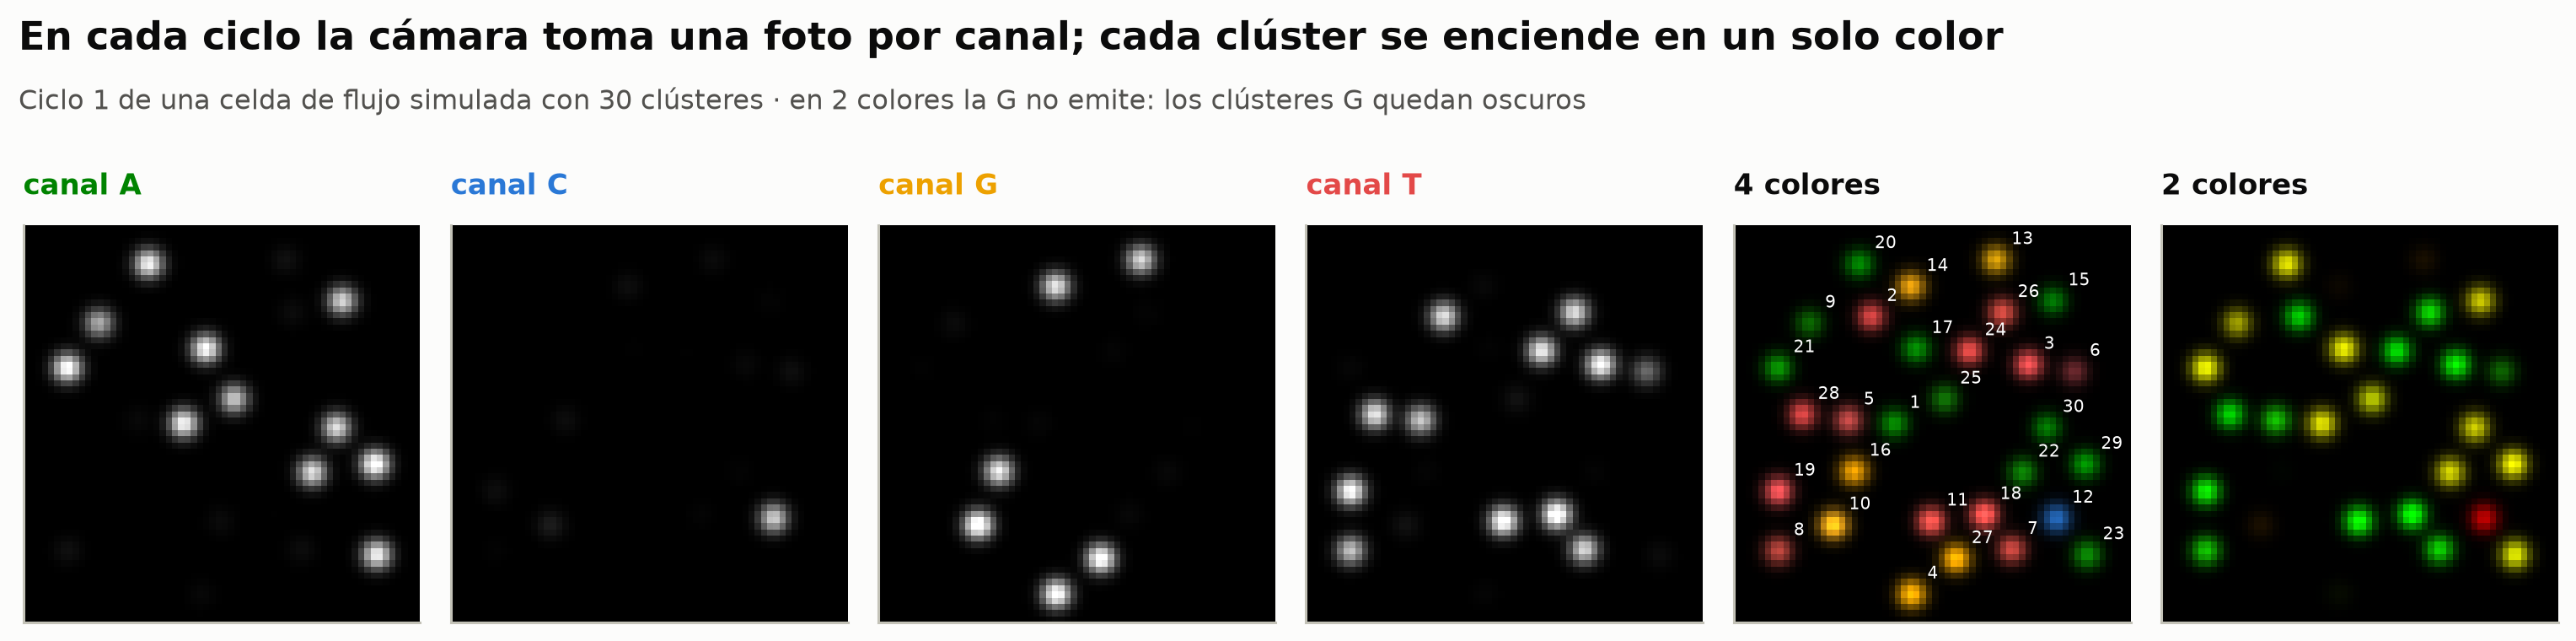

In [9]:
def tile_rgb(I, mode):
    """Imagen compuesta de la celda en un ciclo. I: intensidades (clúster, 4)."""
    if mode == 4:
        cols = np.array([to_rgb(ec.NUC_COLORS[b]) for b in BASES])        # colores del curso para cada canal
        img = np.einsum("khw,kc,cr->hwr", spots, I, cols)
    else:
        r, g = I[:, 0] + I[:, 1], I[:, 0] + I[:, 3]
        img = np.stack([np.einsum("khw,k->hw", spots, r), np.einsum("khw,k->hw", spots, g),
                        np.zeros((TILE, TILE))], -1) * 0.85
    return np.clip(img * 1.1, 0, 1)

c = 0
fig, axes = plt.subplots(1, 6, figsize=(14, 3.1))
for j, b in enumerate(BASES):
    axes[j].imshow(np.einsum("khw,k->hw", spots, I4[:, c, j]), cmap="gray", vmin=0, vmax=1)
    axes[j].set_title(f"canal {b}", color=ec.NUC_COLORS[b], fontsize=11, fontweight="bold")
axes[4].imshow(tile_rgb(I4[:, c], 4)); axes[4].set_title("4 colores", fontsize=11)
axes[5].imshow(tile_rgb(I4[:, c], 2)); axes[5].set_title("2 colores", fontsize=11)
for k in range(N_CL):
    axes[4].text(xy[k, 0] + 2.5, xy[k, 1] - 2.5, str(k + 1), color="white", fontsize=6.5)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
ec.fig_title(fig, "En cada ciclo la cámara toma una foto por canal; cada clúster se enciende en un solo color",
             "Ciclo 1 de una celda de flujo simulada con 30 clústeres · en 2 colores la G no emite: los clústeres G quedan oscuros")
plt.tight_layout(); plt.show()

> 🤔 **Antes de ejecutar, prediga:** en la animación, el clúster 4 pierde toda su señal en el ciclo 16. ¿Qué bases
> "leerá" el equipo de 4 colores a partir de ese ciclo? ¿Y el de 2 colores?

![Secuenciación por síntesis: en cada ciclo cada clúster se enciende con el color de la base incorporada; a la derecha, las lecturas crecen una base por ciclo](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-06-ngs/6.1_sbs_ciclos.gif)

*Secuenciación por síntesis: en cada ciclo cada clúster se enciende con el color de la base incorporada; a la derecha, las lecturas crecen una base por ciclo*

In [10]:
SHOW = [0, 1, 2, 3, 4, 5, 6, 7]
fig = plt.figure(figsize=(13.5, 5.2))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.55], wspace=0.08)
ax4, ax2, axt = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

def update(f):
    for ax in (ax4, ax2, axt):
        ax.clear()
    ax4.imshow(tile_rgb(I4[:, f], 4)); ax2.imshow(tile_rgb(I4[:, f], 2))
    for ax, t in ((ax4, "4 colores"), (ax2, "2 colores (rojo/verde)")):
        ax.set_xticks([]); ax.set_yticks([]); ax.set_title(t, fontsize=11, loc="left")
        for k in SHOW:
            ax.text(xy[k, 0] + 2.3, xy[k, 1] - 2.3, str(k + 1), color="white", fontsize=8, fontweight="bold")
    axt.set_xlim(0, N_CYC + 7); axt.set_ylim(len(SHOW) * 2 + 1, -1.5); axt.axis("off")
    axt.text(0, -1.2, f"Ciclo {f + 1} de {N_CYC}", fontsize=13, fontweight="bold", color=ec.INK)
    for row, k in enumerate(SHOW):
        y = row * 2 + 0.5
        axt.text(-0.3, y, f"{k + 1}", ha="right", va="center", fontsize=9, color=ec.INK_2, fontweight="bold")
        for j in range(f + 1):
            b4, b2 = calls4[k, j], calls2[k, j]
            axt.text(j + 0.5, y - 0.35, b4, ha="center", va="center", family="monospace", fontsize=8.5,
                     color=ec.NUC_COLORS.get(b4, ec.MUTED), fontweight="bold")
            axt.text(j + 0.5, y + 0.45, b2, ha="center", va="center", family="monospace", fontsize=8.5,
                     color=ec.NUC_COLORS.get(b2, ec.MUTED), fontweight="bold" if b2 == cl_truth[k][j] else "normal",
                     bbox=None if b2 == cl_truth[k][j] else dict(boxstyle="square,pad=0.05", fc="#f3b0ae", ec="none"))
    axt.text(N_CYC + 0.5, 0.15, "4 colores", fontsize=8.5, color=ec.INK_2, va="center")
    axt.text(N_CYC + 0.5, 0.95, "2 colores", fontsize=8.5, color=ec.INK_2, va="center")
    fig.suptitle("Secuenciación por síntesis: una base por ciclo en cada clúster (fondo rosa: llamado erróneo)",
                 x=0.01, ha="left", fontsize=12.5, fontweight="bold")
    return []

ec.animate(fig, update, frames=N_CYC, interval=450, name="6.1_sbs_ciclos")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Mientras los clústeres están sanos, ambos sistemas leen lo mismo. El clúster 4 se apaga en el
> ciclo 16: el equipo de 4 colores ve que **ningún** canal brilla y escribe **N** (no sé), pero el de 2 colores no
> puede distinguir "oscuro porque es G" de "oscuro porque no hay señal", y escribe **GGGGG…**. Estas **colas de poli-G**
> son un artefacto bien conocido de NextSeq y NovaSeq, que aparece también cuando la lectura sobrepasa el final de un
> inserto corto, y por eso herramientas como `fastp` tienen una opción específica para recortarlas. El clúster 6, tenue,
> todavía se lee bien, pero su señal está mucho más cerca del umbral de "encendido": será de los primeros en fallar
> cuando la señal siga cayendo en ciclos posteriores (sección 5).

✅ **Compruebe su comprensión.** En un equipo de 2 colores, ¿qué base se confunde más fácilmente con la G cuando el
clúster pierde brillo? (Respuesta: cualquiera cuya señal caiga bajo el umbral, pero sobre todo C y T, que sólo emiten en
un canal; la A emite en los dos y resiste un poco más.)

## 5. Illumina III: phasing, pre-phasing y la caída de la calidad

En la Lección 2.1 construimos un "Illumina de juguete" en el que **impusimos** que la calidad cae hacia el final de la
lectura. Ahora vamos a **deducir** esa caída de la química.

Un clúster tiene ~1 000 copias de la misma molécula y todas deberían avanzar **exactamente una base por ciclo**. Pero la
química no es perfecta:

* **Phasing (retraso).** En una pequeña fracción $p$ de las hebras la polimerasa **no incorpora** nada en ese ciclo (o el
  bloqueo del ciclo anterior no se retiró): esas hebras quedan una base **atrás**.
* **Pre-phasing (adelanto).** En una fracción $q$ de las hebras se incorporan **dos** bases (un nucleótido llegó sin
  bloqueo): quedan una base **adelante**.

Como en un coro donde algunos cantantes se atrasan o se adelantan una nota, al principio el error apenas se oye, pero
los desfases se **acumulan**: tras muchos ciclos, una parte importante del clúster canta la base anterior o la siguiente,
el color se "ensucia" y la base se vuelve dudosa.

### El modelo

Sea $w_n(k)$ la fracción de hebras del clúster que, después del ciclo $n$, han incorporado exactamente $k$ bases. En
cada ciclo:

$$
w_n(k) \;=\; \underbrace{(1-p-q)\,w_{n-1}(k-1)}_{\text{avanzó 1 (lo normal)}}
\;+\; \underbrace{p\,w_{n-1}(k)}_{\text{se quedó (phasing)}}
\;+\; \underbrace{q\,w_{n-1}(k-2)}_{\text{avanzó 2 (pre-phasing)}}
$$

y la señal del clúster en el canal de la base $b$ es la suma de las hebras que, en ese ciclo, están leyendo una $b$:

$$
S_n(b) \;=\; \beta\,\lambda^{n} \sum_k w_n(k)\;\mathbb{1}[\,t_k = b\,] \;+\; \eta,
\qquad \eta \sim \mathcal N(0, \sigma_{\text{cam}}^2)
$$

La pieza central es la fracción de hebras que **nunca** sufrieron un desfase. Una hebra sigue así tras $n$ ciclos si y
sólo si en cada uno de ellos "no le pasó nada", lo que ocurre con probabilidad $1-\varepsilon$ por ciclo; multiplicando
los $n$ factores (ecuación 6.2 del libro):

$$
\phi(n) \;=\; (1-\varepsilon)^{n} \;\approx\; e^{-\varepsilon n},
\qquad \varepsilon = p + q
$$

La aproximación exponencial usa $\ln(1-\varepsilon) \approx -\varepsilon$ para $\varepsilon$ pequeño.

| Símbolo | Significado |
|---|---|
| $p$, $q$ | probabilidad por ciclo de retrasarse (phasing) o adelantarse (pre-phasing) |
| $\varepsilon$ | tasa total de desfase por ciclo, $p + q$ |
| $n$ | número de ciclos completados (posición en la lectura) |
| $\phi(n)$ | fracción de hebras que nunca se desfasaron: emiten la base correcta en el ciclo $n$ |
| $w_n(k)$ | fracción de hebras con $k$ bases incorporadas tras el ciclo $n$ |
| $t_k$ | base $k$-ésima del molde |
| $\beta$, $\lambda$ | brillo del clúster y caída de la señal por ciclo (daño por el láser, pérdida de hebras) |
| $\eta$, $\sigma_{\text{cam}}$ | ruido de la cámara y su desviación estándar |

### Ejemplo a mano

Con $\varepsilon = 0.002$ (el ejemplo del libro), $1 - \varepsilon = 0.998$:

| Ciclo $n$ | $\phi(n) = 0.998^{\,n}$ | Hebras desfasadas |
|---|---|---|
| 1 | 0.998 | 0.2 % |
| 150 | $0.998^{150} = 0.741$ | 26 % |
| 300 | $0.998^{300} = 0.548$ | 45 % |

Un $\varepsilon$ de dos milésimas parece despreciable, pero se **acumula**: en el ciclo 150 sólo el 74 % de las hebras
emite el color correcto y en el ciclo 300 apenas el 55 %. En la simulación usaremos $p = 0.002$ y $q = 0.001$
($\varepsilon = 0.003$), para el que $\phi(150) = 0.997^{150} = 0.64$.

**Una precisión importante.** $\phi(n)$ cuenta las hebras que **nunca** se desfasaron, y por eso es una **cota
inferior** de la fracción que está en fase: una hebra que se retrasa una vez y se adelanta otra vuelve a leer la base
correcta, aunque sí sufrió eventos. El valor exacto es $w_n(n)$, que la recursión calcula y que queda un poco por encima
de $\phi(n)$.

In [11]:
def phase_matrix(n_cycles, p, q):
    """W[n-1, k] = fracción de hebras con k bases incorporadas tras el ciclo n (recursión de phasing / pre-phasing)."""
    w = np.zeros(n_cycles + 3); w[0] = 1.0
    W = np.zeros((n_cycles, n_cycles + 3))
    for n in range(n_cycles):
        w = (1 - p - q) * np.r_[0, w[:-1]] + p * w + q * np.r_[0, 0, w[:-2]]
        W[n] = w
    return W

def phi(n, eps):
    """Fracción de hebras que nunca se desfasaron tras n ciclos (cota inferior de la fracción en fase)."""
    return (1 - eps) ** n

print("Ejemplo del libro, ε = 0.002:  φ(150) = %.3f   φ(300) = %.3f" % (phi(150, 0.002), phi(300, 0.002)))
W = phase_matrix(300, 0.002, 0.001)                            # la simulación: p = 0.002, q = 0.001 → ε = 0.003
for n in (1, 100, 150, 300):
    print(f"ciclo {n:3d}: en fase exacto wₙ(n) = {W[n - 1, n]:.3f}   cota φ(n) = 0.997^n = {phi(n, 0.003):.3f}   "
          f"atrasadas = {W[n - 1, :n].sum():.3f}   adelantadas = {W[n - 1, n + 1:].sum():.3f}")

Ejemplo del libro, ε = 0.002:  φ(150) = 0.741   φ(300) = 0.548
ciclo   1: en fase exacto wₙ(n) = 0.997   cota φ(n) = 0.997^n = 0.997   atrasadas = 0.002   adelantadas = 0.001
ciclo 100: en fase exacto wₙ(n) = 0.755   cota φ(n) = 0.997^n = 0.740   atrasadas = 0.166   adelantadas = 0.079
ciclo 150: en fase exacto wₙ(n) = 0.666   cota φ(n) = 0.997^n = 0.637   atrasadas = 0.228   adelantadas = 0.106
ciclo 300: en fase exacto wₙ(n) = 0.483   cota φ(n) = 0.997^n = 0.406   atrasadas = 0.362   adelantadas = 0.153


Ahora simulemos **10 000 clústeres** de 150 ciclos sobre fragmentos del genoma de SARS-CoV-2. Para cada clúster y cada
ciclo calculamos las cuatro intensidades con el modelo, llamamos la base de mayor intensidad y la comparamos con la
verdad. Así obtenemos la **tasa de error empírica** por ciclo y, con ella, la calidad Phred $Q = -10\log_{10} P_{\text{error}}$
(Lección 2.1). Como $w_n$ sólo es distinto de cero cerca de $k = n$, basta sumar unas pocas posiciones vecinas.

> 🤔 **Antes de ejecutar, prediga:** si duplicamos el phasing ($p = 0.004$), ¿la calidad en el ciclo 150 bajará unos
> pocos puntos Phred o se desplomará?

In [12]:
N_SIM, CYC = 10_000, 150
OFFS = np.arange(-12, 4)                                     # posiciones relativas a la "correcta" que pueden aportar
sim_starts = rng.integers(20, len(GENOME) - CYC - 20, N_SIM)
tmpl = np.array([[BASES.index(b) for b in GENOME[s - 12:s + CYC + 4]] for s in sim_starts])   # con margen
beta = rng.lognormal(0, 0.25, N_SIM)
noise_scale = 0.06

def simulate_run(p, q, lam=0.997, seed=0):
    """Intensidades (clúster, ciclo, canal) para una corrida de 4 colores con phasing p y pre-phasing q."""
    r = np.random.default_rng(seed)
    W = phase_matrix(CYC, p, q)
    I = np.zeros((N_SIM, CYC, 4))
    for d in OFFS:
        k = np.arange(1, CYC + 1) + d                          # base leída por las hebras con desfase d
        wk = np.where((k >= 0) & (k < W.shape[1]), W[np.arange(CYC), np.clip(k, 0, W.shape[1] - 1)], 0)
        base_idx = tmpl[:, np.clip(11 + np.arange(1, CYC + 1) + d, 0, tmpl.shape[1] - 1)]   # (clúster, ciclo)
        I += wk[None, :, None] * np.eye(4)[base_idx]
    I *= (beta[:, None] * lam ** np.arange(1, CYC + 1))[:, :, None]
    return I + r.normal(0, noise_scale, I.shape)

truth_idx = tmpl[:, 12:12 + CYC]                             # la base correcta en cada ciclo
settings = {"p = 0.001, q = 0.0005": (0.001, 0.0005), "p = 0.002, q = 0.001 (típico)": (0.002, 0.001),
            "p = 0.004, q = 0.002": (0.004, 0.002)}
results = {}
for name, (p, q) in settings.items():
    I = simulate_run(p, q, seed=1)
    err = (I.argmax(-1) != truth_idx).mean(0)
    results[name] = dict(err=err, Q=-10 * np.log10(np.maximum(err, 1 / N_SIM)), I=I)
    print(f"{name:30s} Q(ciclo 10) = {results[name]['Q'][9]:4.1f}   Q(ciclo 75) = {results[name]['Q'][74]:4.1f}   "
          f"Q(ciclo 150) = {results[name]['Q'][149]:4.1f}")

p = 0.001, q = 0.0005          Q(ciclo 10) = 40.0   Q(ciclo 75) = 40.0   Q(ciclo 150) = 40.0


p = 0.002, q = 0.001 (típico)  Q(ciclo 10) = 40.0   Q(ciclo 75) = 40.0   Q(ciclo 150) = 25.9


p = 0.004, q = 0.002           Q(ciclo 10) = 40.0   Q(ciclo 75) = 33.0   Q(ciclo 150) = 10.4


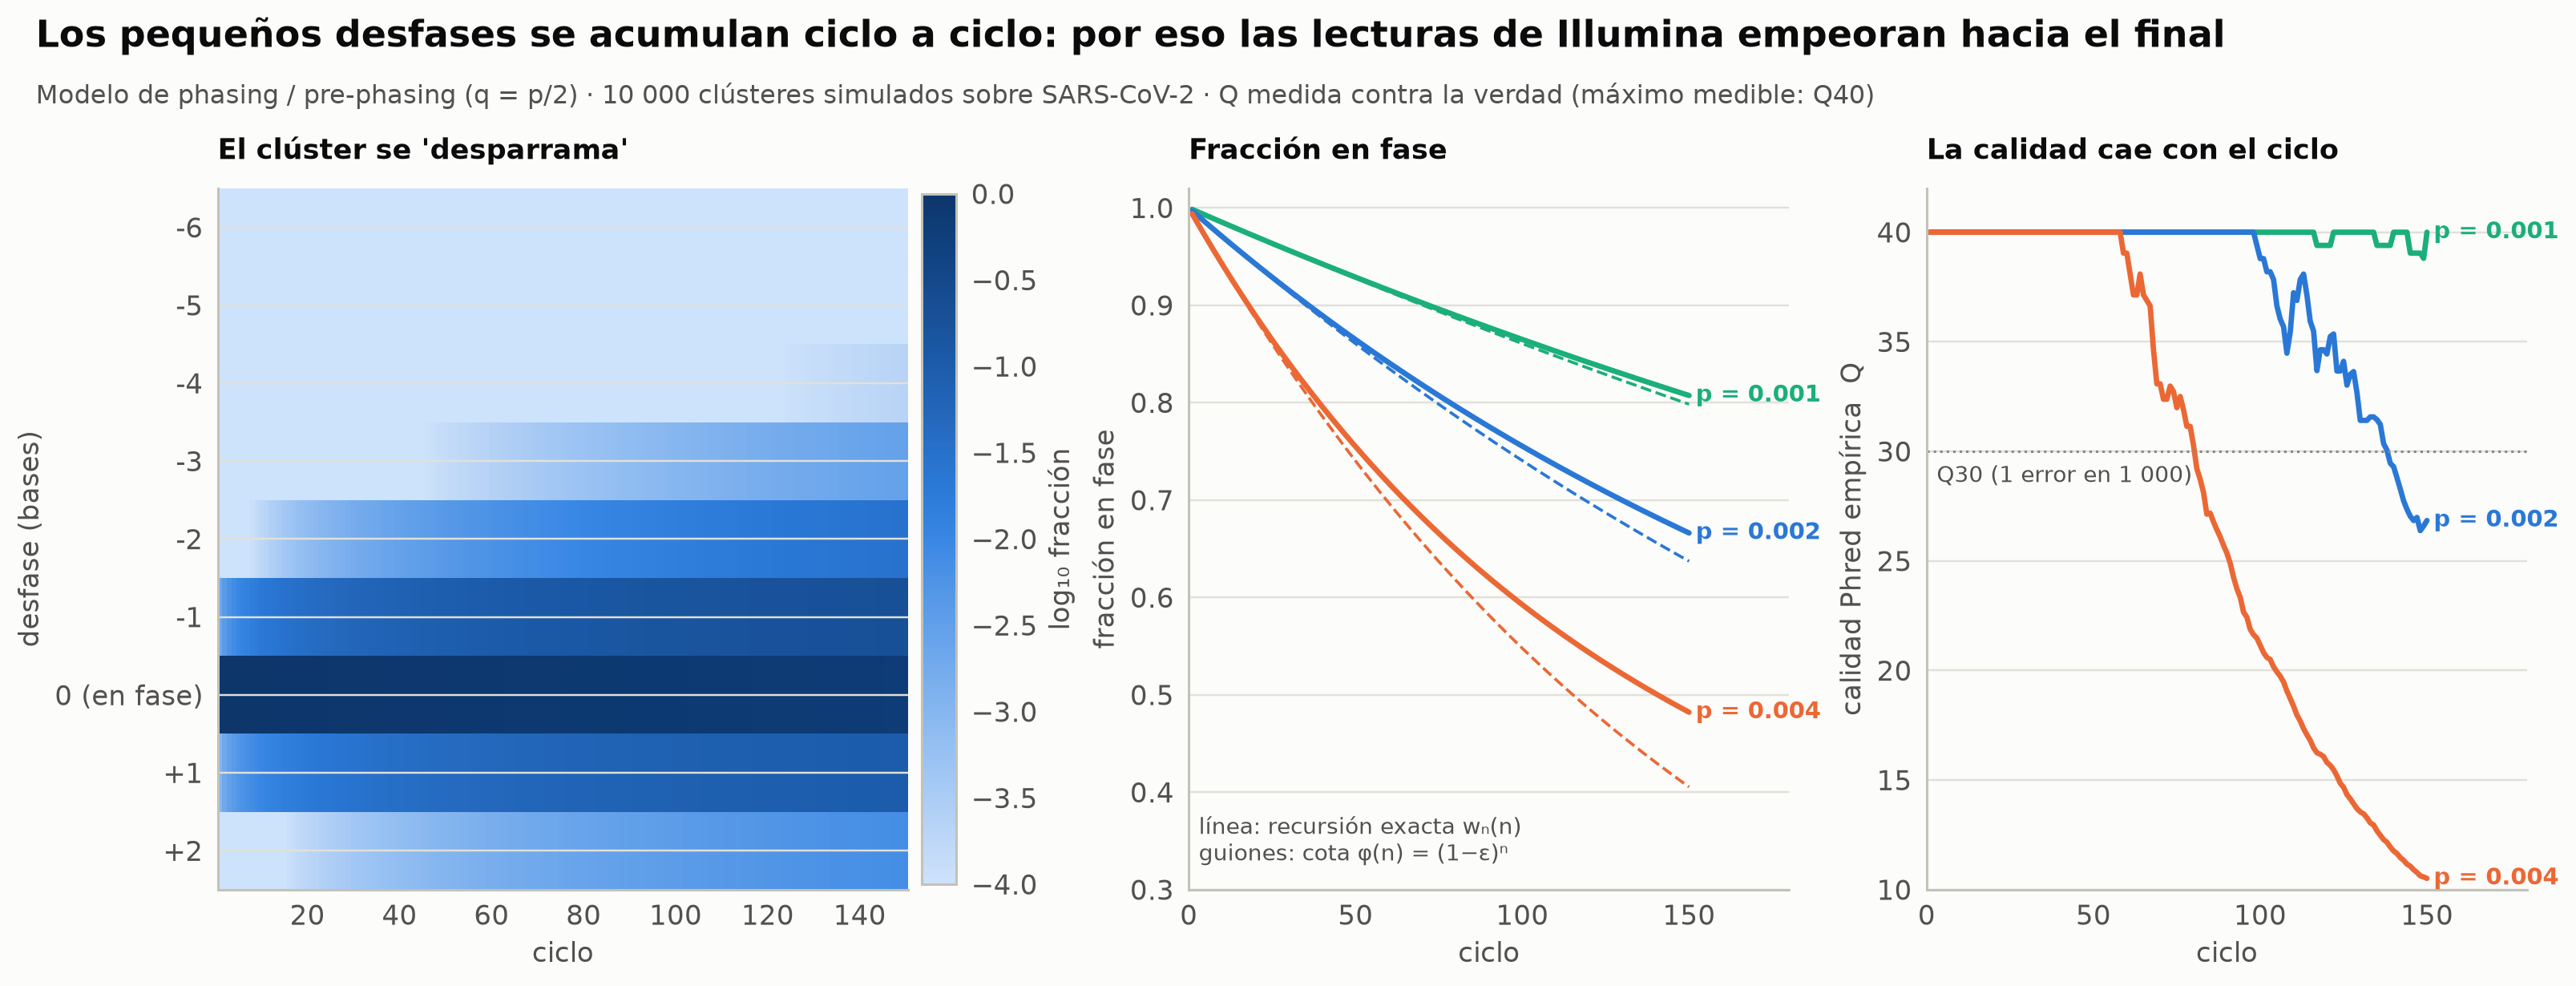

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.8), gridspec_kw=dict(width_ratios=[1.15, 1, 1]))
ax = axes[0]
Wt = phase_matrix(CYC, 0.002, 0.001)
rel = np.array([[Wt[n, n + 1 + d] if 0 <= n + 1 + d < Wt.shape[1] else 0 for d in range(-6, 3)] for n in range(CYC)])
im = ax.imshow(np.log10(np.maximum(rel.T, 1e-6)), aspect="auto", cmap=ec.CMAP_SEQ, vmin=-4, vmax=0,
               extent=[0.5, CYC + 0.5, 2.5, -6.5])
ax.set_yticks(range(-6, 3)); ax.set_yticklabels([f"{d:+d}" if d else "0 (en fase)" for d in range(-6, 3)])
ax.set_xlabel("ciclo"); ax.set_ylabel("desfase (bases)")
cb = plt.colorbar(im, ax=ax, fraction=0.05, pad=0.02); cb.set_label("log₁₀ fracción")
ax.set_title("El clúster se 'desparrama'", loc="left", fontsize=11.5)

ax = axes[1]
n = np.arange(1, CYC + 1)
for (name, (p, q)), col in zip(settings.items(), [ec.AQUA, ec.BLUE, ec.ORANGE]):
    Wx = phase_matrix(CYC, p, q)
    ax.plot(n, Wx[n - 1, n], color=col, lw=2.2)
    ax.plot(n, (1 - p - q) ** n, color=col, lw=1.2, ls="--")
    ax.text(CYC + 2, Wx[CYC - 1, CYC], f"p = {p}", color=col, fontsize=9.5, va="center", fontweight="bold")
ax.set_xlim(0, CYC + 30); ax.set_ylim(0.3, 1.02)
ax.set_xlabel("ciclo"); ax.set_ylabel("fracción en fase")
ax.set_title("Fracción en fase", loc="left", fontsize=11.5)
ax.text(3, 0.33, "línea: recursión exacta wₙ(n)\nguiones: cota φ(n) = (1−ε)ⁿ", fontsize=9, color=ec.INK_2)

ax = axes[2]
for (name, _), col in zip(settings.items(), [ec.AQUA, ec.BLUE, ec.ORANGE]):
    Qs = pd.Series(results[name]["Q"]).rolling(5, center=True, min_periods=1).mean()
    ax.plot(n, Qs, color=col, lw=2.2)
    ax.text(CYC + 2, Qs.iloc[-1], f"p = {settings[name][0]}", color=col, fontsize=9.5, va="center", fontweight="bold")
ax.axhline(30, color=ec.MUTED, lw=1, ls=":"); ax.text(3, 28.6, "Q30 (1 error en 1 000)", fontsize=9, color=ec.INK_2)
ax.set_xlim(0, CYC + 30); ax.set_ylim(10, 42)
ax.set_xlabel("ciclo"); ax.set_ylabel("calidad Phred empírica  Q")
ax.set_title("La calidad cae con el ciclo", loc="left", fontsize=11.5)
ec.fig_title(fig, "Los pequeños desfases se acumulan ciclo a ciclo: por eso las lecturas de Illumina empeoran hacia el final",
             "Modelo de phasing / pre-phasing (q = p/2) · 10 000 clústeres simulados sobre SARS-CoV-2 · Q medida contra la verdad (máximo medible: Q40)")
plt.show()

> 🔎 **Qué observamos.** A la izquierda, la fracción de hebras en fase (fila 0) se va vaciando hacia las filas de
> retraso (−1, −2, …) y, en menor medida, de adelanto (+1): el clúster se "desparrama". En el centro, la cota
> $\phi(n) = (1-\varepsilon)^n$ (guiones) queda apenas por debajo del cálculo exacto, como corresponde a una cota inferior. A la derecha, la calidad **no se impone**: sale de
> comparar los llamados con la verdad, y aun así reproduce la forma que usamos en la Lección 2.1 (alta y estable al
> principio, cayendo hacia el final). Duplicar el phasing no es un detalle: la curva naranja cruza Q30 decenas de ciclos
> antes. Por eso los equipos reales **estiman $p$ y $q$ en cada corrida** y corrigen la señal antes de llamar las bases
> (*phasing correction*); nuestra simulación no corrige nada y es, a propósito, pesimista.

### La nube de intensidades de 2 colores

En un equipo de 2 colores cada base es un punto en el plano (rojo, verde): A arriba a la derecha, C abajo a la derecha,
T arriba a la izquierda y G en el origen. Tomemos las mismas intensidades simuladas (p = 0.002) y convirtámoslas a 2
colores sumando canales.

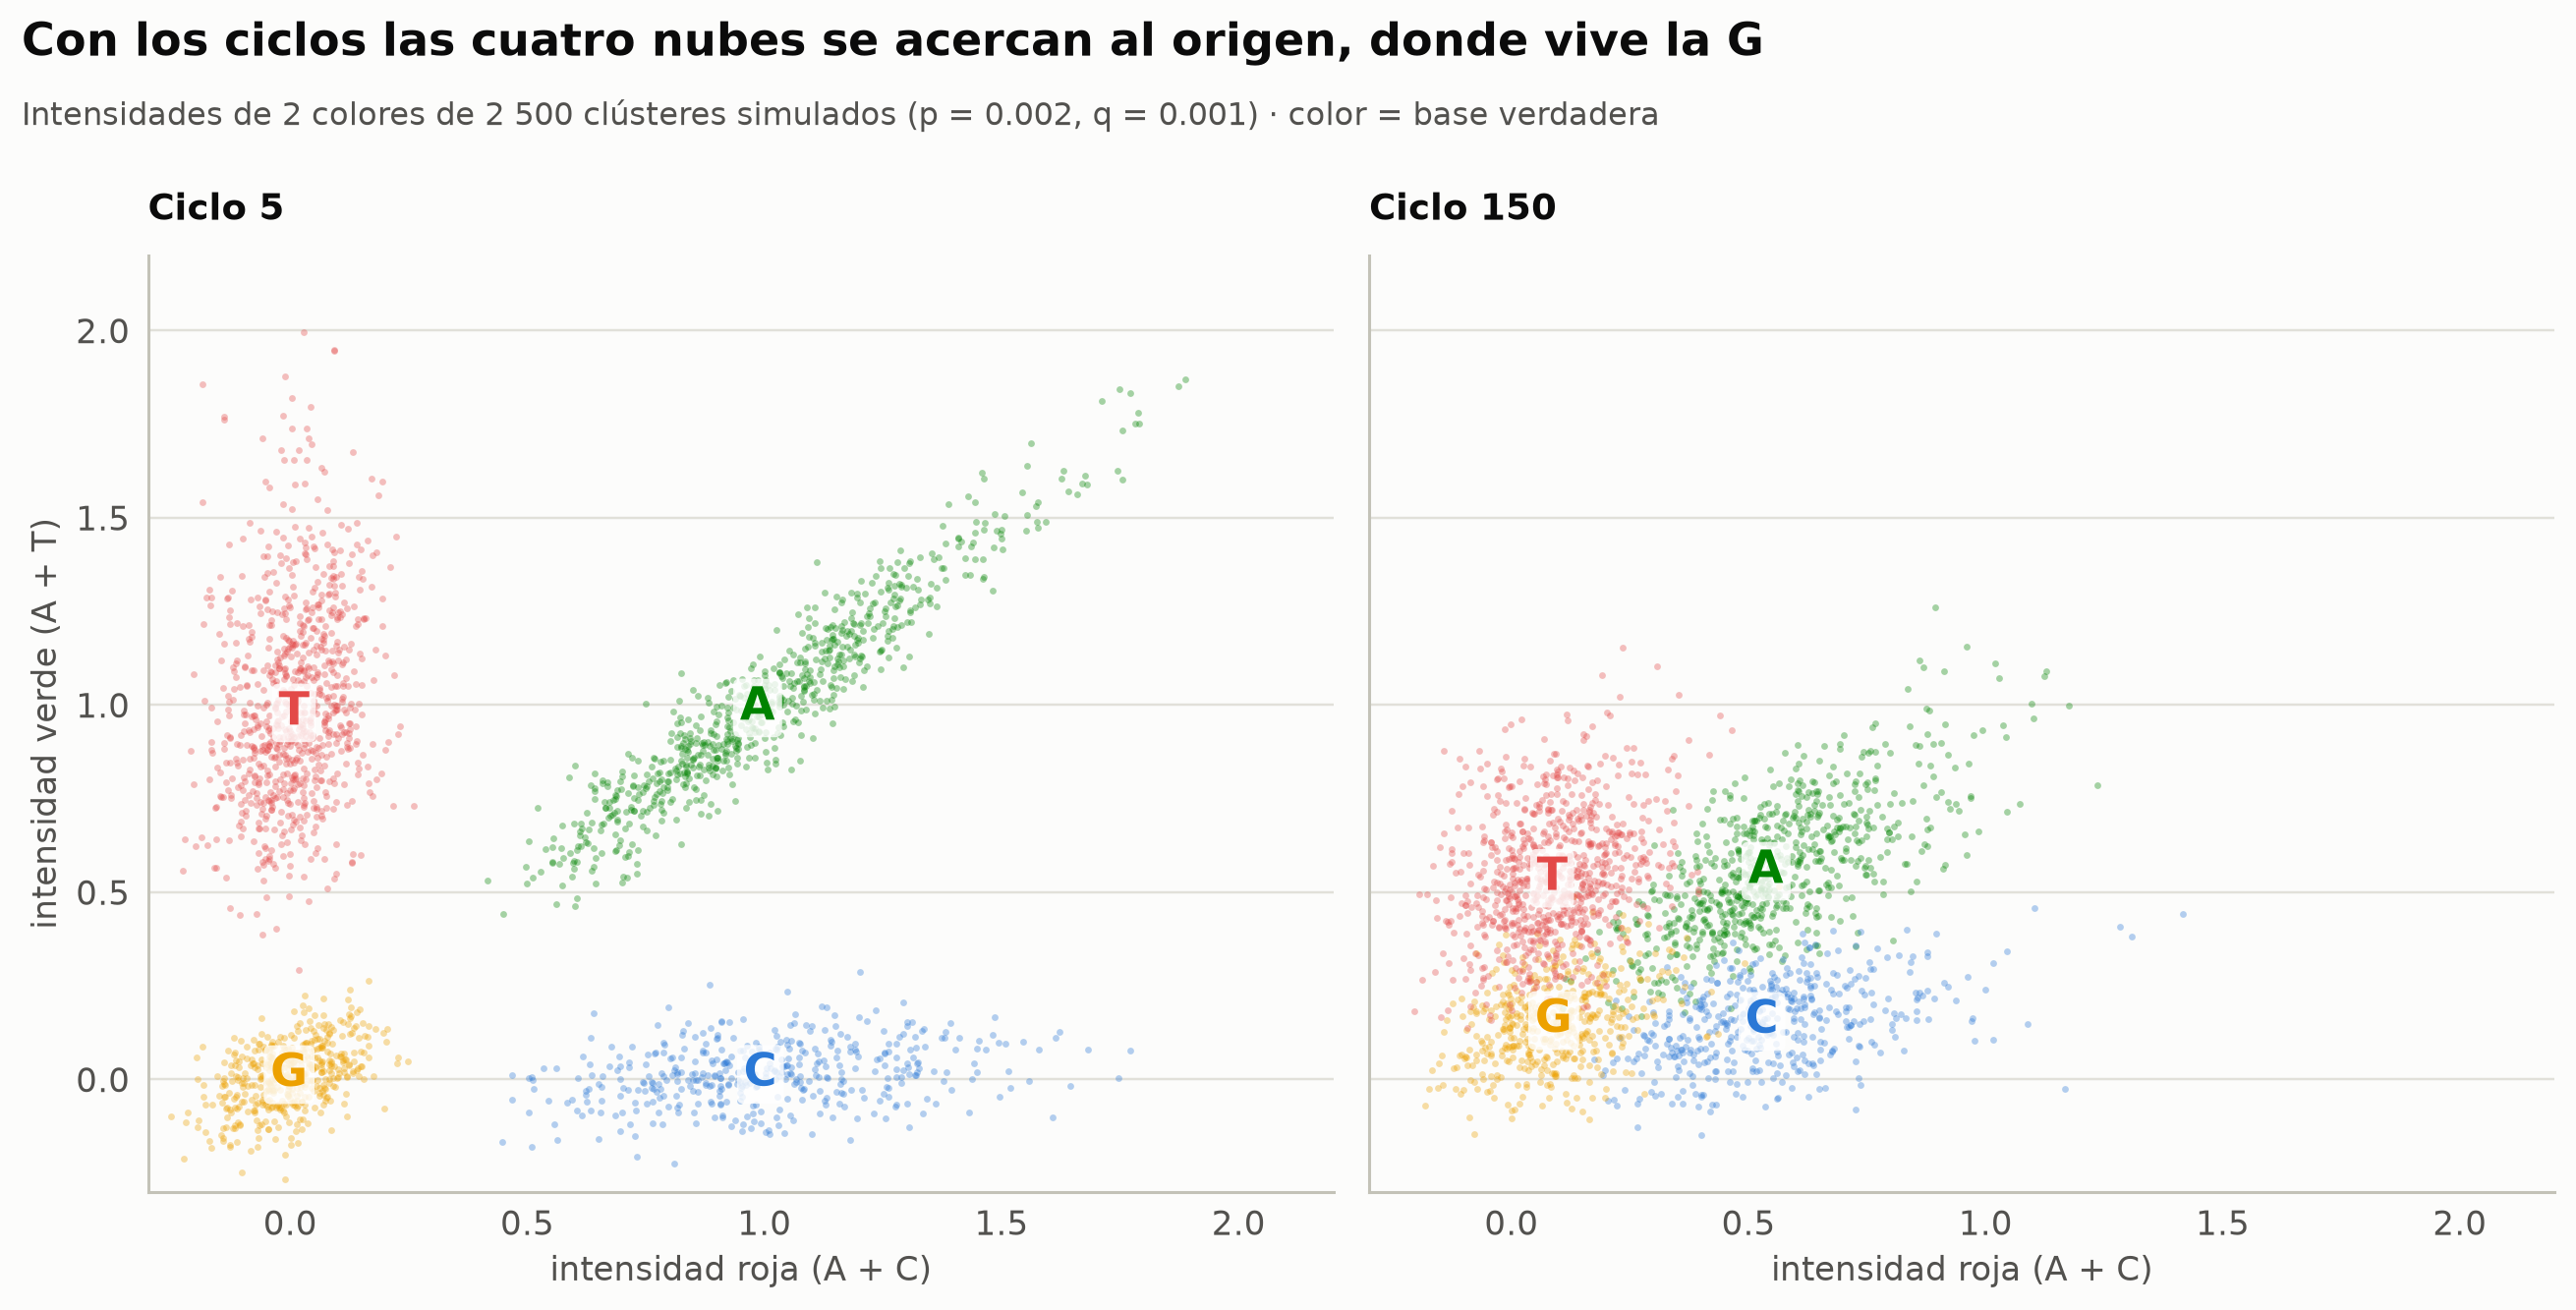

In [14]:
I_typ = results["p = 0.002, q = 0.001 (típico)"]["I"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5.4), sharex=True, sharey=True)
sub = rng.choice(N_SIM, 2500, replace=False)
for ax, cyc in zip(axes, (5, 150)):
    Ic = I_typ[sub, cyc - 1]
    r2, g2 = Ic[:, 0] + Ic[:, 1], Ic[:, 0] + Ic[:, 3]
    tb = truth_idx[sub, cyc - 1]
    for j, b in enumerate(BASES):
        m = tb == j
        ax.scatter(r2[m], g2[m], s=5, alpha=0.35, color=ec.NUC_COLORS[b], lw=0)
        ax.text(np.median(r2[m]), np.median(g2[m]), b, fontsize=15, fontweight="bold", color=ec.NUC_COLORS[b],
                ha="center", va="center", bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8))
    ax.set_title(f"Ciclo {cyc}", loc="left", fontsize=12)
    ax.set_xlabel("intensidad roja (A + C)")
axes[0].set_ylabel("intensidad verde (A + T)")
axes[0].set_xlim(-0.3, 2.2); axes[0].set_ylim(-0.3, 2.2)
ec.fig_title(fig, "Con los ciclos las cuatro nubes se acercan al origen, donde vive la G",
             "Intensidades de 2 colores de 2 500 clústeres simulados (p = 0.002, q = 0.001) · color = base verdadera")
plt.tight_layout(); plt.show()

> 🔎 **Qué observamos.** En el ciclo 5 las cuatro nubes están bien separadas. En el ciclo 150 la señal ha caído (factor
> $\lambda^{150}$) y el desfase la mezcla: las nubes se encogen hacia el origen y se tocan. Un clasificador que tenga que
> decidir "¿hay luz o no?" empezará a llamar **G** a clústeres que simplemente se apagaron: es el mismo mecanismo de la
> cola de poli-G, visto ahora en millones de clústeres.

✅ **Compruebe su comprensión.** Con $\varepsilon = p + q = 0.003$, ¿en qué ciclo cae $\phi(n)$ a la mitad? (Respuesta:
$n = \ln 0.5 / \ln 0.997 \approx 231$ ciclos; con el $\varepsilon = 0.002$ del libro, unos 346. Por eso las lecturas de Illumina rara vez pasan de
2 × 300.)

## 6. Lecturas pareadas y tamaño de inserto

Después de leer 150 ciclos desde el extremo P5 (lectura 1, **R1**), el equipo puede regenerar la hebra complementaria y
leer otros 150 ciclos desde el extremo P7 (lectura 2, **R2**). Así obtenemos **dos lecturas del mismo fragmento**, una
desde cada punta, apuntándose la una a la otra. A eso se le llama secuenciación **pareada** (*paired-end*, PE):

```
genoma      5' ─────────────────────────────────────────────────── 3'
fragmento           [==================== inserto ====================]
R1 (hebra +)        ────────────►
R2 (hebra −)                                              ◄────────────
                    |<──────────────── tamaño de inserto ─────────────>|
```

¿Por qué vale la pena? Porque aunque sólo leemos 2 × 150 bases, sabemos que están separadas por el **tamaño de inserto**
($\approx$ 300–500 pb) y en orientaciones opuestas. Eso ayuda a ubicar lecturas en regiones repetidas, a detectar
reordenamientos (un par cuyas lecturas caen demasiado lejos o en la orientación equivocada delata una deleción o una
inversión) y a ensamblar.

La lectura R2 está en la hebra **complementaria**: para ubicarla en el genoma hay que buscar su **complemento reverso**.
Si $s_1$ es la posición de inicio de R1 y $e_2$ la posición final (en la hebra +) de R2:

$$
\text{tamaño de inserto} \;=\; e_2 - s_1
\qquad\qquad
\text{solapamiento} \;=\; \max(0,\; 2L - \text{inserto})
$$

| Símbolo | Significado |
|---|---|
| $s_1$ | coordenada donde empieza R1 en el genoma |
| $e_2$ | coordenada donde termina el complemento reverso de R2 |
| $L$ | longitud de cada lectura (150) |

### Ejemplo a mano

R1 empieza en la posición 1 000 y el complemento reverso de R2 cubre 1 201–1 350. El inserto mide $1\,350 - 1\,000 = 350$
pb; como $2 \times 150 = 300 < 350$, las lecturas no se tocan y hay 50 pb **sin leer** en el centro. Si el inserto
midiera 250 pb, las lecturas se **solaparían** en $300 - 250 = 50$ pb (útil para corregir errores y fusionar el par). Si
midiera 120 pb, cada lectura se saldría del inserto y leería **30 bases de adaptador**.

In [15]:
READ_L = 150
def make_pairs(n, mean=350, sd=70, rng=rng):
    """Fragmentos aleatorios del genoma con tamaño normal; R1 = primeras L bases, R2 = complemento reverso de las
    últimas L bases (si el inserto es más corto que L, la lectura sigue en el adaptador)."""
    ADAPTER = "AGATCGGAAGAGC" * 20                      # comienzo del adaptador Illumina TruSeq, repetido de relleno
    ins = np.clip(rng.normal(mean, sd, n).round().astype(int), 80, 900)
    starts = rng.integers(0, len(GENOME) - ins)
    pairs = []
    for s, L in zip(starts, ins):
        frag = GENOME[s:s + L]
        r1 = (frag + ADAPTER)[:READ_L]
        r2 = (revcomp(frag) + ADAPTER)[:READ_L]
        pairs.append((r1, r2, s, L))
    return pairs

pairs = make_pairs(3000)
print("Par 0 · R1:", pairs[0][0][:60], "…")
print("       R2:", pairs[0][1][:60], "…")

# Ubicamos cada par en el genoma buscando R1 y el complemento reverso de R2 (sin errores, basta una búsqueda exacta)
est = []
for r1, r2, s, L in pairs:
    if L < READ_L:
        continue                                        # lecturas con adaptador: no se encuentran enteras
    s1 = GENOME.find(r1)
    s2 = GENOME.find(revcomp(r2))
    if s1 >= 0 and s2 >= 0:
        est.append((s1, s2 + READ_L - s1, L))
est = pd.DataFrame(est, columns=["inicio_R1", "inserto_estimado", "inserto_real"])
print(f"\nPares ubicados: {len(est)} de {len(pairs)} · estimación = realidad en "
      f"{(est.inserto_estimado == est.inserto_real).mean():.1%} de los casos")
print(f"Tamaño de inserto: media {est.inserto_estimado.mean():.0f} pb, desviación {est.inserto_estimado.std():.0f} pb")
print(f"Pares que se solapan (inserto < 300): {(est.inserto_estimado < 2 * READ_L).mean():.1%}")
print(f"Pares con adaptador (inserto < 150): {np.mean([L < READ_L for *_, L in pairs]):.1%}")

Par 0 · R1: CTAATGGTGACTTTTTGCATTTCTTACCTAGAGTTTTTAGTGCAGTTGGTAACATCTGTT …
       R2: AGAACCTTCAAGGTAGGTGTTAGGAAATTGAATAATAGAGCCATCCATGAGCACATAACG …

Pares ubicados: 2995 de 3000 · estimación = realidad en 100.0% de los casos
Tamaño de inserto: media 349 pb, desviación 69 pb
Pares que se solapan (inserto < 300): 24.7%
Pares con adaptador (inserto < 150): 0.2%


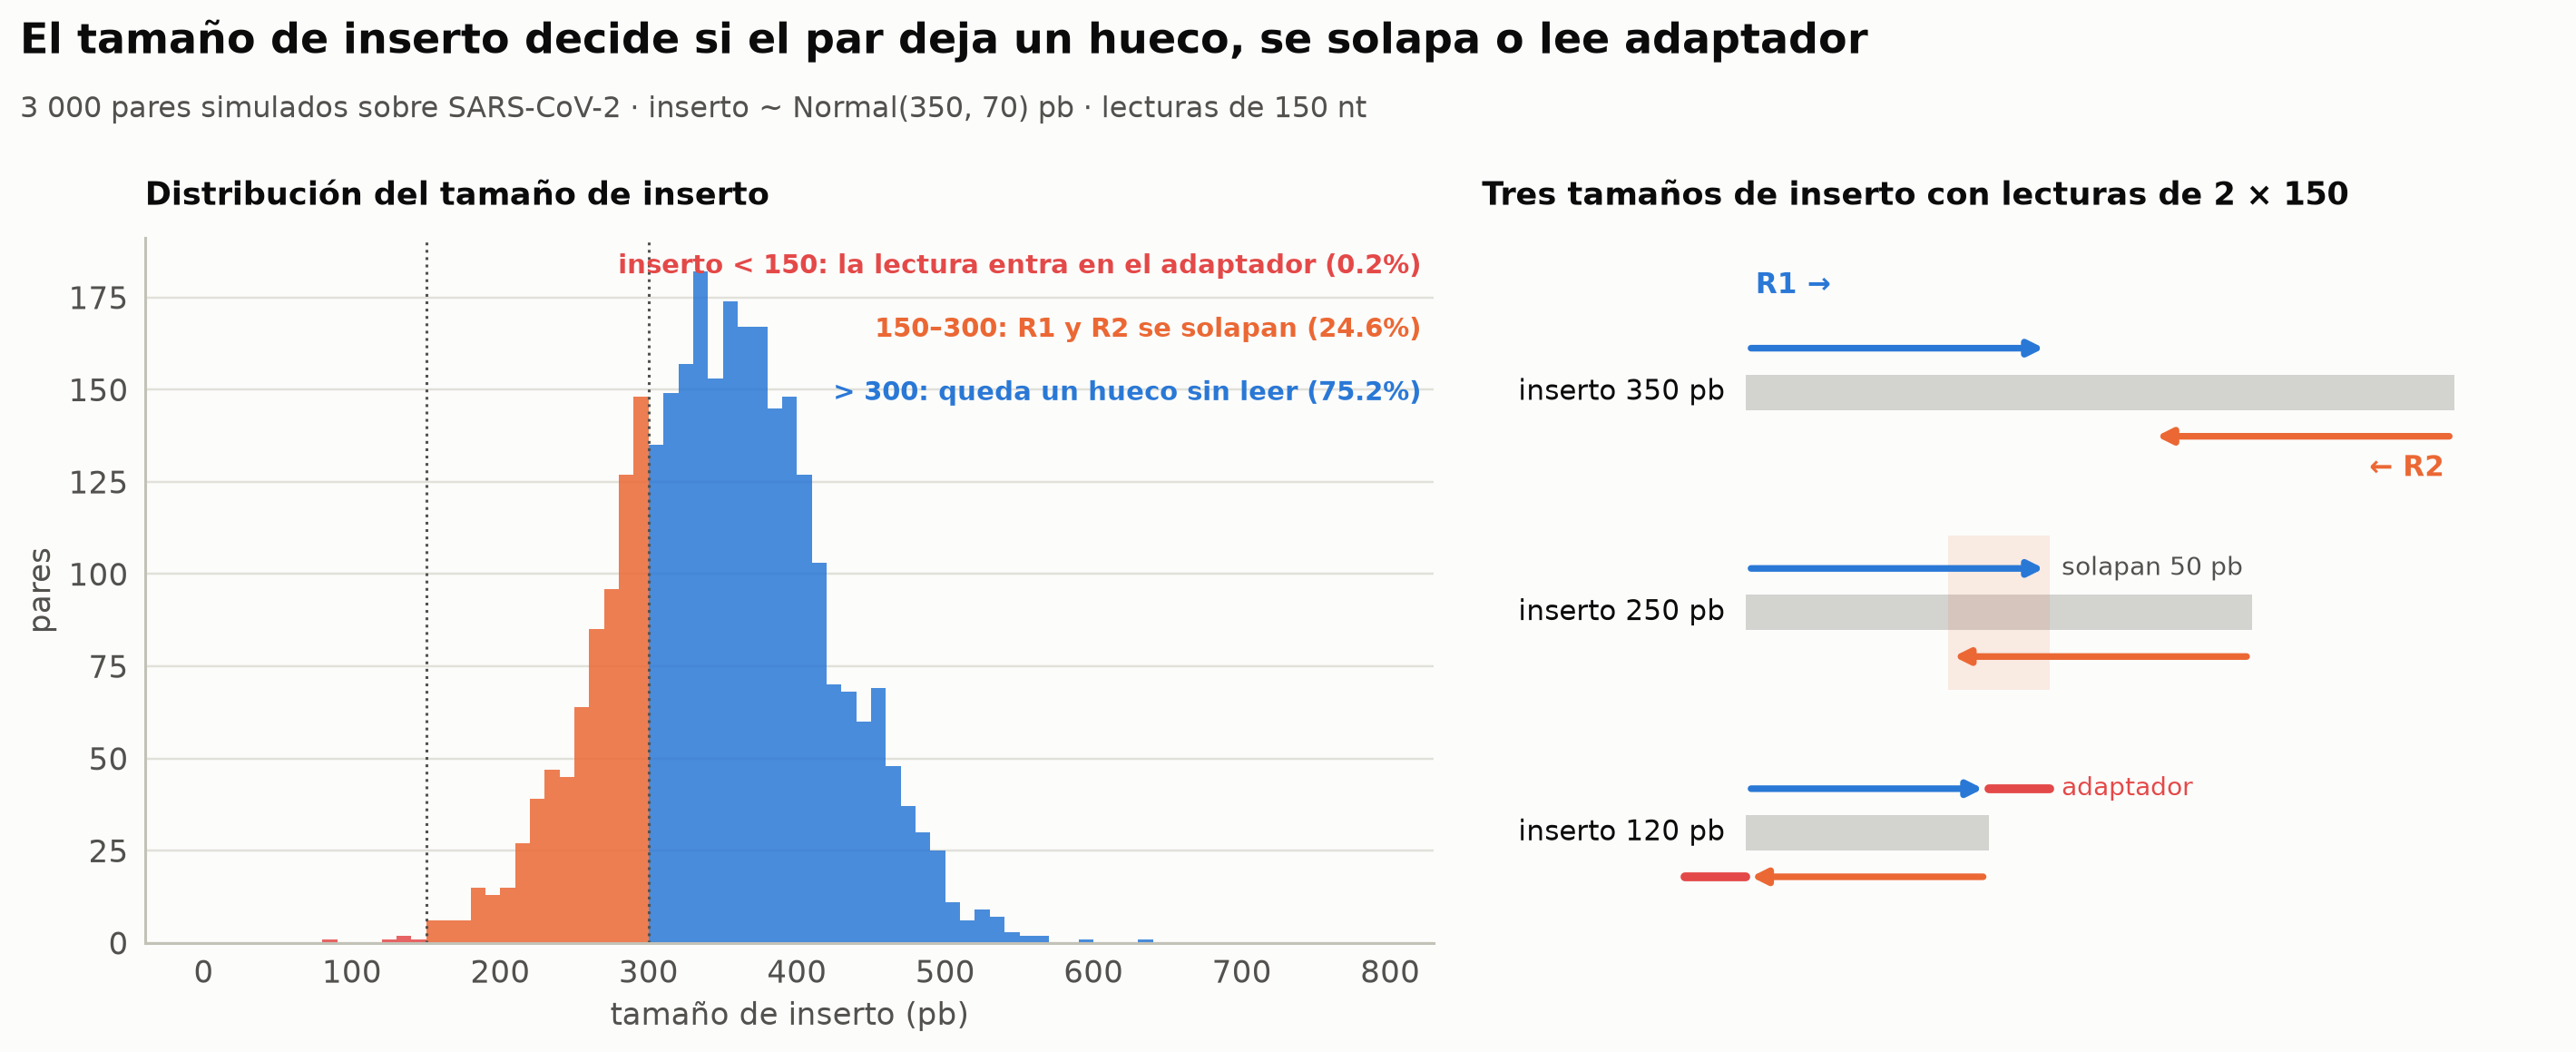

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw=dict(width_ratios=[1.2, 1]))
ax = axes[0]
bins = np.arange(0, 800, 10)
all_ins = np.array([L for *_, L in pairs])
for lo, hi, col, lab in [(0, READ_L, ec.RED, "inserto < 150: la lectura entra en el adaptador"),
                         (READ_L, 2 * READ_L, ec.ORANGE, "150–300: R1 y R2 se solapan"),
                         (2 * READ_L, 2000, ec.BLUE, "> 300: queda un hueco sin leer")]:
    m = (all_ins >= lo) & (all_ins < hi)
    ax.hist(all_ins[m], bins=bins, color=col, alpha=0.85)
    ax.text(0.99, 0.95 - 0.09 * [ec.RED, ec.ORANGE, ec.BLUE].index(col), f"{lab} ({m.mean():.1%})",
            transform=ax.transAxes, ha="right", fontsize=9.5, color=col, fontweight="bold")
ax.axvline(READ_L, color=ec.INK_2, lw=1, ls=":"); ax.axvline(2 * READ_L, color=ec.INK_2, lw=1, ls=":")
ax.set_xlabel("tamaño de inserto (pb)"); ax.set_ylabel("pares")
ax.set_title("Distribución del tamaño de inserto", loc="left", fontsize=11.5)

ax = axes[1]
examples = [(350, "inserto 350 pb"), (250, "inserto 250 pb"), (120, "inserto 120 pb")]
for row, (L, lab) in enumerate(examples):
    y = 2 - row
    ax.add_patch(Rectangle((0, y - 0.08), L, 0.16, fc=ec.MUTED, alpha=0.35, ec="none"))
    ax.text(-10, y, lab, ha="right", va="center", fontsize=10)
    r1_end = min(READ_L, L)
    ax.annotate("", (r1_end, y + 0.2), (0, y + 0.2), arrowprops=dict(arrowstyle="-|>", color=ec.BLUE, lw=2.4))
    ax.annotate("", (max(L - READ_L, 0), y - 0.2), (L, y - 0.2), arrowprops=dict(arrowstyle="-|>", color=ec.ORANGE, lw=2.4))
    if L < READ_L:
        ax.plot([L, READ_L], [y + 0.2, y + 0.2], color=ec.RED, lw=3.2)
        ax.plot([L - READ_L, 0], [y - 0.2, y - 0.2], color=ec.RED, lw=3.2)
        ax.text(READ_L + 6, y + 0.2, "adaptador", color=ec.RED, fontsize=9, va="center")
    elif L < 2 * READ_L:
        ax.axvspan(L - READ_L, READ_L, ymin=(y - 0.35 + 0.5) / 3.2, ymax=(y + 0.35 + 0.5) / 3.2, color=ec.ORANGE, alpha=0.12)
        ax.text(READ_L + 6, y + 0.2, f"solapan {2 * READ_L - L} pb", color=ec.INK_2, fontsize=9, va="center")
ax.text(5, 2.45, "R1 →", color=ec.BLUE, fontsize=10, fontweight="bold")
ax.text(345, 1.62, "← R2", color=ec.ORANGE, fontsize=10, fontweight="bold", ha="right")
ax.set_xlim(-130, 400); ax.set_ylim(-0.5, 2.7); ax.axis("off")
ax.set_title("Tres tamaños de inserto con lecturas de 2 × 150", loc="left", fontsize=11.5)
ec.fig_title(fig, "El tamaño de inserto decide si el par deja un hueco, se solapa o lee adaptador",
             "3 000 pares simulados sobre SARS-CoV-2 · inserto ~ Normal(350, 70) pb · lecturas de 150 nt")
plt.tight_layout(); plt.show()

> 🔎 **Qué observamos.** Con un inserto medio de 350 pb, tres de cada cuatro pares dejan un pequeño hueco sin leer, una
> cuarta parte se solapa y sólo unos pocos (≈ 0.2 %) tienen un inserto más corto que la lectura y terminan leyendo
> adaptador. Con librerías de inserto más corto (por ejemplo, ADN degradado o amplicones) esa fracción crece mucho. Como no
> pusimos errores, la búsqueda exacta recupera el tamaño de inserto real en el 100 % de los pares con inserto ≥ 150; con
> datos reales esa tarea la hace un **alineador** (próximas lecciones del módulo), que además usa la distribución de tamaños para decidir
> si un par es "normal".

✅ **Compruebe su comprensión.** Un par cuyas dos lecturas apuntan **hacia afuera** (R1 en la hebra −, R2 en la +) y
están a 5 000 pb una de otra, ¿es un error? (Respuesta: no necesariamente. En el ADN del paciente puede haber un
reordenamiento, por ejemplo una duplicación en tándem, que en la referencia se ve así. Los detectores de variantes
estructurales buscan justamente estos **pares discordantes**.)

## 7. Oxford Nanopore: la señal de corriente y un *basecaller* ingenuo

Las tecnologías de "tercera generación" leen **una sola molécula**, sin amplificarla y sin ciclos. La de Oxford Nanopore
(ONT) es casi mecánica: una membrana aislante separa dos cámaras con una solución salina, y en la membrana hay un
**poro proteico** de ~1 nm de diámetro. Se aplica un voltaje y los iones atraviesan el poro: se mide una **corriente
iónica** de decenas de picoamperios (pA). Una **proteína motora** desenrolla el ADN y lo hace pasar por el poro, base a
base, a unas 400 bases por segundo. Mientras las bases ocupan la parte más estrecha del poro, **tapan parcialmente** el
paso de los iones, y cada combinación de bases lo tapa de forma distinta. Es como adivinar qué objetos pasan por un
tubo escuchando cómo cambia el sonido del aire.

El detalle crucial es que la corriente no depende de **una** base sino de las $k$ bases que están dentro del poro en ese
momento (un **k-mero**, con $k \approx 5$–$9$ según la química). La señal registrada a 4–5 kHz, llamada **squiggle**
("garabato"), es una sucesión de escalones: cada escalón corresponde a un k-mero y dura un tiempo **aleatorio**, porque
el motor avanza a saltos irregulares.

### El modelo de niveles

$$
x_t \;=\; \mu\big(\text{k-mero}_i\big) + \varepsilon_t,
\qquad \varepsilon_t \sim \mathcal N(0, \sigma^2),
\qquad D_i \sim \text{Gamma}\;(\text{media} \approx 9 \text{ muestras})
$$

| Símbolo | Significado |
|---|---|
| $x_t$ | corriente medida en la muestra $t$ (pA) |
| $\mu(\cdot)$ | **nivel** esperado de cada k-mero: una tabla de $4^k$ valores ($4^5 = 1\,024$) |
| $\sigma$ | ruido eléctrico |
| $D_i$ | número de muestras que el k-mero $i$ permanece en el poro (*dwell time*) |

ONT publica tablas de niveles medidas para cada química (las de R9.4 usaban 6-meros). Nosotros usaremos una tabla
**sintética**, generada con una regla sencilla (cada posición del k-mero aporta según su base, más una perturbación
aleatoria), que imita su comportamiento pero **no** son los valores reales.

### Ejemplo a mano

Con $k = 3$ y una tabla de juguete $\mu(\texttt{GAT}) = 80$, $\mu(\texttt{ATT}) = 95$, $\mu(\texttt{TTA}) = 72$ pA, la
secuencia `GATTA` (tres 3-meros) con tiempos de permanencia 3, 2 y 4 muestras y sin ruido produce:

`80 80 80 | 95 95 | 72 72 72 72`

Para leer la secuencia hay que hacer el camino inverso: **segmentar** la señal en escalones, **estimar** el nivel de
cada uno y buscar la sucesión de k-meros **compatibles** que mejor la explique. Dos k-meros consecutivos se solapan en
$k-1$ bases (`GAT` → `ATT`: comparten `AT`), así que cada paso sólo puede ir a 4 k-meros posibles.

In [17]:
K = 5
KIDX = np.arange(4 ** K)
DIGITS = np.array([(KIDX // 4 ** (K - 1 - i)) % 4 for i in range(K)]).T          # (1024, K): bases de cada k-mero
KMERS = np.array(["".join(BASES[d] for d in row) for row in DIGITS])
rng_pore = np.random.default_rng(2016)
contrib = np.array([[-9, 6, 2, -4], [-14, 10, 4, -6], [-18, 13, 6, -9], [-10, 8, 3, -5], [-5, 3, 1, -2]], float)
raw_lv = contrib[np.arange(K), DIGITS].sum(1) + rng_pore.normal(0, 1.1, 4 ** K)   # la base central pesa más
LEVELS = 60 + 70 * (raw_lv - raw_lv.min()) / (raw_lv.max() - raw_lv.min())      # tabla SINTÉTICA, 60–130 pA
NOISE_PA = 0.5

def kmer_ids(seq):
    """Índice (0–1023) de cada k-mero de la secuencia."""
    a = np.array([BASES.index(c) for c in seq]); ids = np.zeros(len(seq) - K + 1, dtype=int)
    for i in range(K):
        ids = ids * 4 + a[i:len(a) - K + 1 + i]
    return ids

def squiggle(seq, rng, mean_dwell=9.0, noise=NOISE_PA):
    """Señal simulada: un escalón por k-mero, de duración Gamma(2, media 9 muestras), más ruido gaussiano."""
    ids = kmer_ids(seq)
    dwell = np.maximum(1, rng.gamma(2.0, mean_dwell / 2.0, len(ids)).round().astype(int))
    expected = np.repeat(LEVELS[ids], dwell)
    return expected + rng.normal(0, noise, len(expected)), ids, dwell

print("Tabla sintética de niveles (primeros y últimos k-meros):")
print(pd.Series(LEVELS, index=KMERS).round(1).iloc[[0, 1, 2, 3, 1021, 1022, 1023]].to_string())

Tabla sintética de niveles (primeros y últimos k-meros):
AAAAA    60.0
AAAAC    67.5
AAAAG    65.5
AAAAT    63.8
TTTTC    86.1
TTTTG    85.1
TTTTT    81.3


Región 11045–11112: TTAGTCCAGAGTACTCAATGGTCTTTGTTCTTTTTTTTGTATGAAAATGCCTTTTTACCTTTTGCTAT
64 k-meros → 503 muestras (≈ 126 ms a 4 kHz)


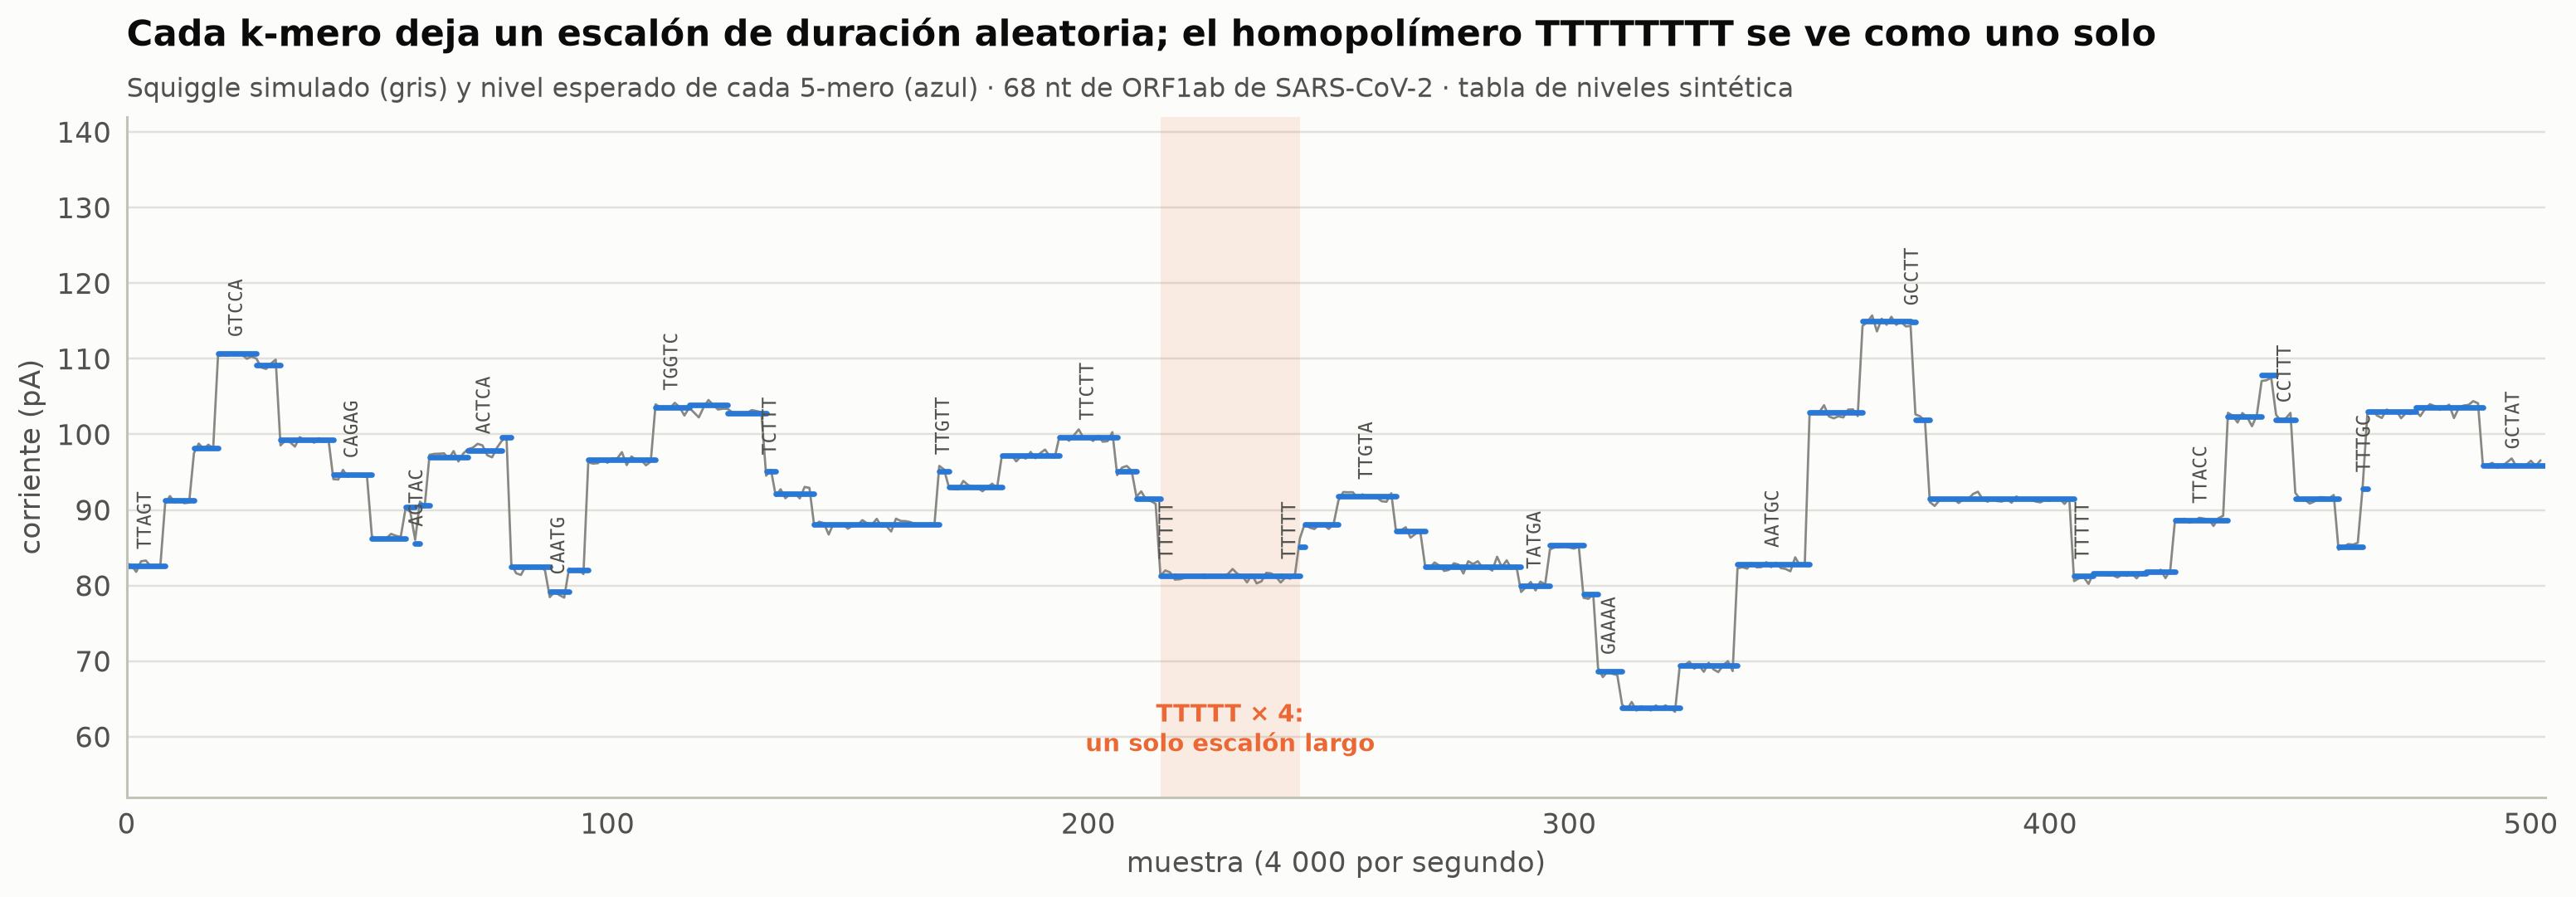

In [18]:
HP_START = GENOME.find("TTTTTTTT")                           # un homopolímero de 8 T en el genoma (ORF1ab)
region = GENOME[HP_START - 30:HP_START + 38]
sig_r, ids_r, dw_r = squiggle(region, np.random.default_rng(7))
edges = np.r_[0, np.cumsum(dw_r)]
print(f"Región {HP_START - 29}–{HP_START + 38}: {region}")
print(f"{len(ids_r)} k-meros → {len(sig_r)} muestras (≈ {len(sig_r) / 4000 * 1000:.0f} ms a 4 kHz)")

fig, ax = plt.subplots(figsize=(14, 4.8))
ax.plot(np.arange(len(sig_r)), sig_r, color=ec.MUTED, lw=0.9)
for i, k in enumerate(ids_r):
    ax.plot([edges[i], edges[i + 1]], [LEVELS[k]] * 2, color=ec.BLUE, lw=2.2)
    if i % 3 == 0:
        ax.text((edges[i] + edges[i + 1]) / 2, LEVELS[k] + 2.2, KMERS[k], rotation=90, fontsize=7.5, ha="center",
                va="bottom", family="monospace", color=ec.INK_2)
hp0 = 30                                                     # el homopolímero empieza en la posición 30 de la región
flat = list(range(hp0, hp0 + 8 - K + 1))                     # los 5-meros TTTTT que caen dentro de las 8 T
assert all(KMERS[ids_r[i]] == "TTTTT" for i in flat)
ax.axvspan(edges[flat[0]], edges[flat[-1] + 1], color=ec.ORANGE, alpha=0.12, lw=0)
ax.text((edges[flat[0]] + edges[flat[-1] + 1]) / 2, 57, f"TTTTT × {len(flat)}:\nun solo escalón largo", ha="center",
        fontsize=9.5, color=ec.ORANGE, fontweight="bold", va="bottom")
ax.set_xlim(0, len(sig_r)); ax.set_ylim(52, 142)
ax.set_xlabel("muestra (4 000 por segundo)"); ax.set_ylabel("corriente (pA)")
ec.title(ax, "Cada k-mero deja un escalón de duración aleatoria; el homopolímero TTTTTTTT se ve como uno solo",
         "Squiggle simulado (gris) y nivel esperado de cada 5-mero (azul) · 68 nt de ORF1ab de SARS-CoV-2 · tabla de niveles sintética")
plt.show()

> 🔎 **Qué observamos.** Algunos pasos de un k-mero al siguiente son saltos grandes y fáciles de ver; otros son de apenas
> 1 pA y se confunden con el ruido. En el homopolímero de 8 T, los cuatro 5-meros consecutivos son **idénticos**
> (`TTTTT`), así que la corriente no cambia: la única pista de cuántas T hay es la **duración** del escalón, que es
> aleatoria. Ese es el origen de los errores característicos de Nanopore: **deleciones (e inserciones) en
> homopolímeros**. Las químicas recientes (R10) tienen un poro con dos "cabezas lectoras" separadas para mitigarlo.

### Explorador interactivo del squiggle

Pase el cursor por la señal: verá el número de muestra, el tiempo, la corriente medida, el k-mero que ocupaba el poro,
su nivel esperado y cuánto tiempo permaneció. Use el zoom para acercarse a los escalones pequeños.

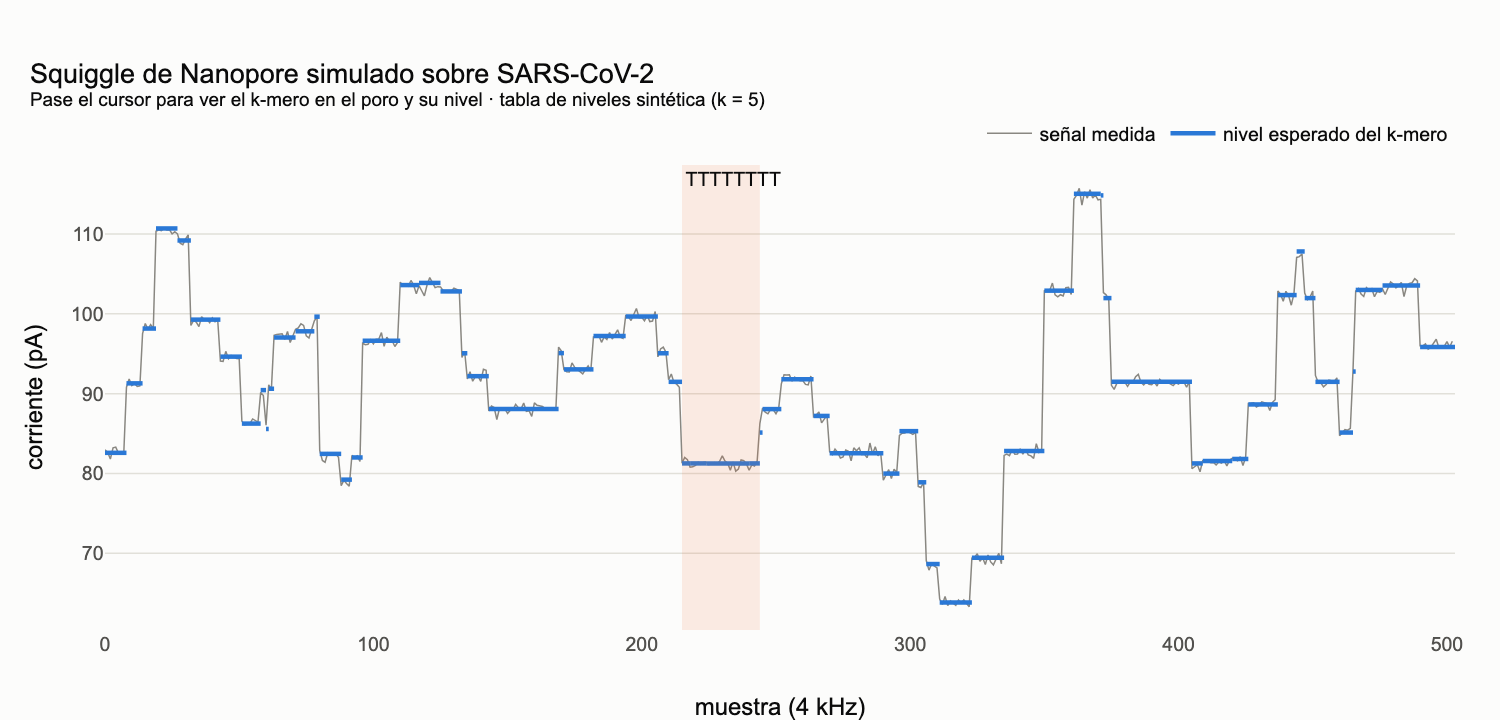

In [19]:
kmer_of_sample = np.repeat(np.arange(len(ids_r)), dw_r)
fig = go.Figure()
fig.add_scatter(x=np.arange(len(sig_r)), y=sig_r, mode="lines", name="señal medida", line=dict(color=ec.MUTED, width=1),
                customdata=np.c_[np.arange(len(sig_r)) / 4.0, [KMERS[ids_r[i]] for i in kmer_of_sample],
                                 LEVELS[ids_r[kmer_of_sample]], dw_r[kmer_of_sample], kmer_of_sample + 1],
                hovertemplate=("muestra %{x} · t = %{customdata[0]:.2f} ms<br>corriente: <b>%{y:.1f} pA</b>"
                               "<br>k-mero en el poro: <b>%{customdata[1]}</b> (n.º %{customdata[4]})"
                               "<br>nivel esperado: %{customdata[2]:.1f} pA<br>permanencia: %{customdata[3]} muestras"
                               "<extra></extra>"))
step_x, step_y = [], []
for i, k in enumerate(ids_r):
    step_x += [edges[i], edges[i + 1], None]; step_y += [LEVELS[k], LEVELS[k], None]
fig.add_scatter(x=step_x, y=step_y, mode="lines", name="nivel esperado del k-mero", line=dict(color=ec.BLUE, width=3),
                hoverinfo="skip")
fig.add_vrect(x0=edges[flat[0]], x1=edges[flat[-1] + 1], fillcolor=ec.ORANGE, opacity=0.12, line_width=0,
              annotation_text="TTTTTTTT", annotation_position="top left")
fig.update_layout(
    title=dict(text="Squiggle de Nanopore simulado sobre SARS-CoV-2<br>"
                    "<sup>Pase el cursor para ver el k-mero en el poro y su nivel · tabla de niveles sintética (k = 5)</sup>"),
    xaxis=dict(title="muestra (4 kHz)"), yaxis=dict(title="corriente (pA)"), height=480,
    margin=dict(t=110, l=70, r=30, b=60), legend=dict(orientation="h", yanchor="bottom", y=1.02, x=1, xanchor="right"))
fig.show()

## 🎬 Animación: la hebra atraviesa el poro

Arriba, la hebra de ADN avanza de derecha a izquierda; el recuadro marca las 5 bases que ocupan el poro. Abajo, la
corriente se va registrando en tiempo real.

![La hebra atraviesa el nanoporo: cada 5-mero dentro del poro produce un nivel de corriente distinto y el homopolímero deja un escalón largo y plano](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-06-ngs/6.1_nanoporo_squiggle.gif)

*La hebra atraviesa el nanoporo: cada 5-mero dentro del poro produce un nivel de corriente distinto y el homopolímero deja un escalón largo y plano*

In [20]:
n_frames = 56
kmer_steps = np.linspace(0, len(ids_r) - 1, n_frames).round().astype(int)
fig, (axs, axc) = plt.subplots(2, 1, figsize=(12, 5.6), gridspec_kw=dict(height_ratios=[1, 1.5]))

def update(f):
    i = kmer_steps[f]
    axs.clear(); axc.clear()
    center = 20
    for j, b in enumerate(region):
        x = center + (j - i) * 1.0
        if -1 < x < 42:
            inside = i <= j < i + K
            axs.text(x, 0.5, b, ha="center", va="center", family="monospace", fontsize=13,
                     fontweight="bold" if inside else "normal", color=ec.NUC_COLORS[b], alpha=1 if inside else 0.55)
    axs.add_patch(Rectangle((center - 0.6, 0.05), K + 0.2, 0.9, fc="none", ec=ec.INK, lw=2))
    axs.add_patch(Rectangle((-1, -0.35), center - 0.6 + 1, 0.25, fc=ec.BASELINE, ec="none"))
    axs.add_patch(Rectangle((center + K - 0.4, -0.35), 44 - center - K, 0.25, fc=ec.BASELINE, ec="none"))
    axs.text(center + K / 2 - 0.5, 1.15, f"poro: {KMERS[ids_r[i]]}", ha="center", fontsize=11, color=ec.INK,
             fontweight="bold")
    axs.text(-0.8, -0.23, "membrana", fontsize=8.5, color=ec.INK_2, va="center")
    axs.set_xlim(-1, 42); axs.set_ylim(-0.5, 1.5); axs.axis("off")
    end = edges[i + 1]
    axc.plot(np.arange(end), sig_r[:end], color=ec.MUTED, lw=0.9)
    axc.plot([edges[i], edges[i + 1]], [LEVELS[ids_r[i]]] * 2, color=ec.ORANGE, lw=3)
    axc.set_xlim(0, len(sig_r)); axc.set_ylim(52, 142)
    axc.set_xlabel("muestra"); axc.set_ylabel("corriente (pA)")
    axc.text(0.01, 0.92, f"k-mero {i + 1} de {len(ids_r)} · nivel esperado {LEVELS[ids_r[i]]:.1f} pA",
             transform=axc.transAxes, fontsize=10, color=ec.INK_2)
    fig.suptitle("Nanopore: la corriente depende de las 5 bases que ocupan el poro", x=0.01, ha="left",
                 fontsize=12.5, fontweight="bold")
    return []

ec.animate(fig, update, frames=n_frames, interval=220, name="6.1_nanoporo_squiggle")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

### Un *basecaller* ingenuo: segmentar + Viterbi

Leer la secuencia desde el squiggle es un problema de **estados ocultos**: los estados son los 1 024 k-meros, lo que
observamos son niveles de corriente, y entre un k-mero y el siguiente sólo hay 4 transiciones posibles. Es exactamente el
marco de los **modelos ocultos de Márkov** de la Lección 4.3, y el algoritmo de **Viterbi** encuentra el camino de k-meros
más probable. Así funcionaban los primeros *basecallers* de Nanopore (hacia 2014–2016); los actuales (Guppy, Dorado) usan
redes neuronales entrenadas directamente sobre la señal.

Nuestro algoritmo, en dos pasos:

1. **Segmentar.** Recorremos la señal comparando la media de las 3 muestras anteriores con la de las 3 siguientes; donde la
   diferencia es grande (un pico), ponemos una frontera de escalón. Cada segmento se resume con su **media**.
2. **Viterbi sobre k-meros.** Cada segmento "emite" su media con probabilidad gaussiana alrededor del nivel del k-mero.
   Entre segmentos permitimos tres movimientos, porque la segmentación no es perfecta:

| Movimiento | Qué significa | Bases que añade | Probabilidad |
|---|---|---|---|
| **avanzar** | el segmento es el k-mero siguiente (4 opciones) | 1 | $1 - p_{\text{quieto}} - p_{\text{salto}}$ |
| **quedarse** | la segmentación partió un escalón en dos | 0 | $p_{\text{quieto}} = 0.2$ |
| **saltar** | dos escalones parecidos se fusionaron en uno (16 opciones) | 2 | $p_{\text{salto}} = 0.2$ |

$$
V_j(s) \;=\; \log \mathcal N\big(m_j \mid \mu(s), \tau^2\big) \;+\; \max_{s'} \Big[\,V_{j-1}(s') + \log P(s' \to s)\Big]
$$

donde $m_j$ es la media del segmento $j$ y $\tau$ la desviación que toleramos. El truco que lo hace rápido: los
predecesores de un k-mero $s$ por "avanzar" son los 4 k-meros que terminan con los $k-1$ primeros caracteres de $s$,
y con NumPy se obtienen con un simple `reshape(4, 256).max(0)`.

In [21]:
def segment_signal(sig, w=3, thr=1.0):
    """Fronteras de escalones: picos de |media(derecha) − media(izquierda)| en ventanas de w muestras."""
    c = np.r_[0, np.cumsum(sig)]; n = len(sig); t = np.arange(w, n - w + 1)
    diff = np.abs((c[t + w] - c[t]) / w - (c[t] - c[t - w]) / w)
    pk, _ = find_peaks(diff, height=thr, distance=3)
    return np.r_[0, t[pk], n]

def viterbi_basecall(means, tau=0.8, p_stay=0.2, p_skip=0.2):
    """Viterbi sobre los 4^K k-meros con movimientos quedarse / avanzar (4) / saltar (16)."""
    p_step = 1 - p_stay - p_skip
    tt = KIDX
    V = -0.5 * ((means[0] - LEVELS) / tau) ** 2
    back = []
    for m in means[1:]:
        stay = V + np.log(p_stay)
        r1 = V.reshape(4, -1); step = r1.max(0)[tt // 4] + np.log(p_step / 4)
        prev1 = r1.argmax(0)[tt // 4] * 4 ** (K - 1) + tt // 4
        r2 = V.reshape(16, -1); skip = r2.max(0)[tt // 16] + np.log(p_skip / 16)
        prev2 = r2.argmax(0)[tt // 16] * 4 ** (K - 2) + tt // 16
        cand = np.vstack([stay, step, skip]); kind = cand.argmax(0)
        back.append((np.choose(kind, [tt, prev1, prev2]), kind))
        V = cand.max(0) - 0.5 * ((m - LEVELS) / tau) ** 2
    s = int(V.argmax()); path, kinds = [s], []
    for prev, kind in reversed(back):
        kinds.append(kind[s]); s = int(prev[s]); path.append(s)
    path, kinds = path[::-1], kinds[::-1]
    seq = KMERS[path[0]]
    for st, kd in zip(path[1:], kinds):
        seq += {0: "", 1: KMERS[st][-1], 2: KMERS[st][-2:]}[kd]
    return seq

t0 = time.time()
ont_true = GENOME[5000:8000]
sig_l, ids_l, dw_l = squiggle(ont_true, np.random.default_rng(3))
bounds = segment_signal(sig_l)
seg_means = np.array([sig_l[a:b].mean() for a, b in zip(bounds[:-1], bounds[1:])])
ont_call = viterbi_basecall(seg_means)
ops = align_ops(ont_true, ont_call)
print(f"{len(ids_l)} k-meros reales → {len(seg_means)} segmentos detectados → {len(ont_call)} bases llamadas "
      f"({time.time() - t0:.1f} s)")
print(f"Identidad: {1 - ops['distancia'] / len(ont_true):.1%}  ·  sustituciones {ops['sustitución']}, "
      f"inserciones {ops['inserción']}, deleciones {ops['deleción']}")

2996 k-meros reales → 2528 segmentos detectados → 2802 bases llamadas (0.1 s)
Identidad: 87.6%  ·  sustituciones 154, inserciones 10, deleciones 208


¿Y el homopolímero? Llamemos las bases de la región de la figura (con las 8 T) muchas veces, cada una con un squiggle
distinto (otra molécula, otro ruido, otros tiempos de permanencia), y contemos cuántas T consecutivas reporta el
*basecaller* en ese lugar.

Longitud del homopolímero llamada en 40 moléculas: [(5, 38), (4, 2)]


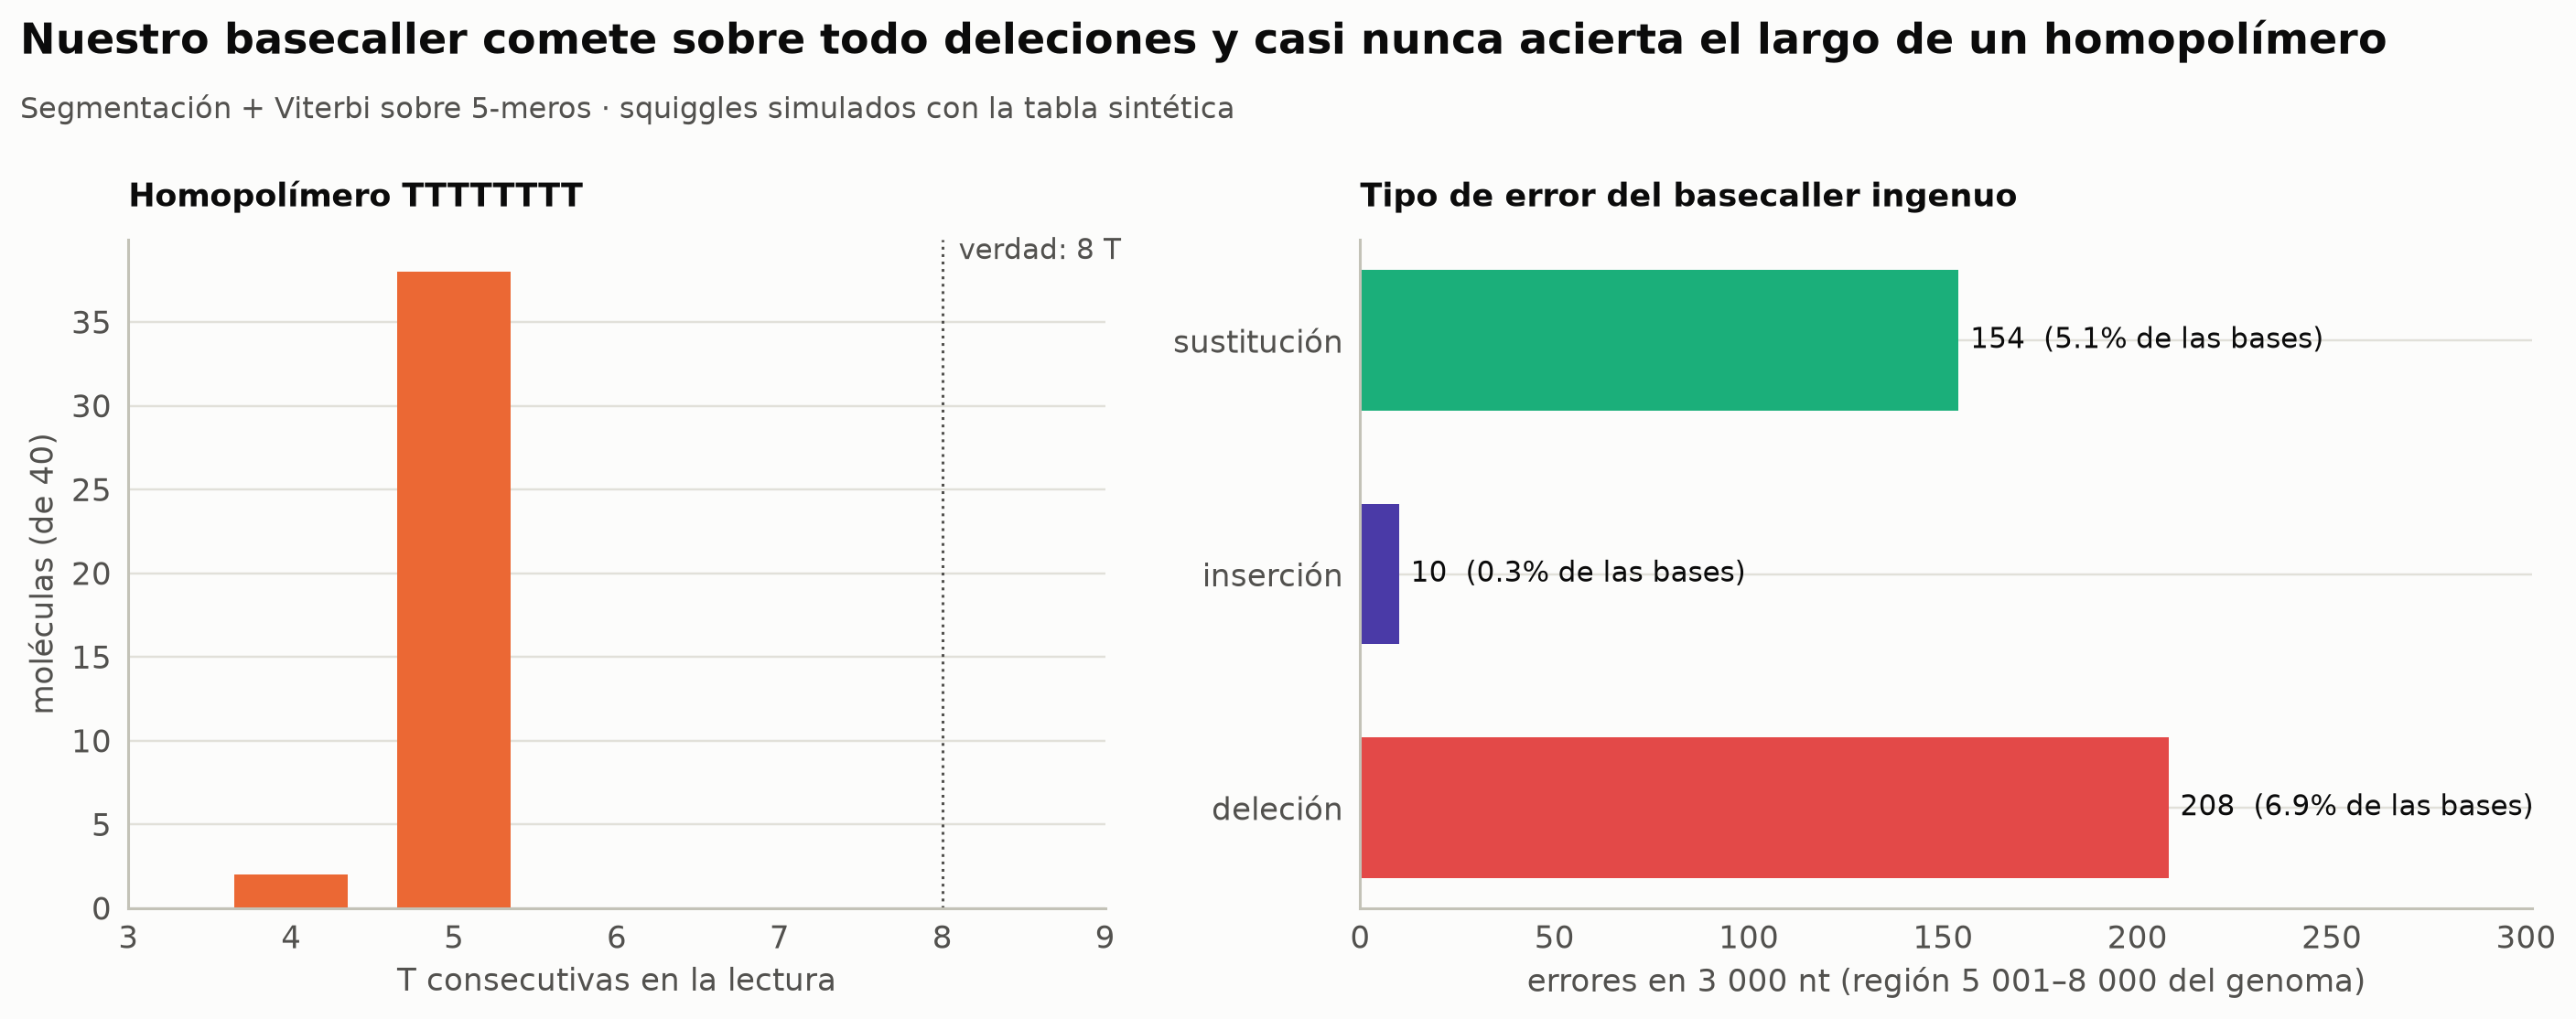

In [22]:
hp_counts, other_err = [], []
for rep in range(40):
    s_, _, _ = squiggle(region, np.random.default_rng(100 + rep))
    b_ = segment_signal(s_)
    call_ = viterbi_basecall(np.array([s_[a:b].mean() for a, b in zip(b_[:-1], b_[1:])]))
    runs_ = [len(m.group()) for m in re.finditer(r"T{4,}", call_)]
    hp_counts.append(max(runs_) if runs_ else 0)
hp_counts = np.array(hp_counts)
print("Longitud del homopolímero llamada en 40 moléculas:", Counter(hp_counts.tolist()).most_common())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw=dict(width_ratios=[1, 1.2]))
ax = axes[0]
vals, cnts = np.unique(hp_counts, return_counts=True)
ax.bar(vals, cnts, color=[ec.BLUE if v == 8 else ec.ORANGE for v in vals], width=0.7)
ax.axvline(8, color=ec.INK_2, ls=":", lw=1); ax.text(8.1, cnts.max() * 1.02, "verdad: 8 T", fontsize=10, color=ec.INK_2)
ax.set_xlabel("T consecutivas en la lectura"); ax.set_ylabel("moléculas (de 40)")
ax.set_xticks(range(max(3, vals.min() - 1), max(10, vals.max() + 2)))
ax.set_title("Homopolímero TTTTTTTT", loc="left", fontsize=11.5)
ax = axes[1]
kinds = ["sustitución", "inserción", "deleción"]
ax.barh(kinds[::-1], [ops[k] for k in kinds[::-1]], color=[ec.AQUA, ec.VIOLET, ec.RED][::-1], height=0.6)
for i, k in enumerate(kinds[::-1]):
    ax.text(ops[k] + 3, i, f"{ops[k]}  ({ops[k] / len(ont_true):.1%} de las bases)", va="center", fontsize=10)
ax.set_xlim(0, max(ops[k] for k in kinds) * 1.45)
ax.set_xlabel("errores en 3 000 nt (región 5 001–8 000 del genoma)")
ax.set_title("Tipo de error del basecaller ingenuo", loc="left", fontsize=11.5)
ec.fig_title(fig, "Nuestro basecaller comete sobre todo deleciones y casi nunca acierta el largo de un homopolímero",
             "Segmentación + Viterbi sobre 5-meros · squiggles simulados con la tabla sintética")
plt.tight_layout(); plt.show()

> 🔎 **Qué observamos.** Nuestro *basecaller* de 30 líneas alcanza una identidad parecida a la de los primeros años de
> Nanopore, y su error dominante es la **deleción**: cuando dos escalones vecinos tienen niveles casi iguales, la
> segmentación los fusiona y se pierde una base. En el homopolímero el problema es de fondo: la señal es plana, y el
> algoritmo no tiene cómo saber si pasaron 5 u 8 T (en el ejercicio 3 lo mejoraremos usando la duración). Los
> *basecallers* neuronales modernos con la química R10.4.1 alcanzan Q20 o más (≥ 99 %) por lectura, pero los homopolímeros
> largos siguen siendo su punto débil.

✅ **Compruebe su comprensión.** Si la química tuviera $k = 9$ en vez de $k = 5$, ¿con cuántas T seguidas empezaría a
aparecer el escalón plano? (Respuesta: con 10 o más; un homopolímero de longitud $h$ produce $h - k + 1$ k-meros idénticos
seguidos, y hace falta al menos dos para que la señal "no cambie".)

## 8. PacBio HiFi: el consenso circular

Pacific Biosciences también lee **moléculas individuales en tiempo real** (Eid et al., 2009), pero con luz. La celda
(*SMRT Cell*) tiene millones de pocillos diminutos, las **guías de onda de modo cero** (ZMW), tan estrechos que la luz
del láser sólo ilumina un volumen de unos pocos zeptolitros en el fondo. Allí hay **una sola polimerasa** fija copiando
una molécula. Los nucleótidos llevan el fluoróforo en la cadena de fosfatos, que la polimerasa **libera** al
incorporarlos: cada incorporación produce un destello del color de la base, y la cámara filma la síntesis como una
película.

Una sola pasada tiene muchos errores (del orden de 10–15 %, casi todos inserciones y deleciones **al azar**). La
solución es la librería **SMRTbell**: se ligan adaptadores en forma de horquilla a ambos extremos de un fragmento de doble
hebra, que queda **circular**. La polimerasa da vueltas y vueltas, y lee la misma molécula (alternando sus dos hebras)
muchas veces. Cada vuelta es una **subread**; el **consenso circular** (CCS) de todas ellas es la lectura **HiFi**
(Wenger et al., 2019), por definición con precisión ≥ Q20 (99 %) y típicamente de 10–25 kb.

### ¿Por qué el consenso mejora tanto? Votación por mayoría

Supongamos que cada pasada se equivoca en una posición con probabilidad $e$, **independientemente** de las demás pasadas.
Con $n$ pasadas (impar), el consenso por mayoría se equivoca sólo si **más de la mitad** de las pasadas se equivocan:

$$
P_{\text{error}}(n) \;=\; \sum_{j=(n+1)/2}^{n} \binom{n}{j}\, e^{\,j}\, (1-e)^{\,n-j}
\qquad\qquad
Q_{\text{CCS}} = -10\log_{10} P_{\text{error}}(n)
$$

| Símbolo | Significado |
|---|---|
| $e$ | probabilidad de error de una pasada en una posición |
| $n$ | número de pasadas (subreads) |
| $j$ | número de pasadas que se equivocan |
| $\binom{n}{j}$ | formas de elegir cuáles $j$ pasadas se equivocan |

### Ejemplo a mano, con $e = 0.1$

| $n$ | Cuenta | $P_{\text{error}}$ | $Q$ |
|---|---|---|---|
| 1 | $0.1$ | 0.1 | 10 |
| 3 | $3(0.1)^2(0.9) + (0.1)^3 = 0.027 + 0.001$ | 0.028 | 15.5 |
| 5 | $10(0.1)^3(0.9)^2 + 5(0.1)^4(0.9) + (0.1)^5$ | 0.0086 | 20.7 |
| 9 | $126(0.1)^5(0.9)^4 + 84(0.1)^6(0.9)^3 + \dots$ | 0.00089 | 30.5 |
| 15 | $6\,435(0.1)^8(0.9)^7 + 5\,005(0.1)^9(0.9)^6 + \dots$ | $3.4 \times 10^{-5}$ | 44.7 |

Con **9 pasadas**, un método que se equivoca en 1 de cada 10 bases produce un consenso que se equivoca en menos de 1 de
cada 1 000, y con **15** (el libro llama $k$ a este número) llega a Q44.7. La cota es pesimista: en la realidad, varias
pasadas erróneas rara vez coinciden en el **mismo** error. Wenger et al. (2019) obtuvieron así lecturas HiFi con 99.8 %
de exactitud y 13.5 kb de longitud media. La condición clave es la **independencia**: si un error fuera **sistemático** (se repite igual en todas las
pasadas, como los errores dependientes del contexto), votar no ayudaría en nada. Por eso el consenso funciona muy bien en
PacBio (errores aleatorios) y mucho peor para los errores de homopolímero de Nanopore, que se repiten molécula tras
molécula.

In [23]:
def majority_error(e, n):
    """Probabilidad de que la mayoría de n pasadas se equivoque (en un empate, la mitad de las veces)."""
    j = np.arange(n + 1)
    pj = binom.pmf(j, n, e)
    return pj[j > n / 2].sum() + 0.5 * pj[j == n / 2].sum()

def simulate_ccs(e, n, n_pos=200_000, systematic=0.0, rng=rng):
    """Consenso por pluralidad de n pasadas con errores de sustitución (la base equivocada se elige al azar entre 3).
    Una fracción `systematic` de posiciones se equivoca igual en todas las pasadas."""
    truth = np.zeros(n_pos, dtype=int)
    wrong = rng.random((n, n_pos)) < e
    reads = np.where(wrong, (truth + rng.integers(1, 4, (n, n_pos))) % 4, truth)
    sysm = rng.random(n_pos) < systematic
    reads[:, sysm] = 1
    counts = np.stack([(reads == b).sum(0) for b in range(4)])
    counts = counts + rng.random(counts.shape) * 0.1           # desempate al azar
    return (counts.argmax(0) != truth).mean()

for n in (1, 3, 5, 9):
    print(f"n = {n}: fórmula de mayoría = {majority_error(0.1, n):.5f} (Q{-10 * np.log10(majority_error(0.1, n)):.1f})"
          f"   ·   simulación con 4 bases (pluralidad) = {simulate_ccs(0.1, n):.5f}")

n = 1: fórmula de mayoría = 0.10000 (Q10.0)   ·   simulación con 4 bases (pluralidad) = 0.10017
n = 3: fórmula de mayoría = 0.02800 (Q15.5)   ·   simulación con 4 bases (pluralidad) = 0.02232
n = 5: fórmula de mayoría = 0.00856 (Q20.7)   ·   simulación con 4 bases (pluralidad) = 0.00398
n = 9: fórmula de mayoría = 0.00089 (Q30.5)   ·   simulación con 4 bases (pluralidad) = 0.00006


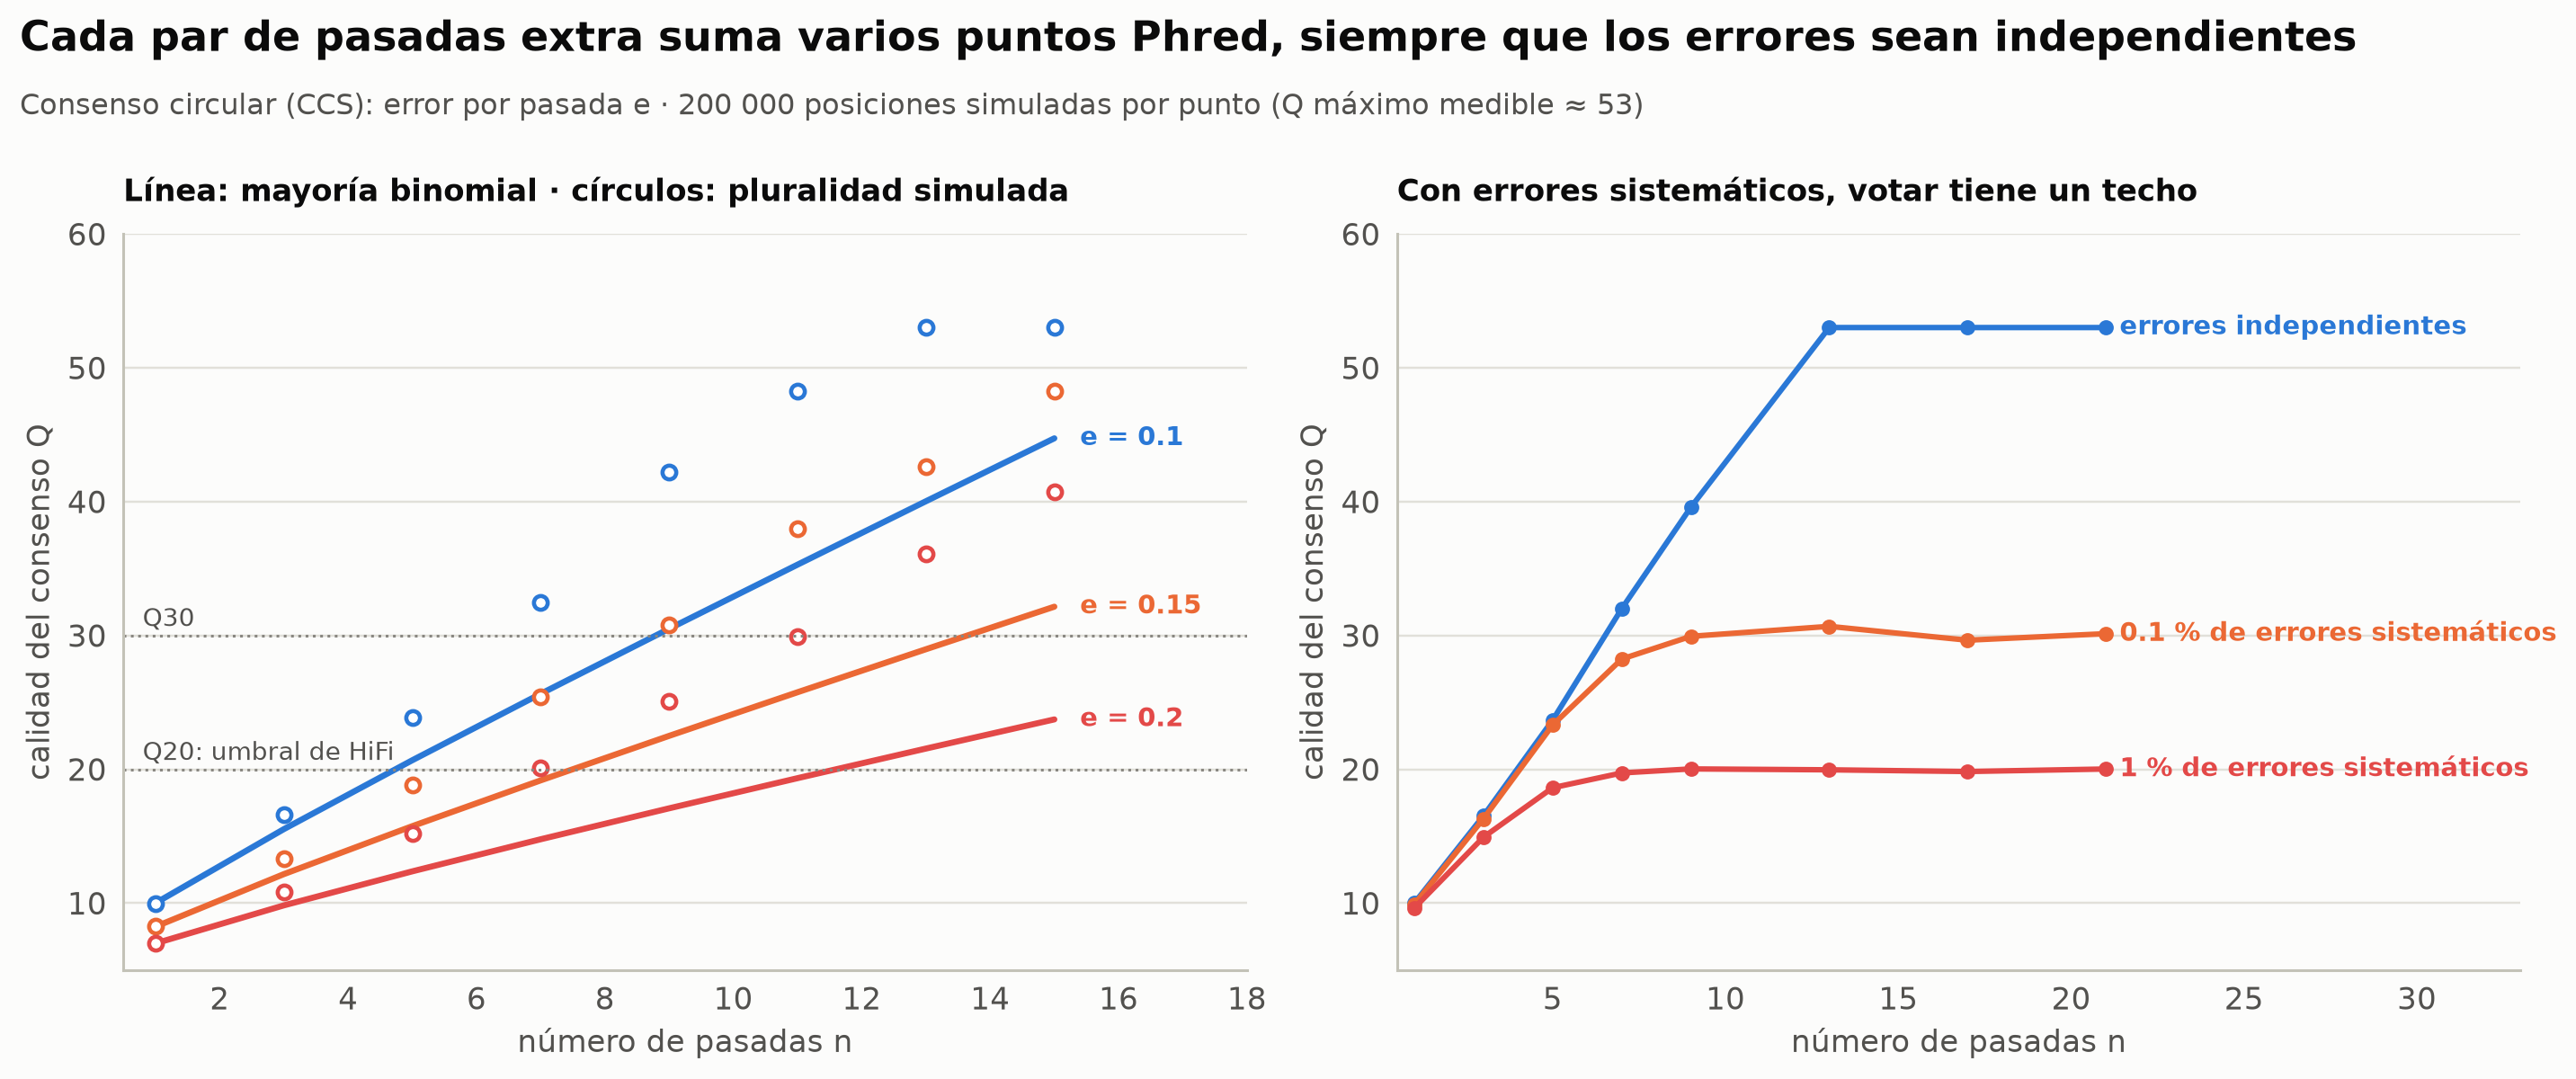

In [24]:
ns = np.arange(1, 16, 2)                                     # sólo impares: con n par hay empates
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
ax = axes[0]
for e, col in [(0.10, ec.BLUE), (0.15, ec.ORANGE), (0.20, ec.RED)]:
    q_th = [-10 * np.log10(max(majority_error(e, n), 1e-9)) for n in ns]
    ax.plot(ns, q_th, color=col, lw=2.2)
    ax.text(ns[-1] + 0.4, q_th[-1], f"e = {e}", color=col, fontsize=9.5, va="center", fontweight="bold")
    sim_n = [1, 3, 5, 7, 9, 11, 13, 15]
    q_sim = [-10 * np.log10(max(simulate_ccs(e, n), 1 / 200_000)) for n in sim_n]
    ax.plot(sim_n, q_sim, "o", color=col, ms=5, mfc="white", mew=1.5)
ax.axhline(20, color=ec.MUTED, ls=":", lw=1); ax.text(0.8, 20.7, "Q20: umbral de HiFi", fontsize=9, color=ec.INK_2)
ax.axhline(30, color=ec.MUTED, ls=":", lw=1); ax.text(0.8, 30.7, "Q30", fontsize=9, color=ec.INK_2)
ax.set_xlim(0.5, 18); ax.set_ylim(5, 60)
ax.set_xlabel("número de pasadas n"); ax.set_ylabel("calidad del consenso Q")
ax.set_title("Línea: mayoría binomial · círculos: pluralidad simulada", loc="left", fontsize=11)

ax = axes[1]
for sysf, col, lab in [(0.0, ec.BLUE, "errores independientes"), (0.001, ec.ORANGE, "0.1 % de errores sistemáticos"),
                       (0.01, ec.RED, "1 % de errores sistemáticos")]:
    sim_n = [1, 3, 5, 7, 9, 13, 17, 21]
    q_sim = [-10 * np.log10(max(simulate_ccs(0.1, n, systematic=sysf), 1 / 200_000)) for n in sim_n]
    ax.plot(sim_n, q_sim, "-o", color=col, ms=4.5, lw=2)
    ax.text(sim_n[-1] + 0.4, q_sim[-1], lab, color=col, fontsize=9.5, va="center", fontweight="bold")
ax.set_xlim(0.5, 33); ax.set_ylim(5, 60)
ax.set_xlabel("número de pasadas n"); ax.set_ylabel("calidad del consenso Q")
ax.set_title("Con errores sistemáticos, votar tiene un techo", loc="left", fontsize=11)
ec.fig_title(fig, "Cada par de pasadas extra suma varios puntos Phred, siempre que los errores sean independientes",
             "Consenso circular (CCS): error por pasada e · 200 000 posiciones simuladas por punto (Q máximo medible ≈ 53)")
plt.tight_layout(); plt.show()

> 🔎 **Qué observamos.** La calidad crece casi **linealmente** con el número de pasadas: con $e = 0.1$, unos 5 puntos
> Phred por cada par de pasadas extra (con $n$ par hay empates, por eso sólo graficamos $n$ impar). La simulación (círculos) queda **por encima** de la fórmula porque, con cuatro bases, los
> votos equivocados se reparten entre tres bases distintas y rara vez se ponen de acuerdo. A la derecha, basta que el
> 1 % de las posiciones tenga un error sistemático para que la calidad se **estanque** en Q20, por muchas pasadas que
> sumemos. En el CCS real las pasadas tienen sobre todo **indels**, así que el consenso no es una simple votación por
> columnas: primero hay que **alinear** las subreads entre sí (con un grafo de orden parcial o un HMM de pares), pero la
> lógica de fondo es la misma.

## 🎬 Animación: el consenso se limpia pasada a pasada

Nueve pasadas simuladas sobre 40 bases del gen S, cada una con 12 % de errores (sustituciones y deleciones, mostradas ya
alineadas; el guion `−` es una base que la pasada se saltó). Abajo, el consenso por mayoría de las pasadas vistas hasta
ese momento.

![Consenso circular de PacBio: con cada pasada nueva, la votación por mayoría corrige los errores aleatorios de las pasadas individuales](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-06-ngs/6.1_ccs_pasadas.gif)

*Consenso circular de PacBio: con cada pasada nueva, la votación por mayoría corrige los errores aleatorios de las pasadas individuales*

In [25]:
ccs_true = GENOME[SPIKE_START + 1200:SPIKE_START + 1240]
N_PASS, E_PASS = 9, 0.12
rng_ccs = np.random.default_rng(12)
passes = []
for _ in range(N_PASS):
    row = []
    for b in ccs_true:
        u = rng_ccs.random()
        if u < E_PASS / 2:
            row.append("−")                                            # deleción
        elif u < E_PASS:
            row.append(rng_ccs.choice([x for x in BASES if x != b]))   # sustitución
        else:
            row.append(b)
    passes.append(row)

def consensus(rows):
    out = []
    for col in zip(*rows):
        c = Counter(col).most_common()
        out.append(c[0][0] if len(c) == 1 or c[0][1] > c[1][1] else "?")
    return out

frames_per_pass = 3
plan = [(p, k) for p in range(N_PASS) for k in range(frames_per_pass)] + [(N_PASS - 1, frames_per_pass)] * 5
fig, ax = plt.subplots(figsize=(13, 5.8))

def update(f):
    p, k = plan[f]
    ax.clear(); ax.set_xlim(-6, len(ccs_true) + 1); ax.set_ylim(N_PASS + 3.4, -2.2); ax.axis("off")
    ax.text(-5.8, -1.2, "molde", fontsize=10, color=ec.INK_2, va="center")
    for j, b in enumerate(ccs_true):
        ax.text(j, -1.2, b, ha="center", va="center", family="monospace", fontsize=11, color=ec.MUTED)
    shown = passes[:p] + [passes[p][:int(len(ccs_true) * min(1, (k + 1) / frames_per_pass))]]
    for i, row in enumerate(shown):
        ax.text(-5.8, i, f"pasada {i + 1}", fontsize=10, color=ec.INK_2, va="center")
        for j, b in enumerate(row):
            ok = b == ccs_true[j]
            ax.text(j, i, b, ha="center", va="center", family="monospace", fontsize=11,
                    color=ec.NUC_COLORS.get(b, ec.INK) if ok else ec.RED, fontweight="normal" if ok else "bold",
                    bbox=None if ok else dict(boxstyle="square,pad=0.12", fc="#f3b0ae", ec="none"))
    done = passes[:p + 1] if k >= frames_per_pass - 1 else passes[:p] or [passes[0]]
    cons = consensus(done)
    y = N_PASS + 1.6
    ax.plot([-6, len(ccs_true)], [y - 0.9, y - 0.9], color=ec.BASELINE, lw=1)
    ax.text(-5.8, y, "consenso", fontsize=10.5, color=ec.INK, fontweight="bold", va="center")
    for j, b in enumerate(cons):
        ok = b == ccs_true[j]
        ax.text(j, y, b, ha="center", va="center", family="monospace", fontsize=12, fontweight="bold",
                color=ec.NUC_COLORS.get(b, ec.INK) if ok else ec.RED,
                bbox=None if ok else dict(boxstyle="square,pad=0.12", fc="#f3b0ae", ec="none"))
    n_err = sum(b != t for b, t in zip(cons, ccs_true))
    raw_err = np.mean([b != t for row in done for b, t in zip(row, ccs_true)])
    ax.set_title(f"Consenso con {len(done)} pasada(s): {n_err} errores en {len(ccs_true)} bases   ·   "
                 f"error medio de una pasada: {raw_err:.0%}", loc="left", fontsize=12)
    return []

ec.animate(fig, update, frames=len(plan), interval=260, name="6.1_ccs_pasadas")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Con una sola pasada el consenso es la pasada misma, con sus errores. Con dos, cualquier
> desacuerdo es un empate (`?`): no hay mayoría. A partir de tres pasadas los errores aislados quedan en minoría y
> desaparecen, y al final el consenso coincide con el molde aunque cada pasada individual siga equivocándose en una de
> cada ocho bases.

✅ **Compruebe su comprensión.** Si la polimerasa lee en total 90 kb antes de detenerse, ¿cuántas pasadas completas
obtenemos de un inserto de 15 kb? ¿Y de uno de 45 kb? (Respuesta: 6 y 2. Los insertos largos dan lecturas más largas
pero con menos pasadas: por eso las librerías HiFi suelen ser de 15–20 kb, un compromiso entre longitud y precisión.)

## 9. 🧪 Nuestro propio simulador de lecturas sobre SARS-CoV-2

Juntemos todo en un simulador que produzca lecturas de las tres tecnologías a partir del genoma real de SARS-CoV-2
(29 903 nt). Cada tecnología tiene un **perfil** distinto: cómo se distribuye la longitud de las lecturas y qué tipo de
errores comete. Los parámetros son **ilustrativos**, elegidos para imitar el comportamiento típico descrito en la
literatura, no medidos de una corrida concreta.

| Perfil | Longitud de lectura | Errores |
|---|---|---|
| **Illumina** 2 × 150 | fija (150), pares con inserto ~ Normal(350, 70) | sustituciones, con la tasa por ciclo que **medimos** en la sección 5; indels casi nulos |
| **Nanopore** (química tipo R9) | log-normal, mediana 3 kb | ~2 % sustituciones, ~1.5 % inserciones, ~2 % deleciones; deleciones × 4 en homopolímeros |
| **PacBio HiFi** | inserto ~ Normal(15 kb, 3 kb) | 7–13 % de error por pasada; la tasa de cada lectura sale de su número de pasadas (sección 8); 70 % indels; las pasadas individuales tienen errores aproximadamente aleatorios, y el error **residual** del consenso se concentra en homopolímeros (por eso lo ponemos ahí); se descartan las lecturas < Q20 |

Una aclaración de realismo: en la vigilancia genómica de SARS-CoV-2 casi nunca se secuencia el genoma entero de una
vez. El protocolo más usado (ARTIC; Quick et al., 2017) amplifica el genoma en ~100 **amplicones** de ~400 pb por PCR y
los lee con Illumina o Nanopore. Usar lecturas de 15 kb sobre un virus de 30 kb es una simplificación didáctica: el
genoma sólo nos sirve de "molde real".

### Cómo introducimos los errores

Para cada base del molde sorteamos un número uniforme $u$ y decidimos: si $u < p_{\text{del}}$, la base se **borra**; si
$p_{\text{del}} \le u < p_{\text{del}} + p_{\text{sust}}$, se **cambia** por otra de las tres; además, con probabilidad
$p_{\text{ins}}$ se **añade** una base al azar detrás de ella. Como el simulador sabe qué hizo, conocemos la **verdad**
de cada lectura sin necesidad de alinear. El número esperado de errores de una lectura de longitud $L$ es:

$$
\mathbb E[\text{errores}] \;=\; L\,(p_{\text{sust}} + p_{\text{ins}} + p_{\text{del}})
\qquad\qquad
\text{identidad} \;=\; 1 - \frac{\text{errores}}{L}
$$

Por ejemplo, una lectura de Nanopore de 3 000 nt con $p = 0.02 + 0.015 + 0.02 = 0.055$ tendrá unos
$3\,000 \times 0.055 = 165$ errores: identidad ≈ 94.5 %, es decir $Q = -10\log_{10}(0.055) \approx 12.6$.

In [26]:
LUT = np.full(256, -1); LUT[np.frombuffer(b"ACGT", np.uint8)] = np.arange(4)

def homopolymer_mask(seq, min_run=4):
    """True en las posiciones que forman parte de un homopolímero de al menos min_run bases."""
    m = np.zeros(len(seq), dtype=bool)
    for r in re.finditer(r"A{%d,}|C{%d,}|G{%d,}|T{%d,}" % ((min_run,) * 4), seq):
        m[r.start():r.end()] = True
    return m

def mutate(template, p_sub, p_ins, p_del, rng):
    """Introduce errores en una secuencia molde. Las probabilidades pueden ser escalares o vectores (una por base).
    Devuelve la lectura y las máscaras de sustitución, inserción y deleción (en coordenadas del molde)."""
    t = LUT[np.frombuffer(template.encode(), np.uint8)]
    n = len(t)
    u = rng.random(n)
    is_del = u < p_del
    is_sub = ~is_del & (u < p_del + p_sub)
    is_ins = rng.random(n) < p_ins
    base = np.where(is_sub, (t + rng.integers(1, 4, n)) % 4, t)
    stacked = np.stack([base, rng.integers(0, 4, n)], 1)       # columna 2: la base insertada
    keep = np.stack([~is_del, is_ins], 1)
    read = "".join(np.array(list(BASES))[stacked[keep]])
    return read, is_sub, is_ins, is_del

PREFIX = {"Illumina": "ill", "Nanopore": "ont", "PacBio HiFi": "hifi"}

def record(tech, i, start, template, read, is_sub, is_ins, is_del, p_total):
    """Resumen de una lectura: errores reales (conocidos por el simulador) y la calidad que predice el modelo."""
    hp = homopolymer_mask(template)
    n_err = is_sub.sum() + is_ins.sum() + is_del.sum()
    return dict(tech=tech, read=f"{PREFIX.get(tech, 'r10')}_{i:04d}", start=start, length=len(template), read_len=len(read),
                Q_pred=-10 * np.log10(np.mean(np.broadcast_to(p_total, (len(template),)))),
                sub=int(is_sub.sum()), ins=int(is_ins.sum()), dele=int(is_del.sum()), errors=int(n_err),
                identity=1 - n_err / len(template), Q=-10 * np.log10(max(n_err, 0.5) / len(template)),
                hp_err=int((is_sub | is_ins | is_del)[hp].sum()), hp_bases=int(hp.sum()),
                nonhp_err=int((is_sub | is_ins | is_del)[~hp].sum()), nonhp_bases=int((~hp).sum()))

rng_sim = np.random.default_rng(2024)
rows, read_seqs = [], {}

# --- Illumina 2 x 150: tasa de sustitución por ciclo tomada de la sección 5
err_cycle = pd.Series(results["p = 0.002, q = 0.001 (típico)"]["err"]).rolling(9, center=True, min_periods=1).mean()
err_cycle = np.maximum(err_cycle.values, 1e-4)
for i, (r1, r2, s, L) in enumerate(make_pairs(1500, rng=rng_sim)):
    if L < READ_L:
        continue
    m = rng_sim.lognormal(0, 0.4)                                        # clústeres mejores y peores
    for tmpl_seq, mult, st in ((r1, 1.0, s), (r2, 1.5, s + L - READ_L)):   # R2 es algo peor que R1
        p_sub = err_cycle * mult * m
        rd, a, b, c = mutate(tmpl_seq, p_sub, 1e-5, 1e-5, rng_sim)
        rows.append(record("Illumina", len(rows), st, tmpl_seq, rd, a, b, c, p_sub + 2e-5))

# --- Nanopore (tipo R9): lecturas largas, indels, deleciones en homopolímeros
for i in range(300):
    L = int(np.clip(rng_sim.lognormal(np.log(3000), 0.9), 200, len(GENOME)))
    s = int(rng_sim.integers(0, len(GENOME) - L + 1))
    tmpl_seq = GENOME[s:s + L] if rng_sim.random() < 0.5 else revcomp(GENOME[s:s + L])
    hp = homopolymer_mask(tmpl_seq)
    m = rng_sim.lognormal(0, 0.3)                                        # cada poro / molécula tiene su calidad
    p_del = np.where(hp, 0.08, 0.02) * m
    rd, a, b, c = mutate(tmpl_seq, 0.02 * m, 0.015 * m, p_del, rng_sim)
    rows.append(record("Nanopore", i, s, tmpl_seq, rd, a, b, c, 0.035 * m + p_del))
    read_seqs[("Nanopore", i)] = (tmpl_seq, rd)

# --- PacBio HiFi: la precisión de cada lectura depende de sus pasadas
n_hifi, kept = 0, 0
while kept < 150:
    L = int(np.clip(rng_sim.normal(15000, 3000), 5000, len(GENOME)))
    n_pass = int(rng_sim.lognormal(np.log(150_000), 0.5) // L)          # la polimerasa lee ~150 kb en total
    n_hifi += 1
    if n_pass < 1:
        continue
    e_read = max(majority_error(rng_sim.uniform(0.07, 0.13), n_pass), 1e-5)   # error por pasada: 7–13 %
    if e_read > 0.01:                                                   # HiFi = sólo lecturas ≥ Q20
        continue
    s = int(rng_sim.integers(0, len(GENOME) - L + 1))
    tmpl_seq = GENOME[s:s + L] if rng_sim.random() < 0.5 else revcomp(GENOME[s:s + L])
    hp = homopolymer_mask(tmpl_seq)
    w = np.where(hp, 4.0, 1.0); w = w / w.mean()                          # error residual del CCS: indels en homopolímeros
    rd, a, b, c = mutate(tmpl_seq, 0.3 * e_read, 0.35 * e_read * w, 0.35 * e_read * w, rng_sim)
    rows.append(record("PacBio HiFi", kept, s, tmpl_seq, rd, a, b, c, e_read * (0.3 + 0.7 * w))); kept += 1

reads = pd.DataFrame(rows)
TECHS = ["Illumina", "Nanopore", "PacBio HiFi"]
TECH_COL = {"Illumina": ec.BLUE, "Nanopore": ec.ORANGE, "PacBio HiFi": ec.AQUA}
summary = reads.groupby("tech").agg(lecturas=("read", "size"), bases=("length", "sum"), mediana_long=("length", "median"),
                                    errores=("errors", "sum"), Q_pred_mediana=("Q_pred", "median"))
summary["Q_observada_global"] = -10 * np.log10(summary.errores / summary.bases)
summary["cobertura"] = summary.bases / len(GENOME)
print(f"HiFi: {kept} de {n_hifi} moléculas superaron el filtro Q20")
summary.round(3)

HiFi: 150 de 169 moléculas superaron el filtro Q20


,lecturas,bases,mediana_long,errores,Q_pred_mediana,Q_observada_global,cobertura
tech,,,,,,,
Illumina,2996,449400,150.0,214,33.634,33.222,15.029
Nanopore,300,1196118,2819.5,74069,12.260,12.081,40.000
PacBio HiFi,150,2229076,14699.0,4571,32.662,26.881,74.544


Antes de confiar en el simulador, **validémoslo**: tomemos una lectura de Nanopore, alineémosla contra su molde con la
función `align_ops` (un Needleman-Wunsch con costo 1 por error, Lección 3.2) y comparemos los errores que encuentra el alineamiento
con los que el simulador dice haber introducido.

In [27]:
ont_rows = reads[reads.tech == "Nanopore"]
pick = ont_rows.iloc[(ont_rows.length - 2500).abs().argsort().iloc[0]]
tmpl_seq, rd = read_seqs[("Nanopore", int(pick.read.split("_")[1]))]
ops = align_ops(tmpl_seq, rd)
print(f"Lectura {pick.read}: molde {len(tmpl_seq)} nt, lectura {len(rd)} nt")
print(f"  según el simulador: sust. {pick['sub']}, ins. {pick.ins}, del. {pick.dele}  → {pick.errors} errores")
print(f"  según el alineamiento: sust. {ops['sustitución']}, ins. {ops['inserción']}, del. {ops['deleción']}  "
      f"→ distancia {ops['distancia']}")

Lectura ont_0225: molde 2489 nt, lectura 2456 nt
  según el simulador: sust. 63, ins. 56, del. 89  → 208 errores
  según el alineamiento: sust. 75, ins. 47, del. 80  → distancia 202


> 🔎 **Qué observamos.** La distancia de edición es igual o un poco **menor** que los errores introducidos: a veces dos
> errores se cancelan (una deleción seguida de una inserción de la misma base) o una deleción en un homopolímero puede
> ubicarse en cualquiera de sus posiciones. El alineador "ve" la explicación más económica, no la historia real. Es una
> idea importante para cuando alineemos lecturas reales: los errores que reporta un alineamiento son una **estimación** de los errores
> reales.

### ¿Cómo medimos la precisión de una lectura?

Hay dos maneras. La **observada** cuenta los errores reales: $Q_{\text{obs}} = -10\log_{10}(\text{errores}/L)$. Funciona
bien con lecturas largas, pero no con las de Illumina: en 150 nt con Q35 esperamos $150 \times 10^{-3.5} \approx 0.05$
errores, así que casi todas las lecturas tienen **cero** errores y su $Q_{\text{obs}}$ es infinito; haría falta leer
miles de bases para "ver" un error. La **predicha** es la que reporta el propio secuenciador en el FASTQ: el promedio de
las probabilidades de error de cada base (Lección 2.1), $Q_{\text{pred}} = -10\log_{10}\big(\tfrac1L\sum_j P_j\big)$.
Nuestro simulador conoce esas probabilidades porque las usó para introducir los errores, así que en los histogramas
usaremos la predicha y dejaremos la observada para la tasa global por tecnología (tabla anterior).

> 🤔 **Antes de ejecutar, prediga:** ¿cuál de las tres tecnologías tendrá la mayor proporción de sus errores en
> homopolímeros? ¿Y cuál la lectura más larga?

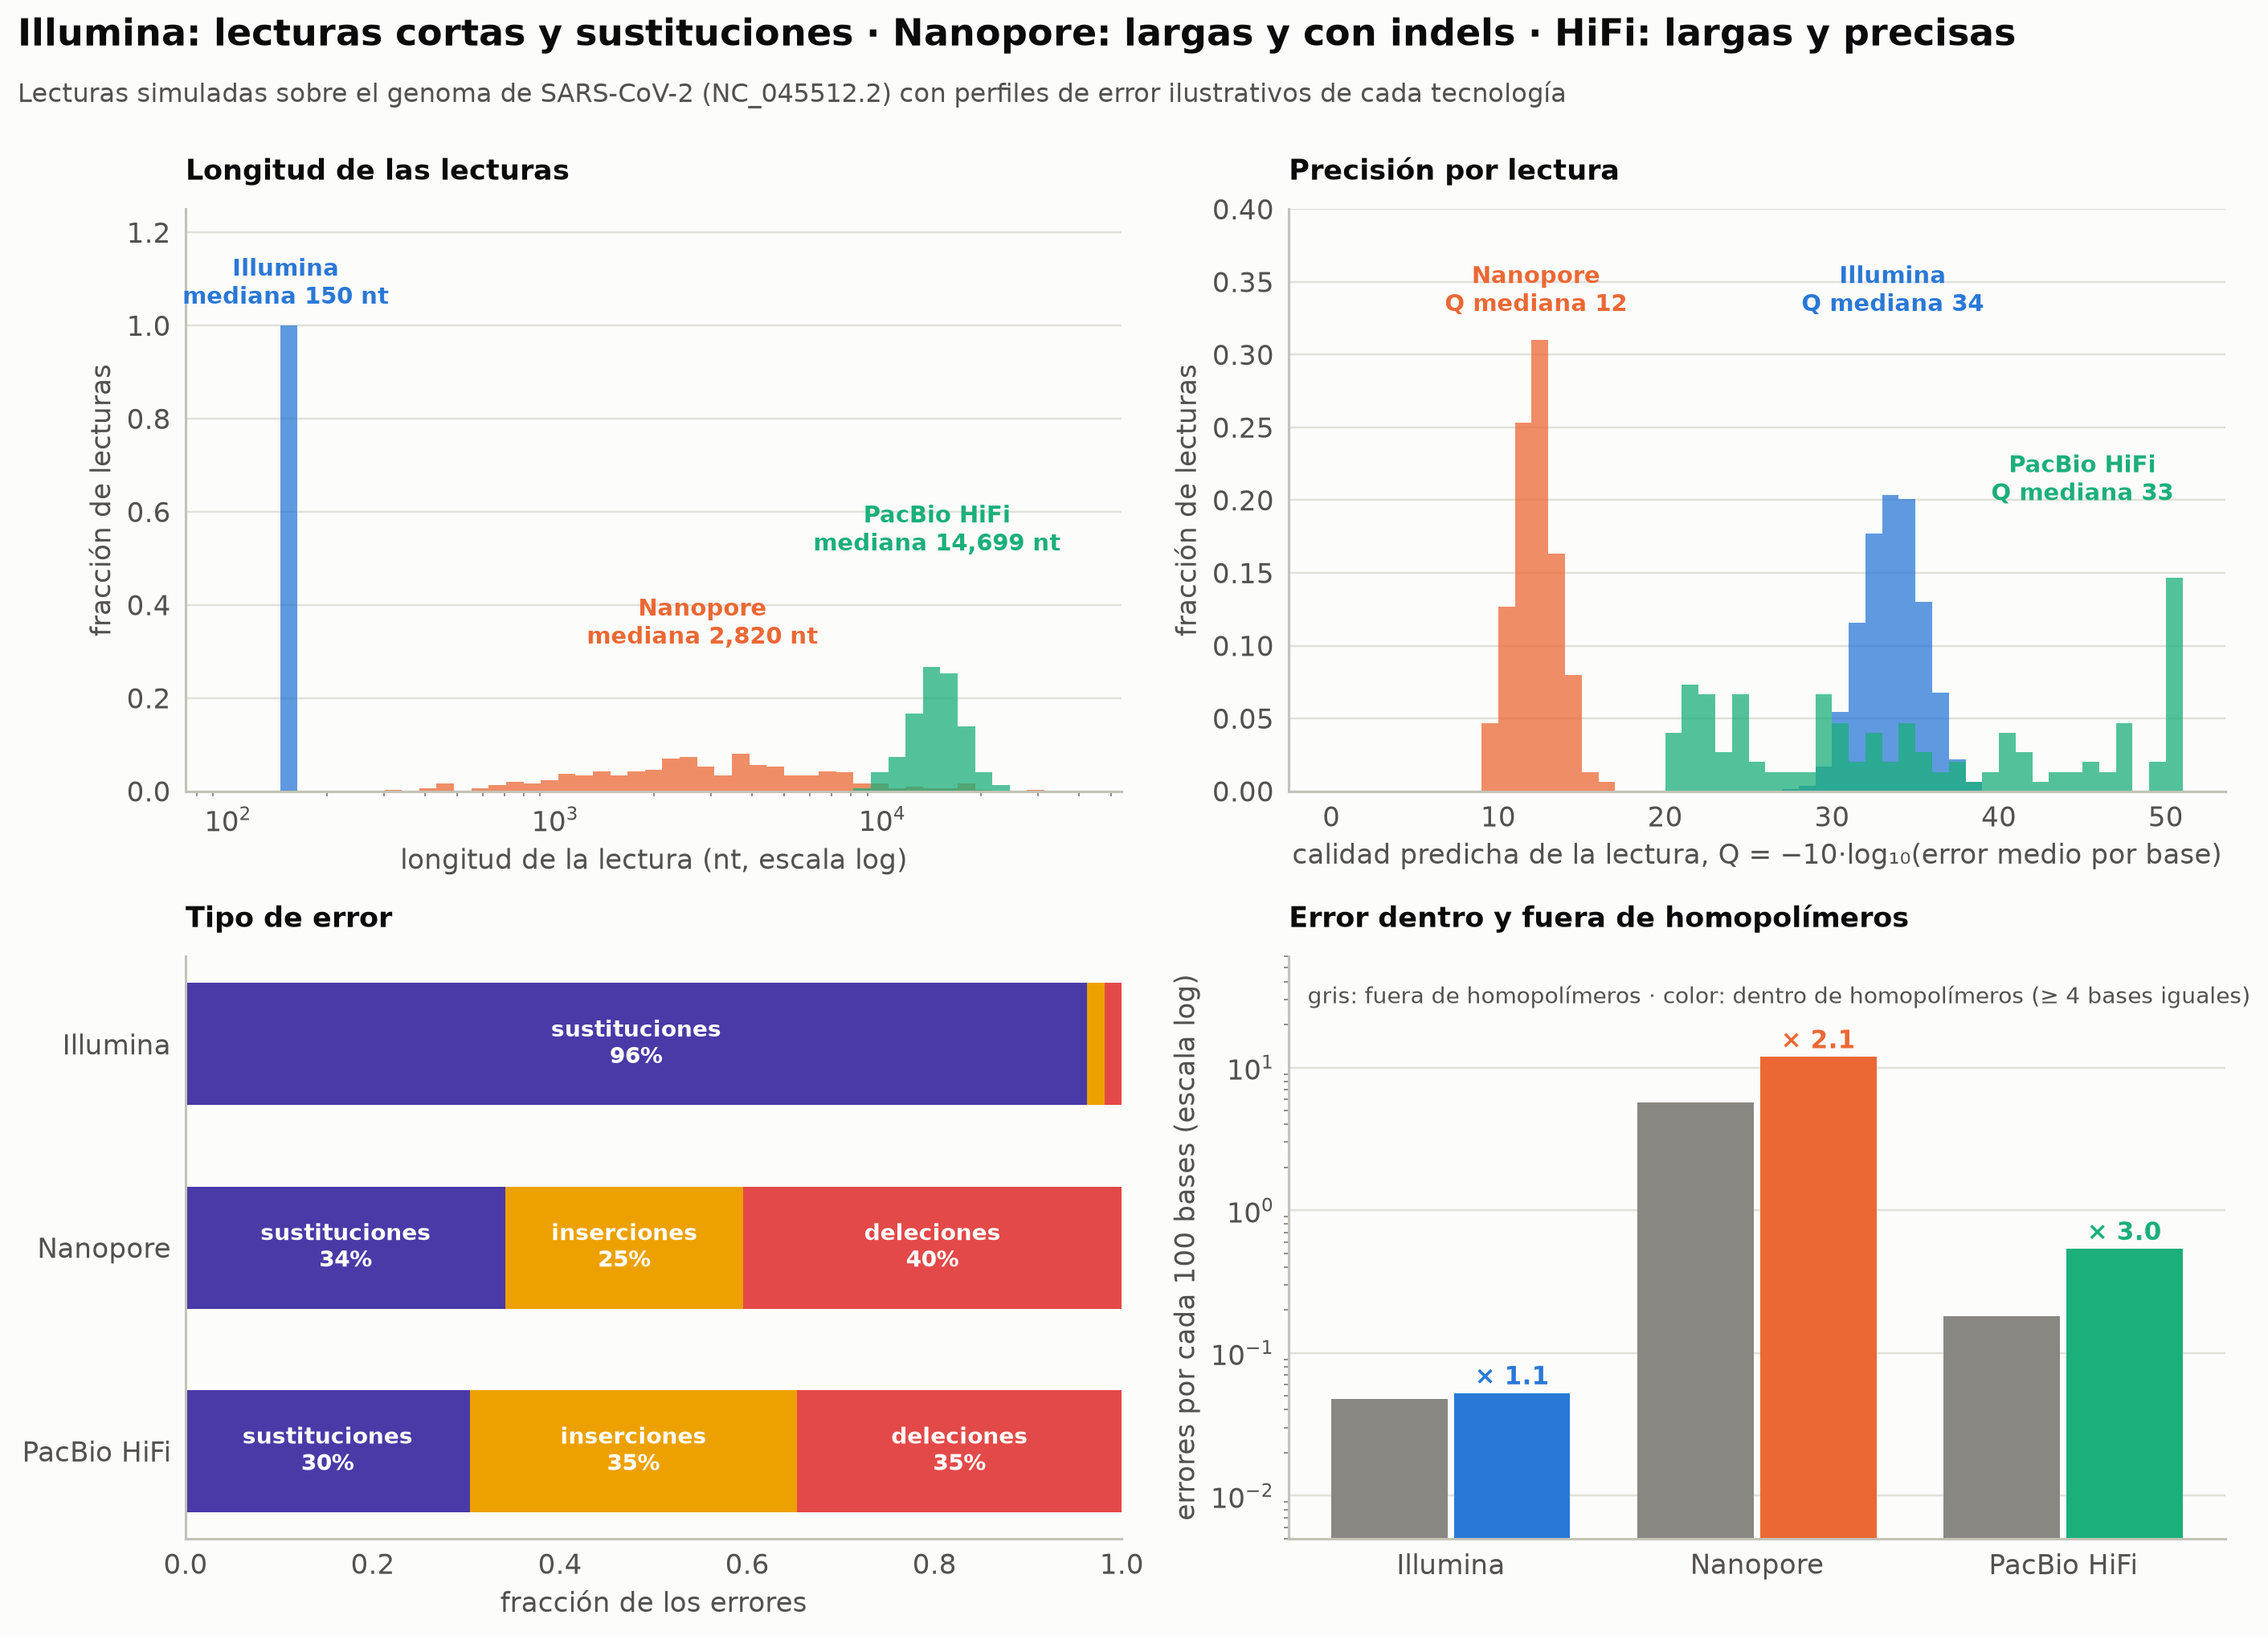

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.6))
ax = axes[0, 0]
bins = np.logspace(np.log10(100), np.log10(40000), 50)
for t in TECHS:
    d = reads[reads.tech == t]
    ax.hist(d.length, bins=bins, color=TECH_COL[t], alpha=0.75, weights=np.ones(len(d)) / len(d))
    ax.text(d.length.median(), {"Illumina": 1.03, "Nanopore": 0.3, "PacBio HiFi": 0.5}[t],
            f"{t}\nmediana {d.length.median():,.0f} nt", color=TECH_COL[t], fontsize=9.5, fontweight="bold",
            ha="center", va="bottom")
ax.set_xscale("log"); ax.set_ylim(0, 1.25)
ax.set_xlabel("longitud de la lectura (nt, escala log)"); ax.set_ylabel("fracción de lecturas")
ax.set_title("Longitud de las lecturas", loc="left", fontsize=11.5)

ax = axes[0, 1]
qb = np.arange(0, 52, 1)
for t in TECHS:
    d = reads[reads.tech == t]
    ax.hist(d.Q_pred.clip(upper=50), bins=qb, color=TECH_COL[t], alpha=0.75, weights=np.ones(len(d)) / len(d))
    ax.text({"Illumina": d.Q_pred.median(), "Nanopore": d.Q_pred.median(), "PacBio HiFi": 45}[t],
            {"Illumina": 0.33, "Nanopore": 0.33, "PacBio HiFi": 0.2}[t],
            f"{t}\nQ mediana {d.Q_pred.median():.0f}", color=TECH_COL[t], fontsize=9.5, fontweight="bold", ha="center")
ax.set_xlabel("calidad predicha de la lectura, Q = −10·log₁₀(error medio por base)"); ax.set_ylabel("fracción de lecturas")
ax.set_ylim(0, 0.4)
ax.set_title("Precisión por lectura", loc="left", fontsize=11.5)

ax = axes[1, 0]
tot = reads.groupby("tech")[["sub", "ins", "dele"]].sum().loc[TECHS]
frac = tot.div(tot.sum(1), axis=0)
left = np.zeros(len(TECHS))
for col, lab, c in [("sub", "sustituciones", ec.VIOLET), ("ins", "inserciones", ec.YELLOW), ("dele", "deleciones", ec.RED)]:
    ax.barh(TECHS[::-1], frac[col].values[::-1], left=left[::-1], color=c, height=0.6)
    for i, (l, v) in enumerate(zip(left[::-1], frac[col].values[::-1])):
        if v > 0.07:
            ax.text(l + v / 2, i, f"{lab}\n{v:.0%}", ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    left += frac[col].values
ax.set_xlim(0, 1); ax.set_xlabel("fracción de los errores")
ax.set_title("Tipo de error", loc="left", fontsize=11.5)

ax = axes[1, 1]
agg = reads.groupby("tech")[["hp_err", "hp_bases", "nonhp_err", "nonhp_bases"]].sum().loc[TECHS]
rate_hp = agg.hp_err / agg.hp_bases; rate_non = agg.nonhp_err / agg.nonhp_bases
x = np.arange(len(TECHS))
ax.bar(x - 0.2, rate_non * 100, width=0.38, color=ec.MUTED)
ax.bar(x + 0.2, rate_hp * 100, width=0.38, color=[TECH_COL[t] for t in TECHS])
for i, t in enumerate(TECHS):
    ax.text(i + 0.2, rate_hp[t] * 100 * 1.15, f"× {rate_hp[t] / rate_non[t]:.1f}", ha="center", fontsize=10,
            fontweight="bold", color=TECH_COL[t])
ax.set_yscale("log"); ax.set_xticks(x); ax.set_xticklabels(TECHS)
ax.set_ylabel("errores por cada 100 bases (escala log)")
ax.text(0.02, 0.95, "gris: fuera de homopolímeros · color: dentro de homopolímeros (≥ 4 bases iguales)",
        transform=ax.transAxes, fontsize=9, color=ec.INK_2, va="top")
ax.set_ylim(0.005, 60)
ax.set_title("Error dentro y fuera de homopolímeros", loc="left", fontsize=11.5)
ec.fig_title(fig, "Illumina: lecturas cortas y sustituciones · Nanopore: largas y con indels · HiFi: largas y precisas",
             "Lecturas simuladas sobre el genoma de SARS-CoV-2 (NC_045512.2) con perfiles de error ilustrativos de cada tecnología")
plt.tight_layout(); plt.show()

> 🔎 **Qué observamos.** Las tres tecnologías viven en mundos distintos. Illumina produce lecturas de exactamente 150 nt,
> con casi todos sus errores como **sustituciones** y una calidad alta (Q30–38). Las lecturas de Nanopore se extienden
> por dos órdenes de magnitud y tienen Q ≈ 12 (≈ 94 %), con errores repartidos entre los tres tipos y unas **dos veces**
> más frecuentes dentro de homopolímeros. HiFi combina lo mejor de ambos: lecturas de ~15 kb con Q ≈ 33 de mediana (y
> todas ≥ Q20, por el filtro), pero sus pocos errores residuales son indels **tres veces** más frecuentes en
> homopolímeros. Tenga presente que el simulador sólo devuelve lo que le pusimos: su valor es didáctico (ver cómo se
> traducen los perfiles en distribuciones) y como **control**: cuando un programa de control de calidad o un alineador
> analice lecturas simuladas así, sabremos exactamente qué respuesta debería dar.

### Cobertura a lo largo del genoma

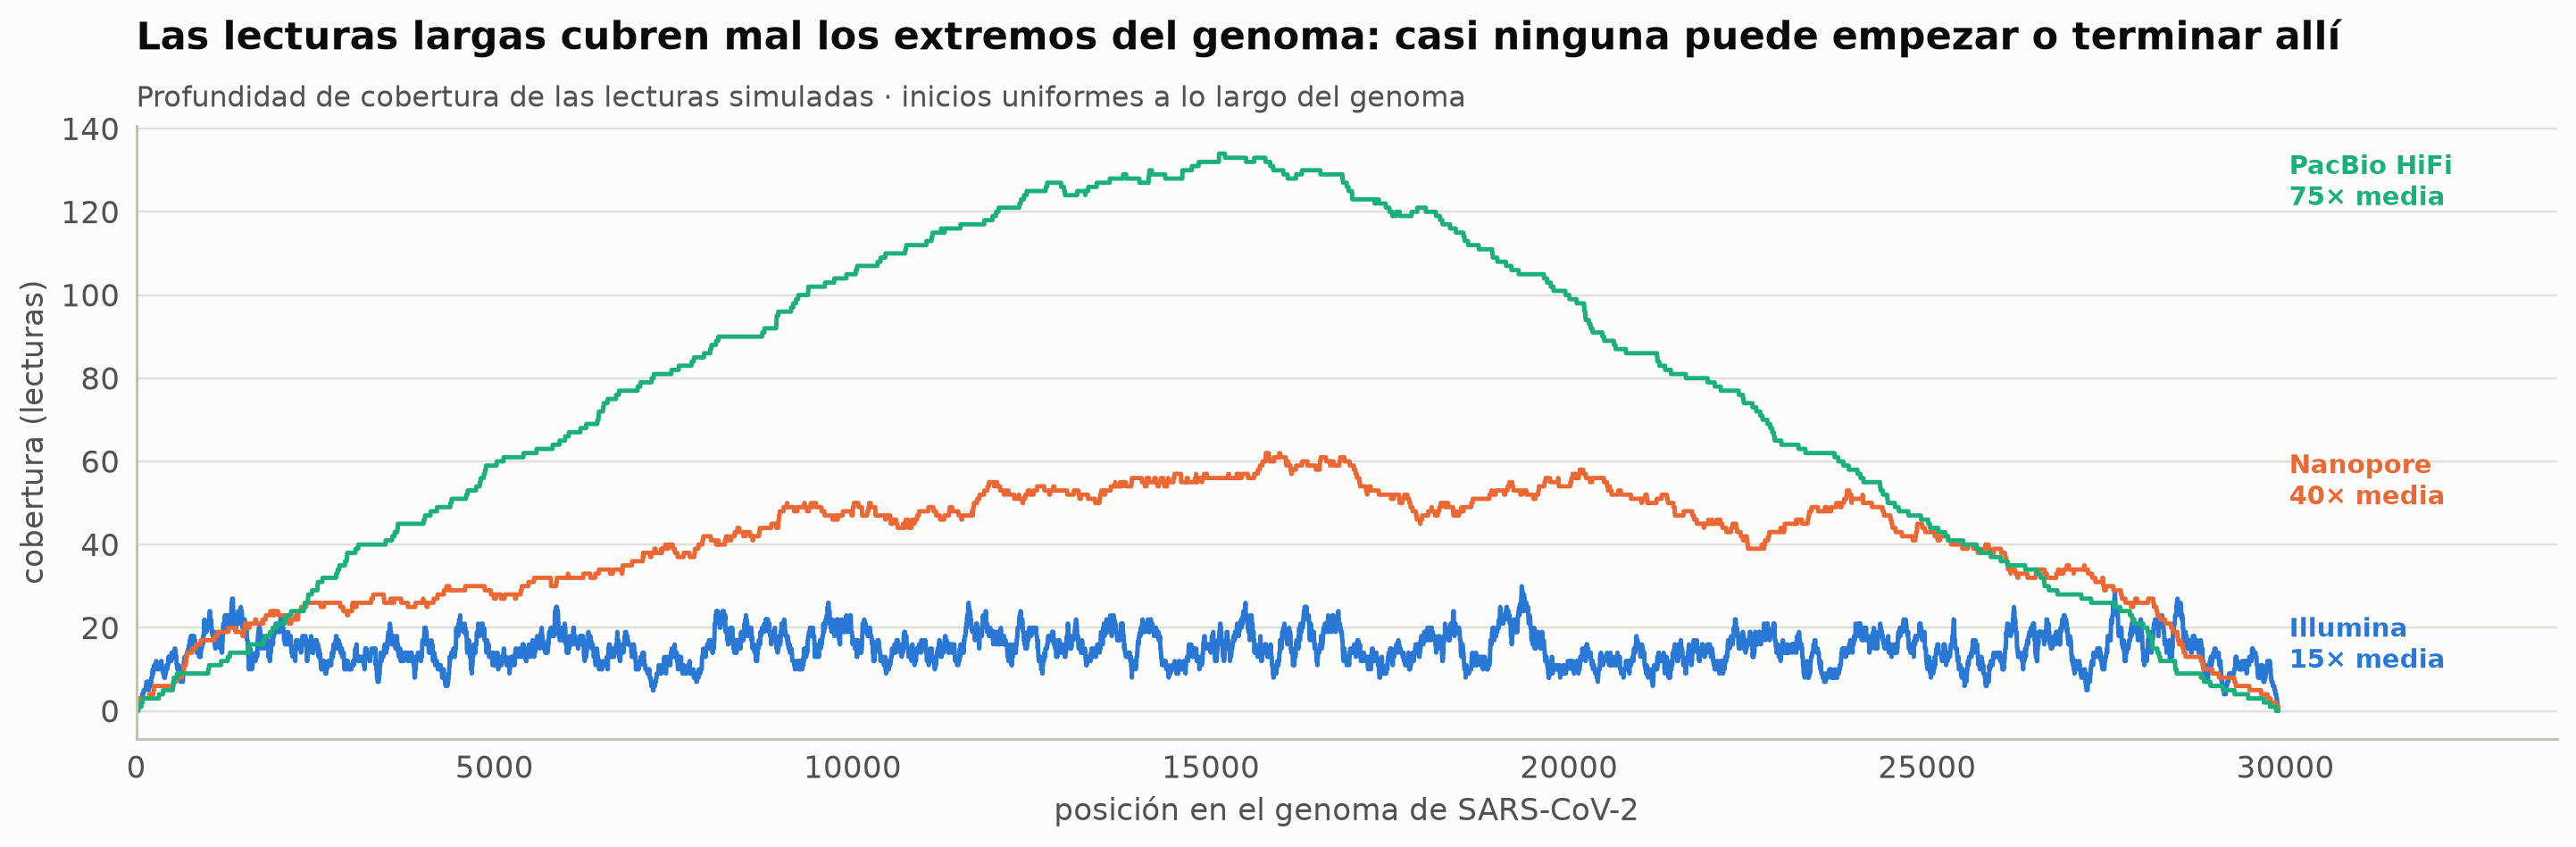

In [29]:
fig, ax = plt.subplots(figsize=(13, 4.2))
for t in TECHS:
    cov = np.zeros(len(GENOME) + 1)
    d = reads[reads.tech == t]
    np.add.at(cov, d.start.values, 1); np.add.at(cov, (d.start + d.length).values, -1)
    cov = np.cumsum(cov)[:-1]
    ax.plot(np.arange(len(GENOME)), cov, color=TECH_COL[t], lw=1.6)
    ax.text(len(GENOME) * 1.005, cov[len(GENOME) // 2 - 3000:len(GENOME) // 2 + 3000].mean(),
            f"{t}\n{cov.mean():.0f}× media", color=TECH_COL[t], fontsize=9.5, fontweight="bold", va="center")
ax.set_xlim(0, len(GENOME) * 1.13); ax.set_xlabel("posición en el genoma de SARS-CoV-2"); ax.set_ylabel("cobertura (lecturas)")
ec.title(ax, "Las lecturas largas cubren mal los extremos del genoma: casi ninguna puede empezar o terminar allí",
         "Profundidad de cobertura de las lecturas simuladas · inicios uniformes a lo largo del genoma")
plt.show()

> 🔎 **Qué observamos.** La cobertura de Illumina es aproximadamente uniforme (con el ruido de un muestreo aleatorio de
> lecturas cortas). Con lecturas de 15 kb, una posición cercana al extremo sólo puede cubrirse por las pocas lecturas que
> empiezan justo allí: la cobertura dibuja una **rampa** en los primeros y últimos ~15 kb. En genomas grandes este
> efecto de borde es despreciable, pero en un virus de 30 kb o en los extremos de un cromosoma lineal (telómeros) importa.

### Explorador interactivo: longitud frente a precisión

Cada punto es una lectura. Pase el cursor para ver su identificador, dónde empieza en el genoma, su longitud y sus
errores de cada tipo. Haga clic en la leyenda para ocultar tecnologías.

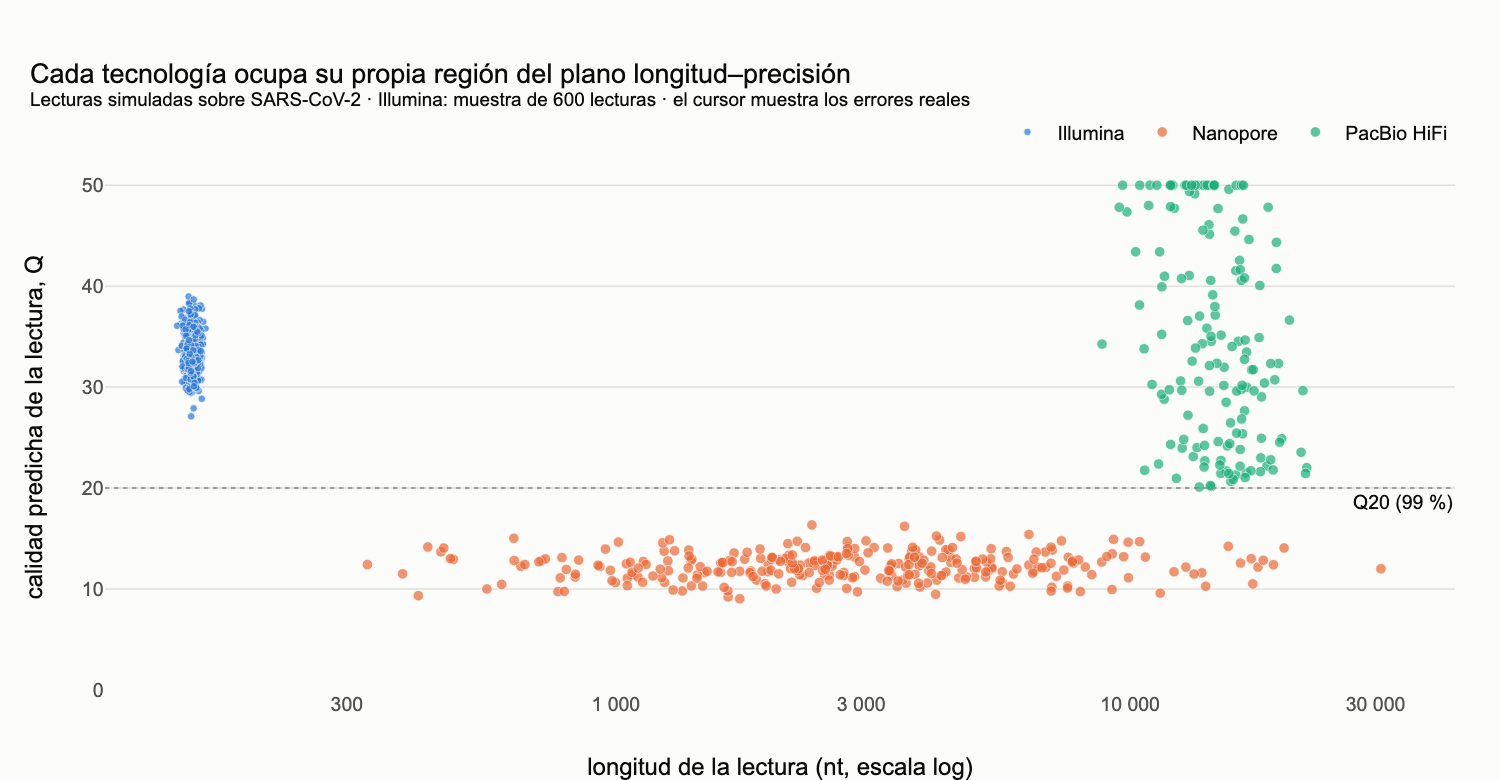

In [30]:
fig = go.Figure()
for t in TECHS:
    d = reads[reads.tech == t]
    if t == "Illumina":
        d = d.sample(600, random_state=1)
    fig.add_scatter(
        x=d.length * np.exp(rng.normal(0, 0.02, len(d))), y=d.Q_pred.clip(upper=50), mode="markers", name=t,
        marker=dict(size=7 if t != "Illumina" else 5, color=TECH_COL[t], opacity=0.7, line=dict(width=0.5, color="white")),
        customdata=np.c_[d.read, d.start + 1, d.length, d["sub"], d.ins, d.dele, d.identity * 100, d.hp_err, d.Q],
        hovertemplate=(f"<b>{t}</b> · %{{customdata[0]}}<br>inicio en el genoma: %{{customdata[1]:,}}"
                       "<br>longitud: %{customdata[2]:,} nt<br>sustituciones: %{customdata[3]} · inserciones: "
                       "%{customdata[4]} · deleciones: %{customdata[5]}<br>errores en homopolímeros: %{customdata[7]}"
                       "<br>identidad observada: <b>%{customdata[6]:.2f} %</b> (Q obs. %{customdata[8]:.1f})"
                       "<br>calidad predicha: Q = %{y:.1f}<extra></extra>"))
fig.add_hline(y=20, line=dict(color=ec.MUTED, dash="dot", width=1), annotation_text="Q20 (99 %)",
              annotation_position="bottom right")
fig.update_layout(
    title=dict(text="Cada tecnología ocupa su propia región del plano longitud–precisión<br>"
                    "<sup>Lecturas simuladas sobre SARS-CoV-2 · Illumina: muestra de 600 lecturas · el cursor muestra los errores reales</sup>"),
    xaxis=dict(title="longitud de la lectura (nt, escala log)", type="log",
               tickvals=[100, 300, 1000, 3000, 10000, 30000], ticktext=["100", "300", "1 000", "3 000", "10 000", "30 000"]),
    yaxis=dict(title="calidad predicha de la lectura, Q", range=[0, 52]), height=520,
    margin=dict(t=110, l=70, r=30, b=60), legend=dict(orientation="h", yanchor="bottom", y=1.02, x=1, xanchor="right"))
fig.show()

## 10. Tabla comparativa final

Valores **aproximados**, de orden de magnitud, para los equipos disponibles hacia 2024. El rendimiento y el costo cambian
cada año, así que tómelos como una guía para comparar, no como cifras de catálogo.

| | **Sanger** (capilar) | **Illumina** (SBS) | **Oxford Nanopore** | **PacBio HiFi** |
|---|---|---|---|---|
| Principio | terminadores didesoxi + electroforesis | síntesis con terminadores reversibles sobre clústeres | corriente iónica a través de un poro, molécula única | fluorescencia en tiempo real, molécula única, consenso circular |
| Longitud de lectura | 400–800 nt (hasta ~1 000 en capilares optimizados) | 2 × 50 a 2 × 300 nt | típicamente 1–100 kb; hay lecturas de más de 1 Mb | 10–25 kb |
| Precisión por lectura | ~99.9 % en la zona central | > 99.9 % en la mayoría de las bases (Q30+) | ≈85–95 % (R9); ~99 % o más (R10.4.1 con *basecalling* de alta precisión) | ≥ 99 % por definición (Q20+), típicamente ~99.9 % |
| Error dominante | picos débiles al inicio y al final | sustituciones, crecientes con el ciclo; poli-G en 2 colores | indels, sobre todo en homopolímeros | indels residuales en homopolímeros |
| Rendimiento por corrida | ~96 lecturas (< 0.1 Mb) | de Gb (MiSeq) a varios Tb (NovaSeq) | decenas de Gb (MinION) a cientos de Gb (PromethION) por celda | decenas de Gb por celda |
| Costo relativo por Gb | altísimo (miles de USD por Mb) | el más bajo | bajo a medio | medio |
| Tiempo y equipo | horas; equipo de laboratorio | 1–3 días; equipo grande | minutos a días; el MinION cabe en la mano y lee en tiempo real | ~1 día; equipo grande |
| Usos típicos | confirmar variantes, verificar clones y plásmidos | resecuenciación, exomas, RNA-seq, metagenómica, vigilancia de virus | ensamblaje, variantes estructurales, secuenciación en campo, ARN directo, metilación | ensamblaje de alta calidad, variantes estructurales, haplotipos, isoformas completas (Iso-Seq) |

> 🔎 **Cómo elegir.** No hay una tecnología "mejor": se elige según la pregunta. Para contar variantes de un nucleótido
> en muchas muestras (vigilancia de SARS-CoV-2, exomas clínicos), el bajo costo y la alta precisión de Illumina son
> imbatibles. Para ensamblar un genoma nuevo, resolver regiones repetidas o detectar grandes reordenamientos, hacen falta
> lecturas largas (Nanopore o HiFi). Y para confirmar una variante puntual en un paciente, un Sanger sigue siendo lo más
> simple. Cada vez más proyectos **combinan** tecnologías: lecturas largas para el esqueleto y cortas para pulir.

## ✍️ Ejercicios

**Ejercicio 1 — Sanger y la proporción de ddNTP.** Usando $P(K = k) = (1-r)^{k-1} r$ (con $r$ por aparición de la
base y $\ell \approx 4k$), calcule para $r = 0.005$, $0.01$ y $0.02$ qué fracción de los fragmentos de un canal termina
entre las posiciones 600 y 900 (apariciones $k = 150$ a $225$). ¿Qué $r$ elegiría para leer bien esa zona? ¿Qué se
sacrifica?

**Ejercicio 2 — Phasing.** ¿En qué ciclo cae por debajo del 50 % la fracción en fase para $p + q = 0.003$ y para
$p + q = 0.006$? Calcúlelo con la cota $\phi(n) = (1-\varepsilon)^n$ y con `phase_matrix` (use $q = p/2$).

**Ejercicio 3 — Un *basecaller* que usa el tiempo.** Nuestro *basecaller* llama 5 T donde hay 8. Mejórelo: cuando un
segmento corresponde a un k-mero homopolimérico (`AAAAA`, `CCCCC`, `GGGGG`, `TTTTT`), estime cuántos k-meros había con
$\text{round}(\text{duración} / 9)$ (9 muestras es la permanencia media) y añada las bases que falten. Mida de nuevo la
distribución de longitudes del homopolímero en 40 moléculas.

**Ejercicio 4 — ¿Cuántas pasadas?** Con un error por pasada de $e = 0.15$, ¿cuántas pasadas (impares) hacen falta para
llegar a Q30 según la fórmula de mayoría? ¿Y con $e = 0.05$?

**Ejercicio 5 — Nanopore moderno.** Añada al simulador un perfil "Nanopore R10.4.1" con $p_{\text{sust}} = 0.004$,
$p_{\text{ins}} = 0.002$, $p_{\text{del}} = 0.004$ (y 0.02 en homopolímeros) y compare su Q mediana con la del perfil
tipo R9.

In [31]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
k = np.arange(1, 2001)                                   # apariciones de la base b (ℓ ≈ 4k)
for r in (0.005, 0.01, 0.02):
    P = (1 - r) ** (k - 1) * r
    frac = P[(k >= 150) & (k <= 225)].sum()               # = (1-r)^149 - (1-r)^225
    print(f"r = {r:<6} fracción en 600–900 pb = {frac:.3f}   E[K] = 1/r = {1 / r:.0f} apariciones ≈ {4 / r:.0f} pb")
print("Con r = 0.005 la distribución es más plana y hay más fragmentos largos, pero cada pico recibe menos señal")
print("(P(K = k) ≤ r): hace falta más molde, y la resolución del capilar sigue limitando las bases más lejanas.")

r = 0.005  fracción en 600–900 pb = 0.150   E[K] = 1/r = 200 apariciones ≈ 800 pb
r = 0.01   fracción en 600–900 pb = 0.119   E[K] = 1/r = 100 apariciones ≈ 400 pb
r = 0.02   fracción en 600–900 pb = 0.039   E[K] = 1/r = 50 apariciones ≈ 200 pb
Con r = 0.005 la distribución es más plana y hay más fragmentos largos, pero cada pico recibe menos señal
(P(K = k) ≤ r): hace falta más molde, y la resolución del capilar sigue limitando las bases más lejanas.


In [32]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
for s in (0.003, 0.006):
    p, q = 2 * s / 3, s / 3
    n_approx = np.log(0.5) / np.log(1 - s)
    Wx = phase_matrix(600, p, q)
    n_exact = next(n for n in range(1, 601) if Wx[n - 1, n] < 0.5)
    print(f"p + q = {s}: aproximación n = {n_approx:.0f} ciclos · recursión exacta n = {n_exact} ciclos")
print("Duplicar el desfase reduce a la mitad los ciclos útiles.")

p + q = 0.003: aproximación n = 231 ciclos · recursión exacta n = 282 ciclos
p + q = 0.006: aproximación n = 115 ciclos · recursión exacta n = 141 ciclos
Duplicar el desfase reduce a la mitad los ciclos útiles.


In [33]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
HOMO = {KIDX[KMERS == b * K][0] for b in BASES}

def viterbi_path(means, tau=0.8, p_stay=0.2, p_skip=0.2):
    """Como viterbi_basecall, pero devuelve el k-mero y el movimiento de cada segmento."""
    p_step = 1 - p_stay - p_skip
    tt = KIDX
    V = -0.5 * ((means[0] - LEVELS) / tau) ** 2
    back = []
    for m in means[1:]:
        r1 = V.reshape(4, -1); r2 = V.reshape(16, -1)
        cand = np.vstack([V + np.log(p_stay), r1.max(0)[tt // 4] + np.log(p_step / 4),
                          r2.max(0)[tt // 16] + np.log(p_skip / 16)])
        kind = cand.argmax(0)
        prev = np.choose(kind, [tt, r1.argmax(0)[tt // 4] * 4 ** (K - 1) + tt // 4,
                                r2.argmax(0)[tt // 16] * 4 ** (K - 2) + tt // 16])
        back.append((prev, kind)); V = cand.max(0) - 0.5 * ((m - LEVELS) / tau) ** 2
    s = int(V.argmax()); path, kinds = [s], []
    for prev, kind in reversed(back):
        kinds.append(kind[s]); s = int(prev[s]); path.append(s)
    return path[::-1], kinds[::-1]                      # kinds[j-1] = movimiento que lleva al segmento j

def basecall_with_dwell(sig, mean_dwell=9.0):
    b = segment_signal(sig)
    means = np.array([sig[x:y].mean() for x, y in zip(b[:-1], b[1:])])
    durs = np.diff(b)
    path, kinds = viterbi_path(means)
    seq = KMERS[path[0]]
    extra0 = max(0, int(round(durs[0] / mean_dwell)) - 1) if path[0] in HOMO else 0
    seq += KMERS[path[0]][-1] * extra0
    for j in range(1, len(path)):
        kd = kinds[j - 1]
        seq += {0: "", 1: KMERS[path[j]][-1], 2: KMERS[path[j]][-2:]}[kd]
        if path[j] in HOMO and kd != 0:
            seq += KMERS[path[j]][-1] * max(0, int(round(durs[j] / mean_dwell)) - 1)
    return seq

hp_new = []
for rep in range(40):
    s_, _, _ = squiggle(region, np.random.default_rng(100 + rep))
    runs_ = [len(m.group()) for m in re.finditer(r"T{4,}", basecall_with_dwell(s_))]
    hp_new.append(max(runs_) if runs_ else 0)
print("Sin usar el tiempo:", Counter(hp_counts.tolist()).most_common())
print("Usando el tiempo:  ", Counter(hp_new).most_common())
ops_old = align_ops(ont_true, viterbi_basecall(seg_means)); ops_new = align_ops(ont_true, basecall_with_dwell(sig_l))
print(f"Identidad en la lectura de 3 kb: {1 - ops_old['distancia'] / len(ont_true):.1%} → "
      f"{1 - ops_new['distancia'] / len(ont_true):.1%}")
print(f"Error medio en la longitud: {np.abs(hp_counts - 8).mean():.2f} → {np.abs(np.array(hp_new) - 8).mean():.2f} bases")
print("La duración ayuda, pero es muy ruidosa (Gamma de forma 2): el largo exacto sigue siendo difícil de acertar.")

Sin usar el tiempo: [(5, 38), (4, 2)]
Usando el tiempo:   [(7, 11), (8, 8), (6, 6), (9, 6), (5, 3), (4, 2), (10, 2), (11, 1), (12, 1)]


Identidad en la lectura de 3 kb: 87.6% → 87.6%
Error medio en la longitud: 3.05 → 1.43 bases
La duración ayuda, pero es muy ruidosa (Gamma de forma 2): el largo exacto sigue siendo difícil de acertar.


In [34]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
for e in (0.15, 0.10, 0.05):
    n = next(n for n in range(1, 200, 2) if majority_error(e, n) < 1e-3)
    print(f"e = {e}: {n} pasadas para Q30 (P_error = {majority_error(e, n):.1e})")

e = 0.15: 15 pasadas para Q30 (P_error = 6.1e-04)
e = 0.1: 9 pasadas para Q30 (P_error = 8.9e-04)
e = 0.05: 7 pasadas para Q30 (P_error = 1.9e-04)


In [35]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
rng_r10 = np.random.default_rng(10)
rows10 = []
for i in range(300):
    L = int(np.clip(rng_r10.lognormal(np.log(3000), 0.9), 200, len(GENOME)))
    s = int(rng_r10.integers(0, len(GENOME) - L + 1))
    tmpl_seq = GENOME[s:s + L]
    hp = homopolymer_mask(tmpl_seq)
    rd, a, b, c = mutate(tmpl_seq, 0.004, 0.002, np.where(hp, 0.02, 0.004), rng_r10)
    rows10.append(record("Nanopore R10.4.1", i, s, tmpl_seq, rd, a, b, c, 0.006 + np.where(hp, 0.02, 0.004)))
r10 = pd.DataFrame(rows10)
print(f"Q observada mediana tipo R9:      {reads[reads.tech == 'Nanopore'].Q.median():.1f}")
print(f"Q observada mediana tipo R10.4.1: {r10.Q.median():.1f}")
print(f"Fracción de errores en homopolímeros (R10.4.1): {r10.hp_err.sum() / r10.errors.sum():.0%}")

Q observada mediana tipo R9:      12.2
Q observada mediana tipo R10.4.1: 19.5
Fracción de errores en homopolímeros (R10.4.1): 15%


## 📌 Resumen

* El costo por megabase (NHGRI) cayó unas 900 000 veces entre 2001 y 2022; en 2008 la llegada de la **NGS**, que lee
  millones de moléculas en paralelo, hizo que se despegara de la ley de Moore.
* **Sanger**: los ddNTP sin 3′-OH terminan la cadena; el número de apariciones atravesadas sigue una geométrica
  $(1-r)^{k-1}r$, la señal decae como $(1-r)^{\ell/4}$ y la electroforesis capilar ordena los fragmentos. Lecturas de
  400–800 nt (hasta ~1 000 en capilares optimizados) muy precisas, pero una por capilar.
* **Pirosecuenciación (454) e Ion Torrent**: leen por flujos de un solo nucleótido; la señal de un homopolímero es
  proporcional a su longitud y el ruido crece con ella, de ahí sus **indels en homopolímeros**.
* **Illumina**: librería con adaptadores (P5/P7, índices), clústeres por amplificación en puente y **secuenciación por
  síntesis** con terminadores reversibles, en 4 o 2 colores. En 2 colores la G es "oscuridad", de ahí las colas de poli-G.
* El **phasing / pre-phasing** hace que la fracción de hebras nunca desfasadas caiga como $\phi(n) = (1-\varepsilon)^n$, con $\varepsilon = p + q$ (cota inferior de la fracción en fase): de ahí la caída de la
  calidad con el ciclo que en la Lección 2.1 habíamos supuesto.
* Las lecturas **pareadas** leen ambos extremos de un inserto; su tamaño indica solapamiento, huecos o lectura de
  adaptador, y los pares discordantes delatan variantes estructurales.
* **Nanopore**: la corriente depende del k-mero dentro del poro; leerla es un problema de estados ocultos (Viterbi). Los
  homopolímeros más largos que $k$ dan escalones planos y, por tanto, **indels**.
* **PacBio HiFi**: el consenso circular convierte pasadas con ~10 % de error en lecturas ≥ Q20; la precisión crece con
  el número de pasadas **si los errores son independientes**.
* Cada tecnología tiene su propio **perfil de error** (sustituciones frente a indels, longitud), y eso condiciona las
  herramientas de control de calidad, alineamiento y llamado de variantes de las próximas lecciones.

## 📚 Para profundizar

* Sanger, F., Nicklen, S. & Coulson, A. R. (1977). DNA sequencing with chain-terminating inhibitors. *Proceedings of the
  National Academy of Sciences USA* 74(12): 5463–5467.
* Ronaghi, M., Uhlén, M. & Nyrén, P. (1998). A sequencing method based on real-time pyrophosphate. *Science*
  281(5375): 363–365.
* Margulies, M. et al. (2005). Genome sequencing in microfabricated high-density picolitre reactors. *Nature*
  437(7057): 376–380.
* Metzker, M. L. (2010). Sequencing technologies — the next generation. *Nature Reviews Genetics* 11(1): 31–46.
* Ewing, B. & Green, P. (1998). Base-calling of automated sequencer traces using *phred*. II. Error probabilities.
  *Genome Research* 8(3): 186–194.
* Bentley, D. R. et al. (2008). Accurate whole human genome sequencing using reversible terminator chemistry. *Nature*
  456(7218): 53–59.
* Eid, J. et al. (2009). Real-time DNA sequencing from single polymerase molecules. *Science* 323(5910): 133–138.
* Wenger, A. M. et al. (2019). Accurate circular consensus long-read sequencing improves variant detection and assembly
  of a human genome. *Nature Biotechnology* 37(10): 1155–1162.
* Jain, M., Olsen, H. E., Paten, B. & Akeson, M. (2016). The Oxford Nanopore MinION: delivery of nanopore sequencing to
  the genomics community. *Genome Biology* 17: 239.
* Deamer, D., Akeson, M. & Branton, D. (2016). Three decades of nanopore sequencing. *Nature Biotechnology* 34(5):
  518–524.
* Goodwin, S., McPherson, J. D. & McCombie, W. R. (2016). Coming of age: ten years of next-generation sequencing
  technologies. *Nature Reviews Genetics* 17(6): 333–351.
* Quick, J. et al. (2017). Multiplex PCR method for MinION and Illumina sequencing of Zika and other virus genomes
  directly from clinical samples. *Nature Protocols* 12(6): 1261–1276.
* Wetterstrand, K. A. *DNA Sequencing Costs: Data from the NHGRI Genome Sequencing Program (GSP)*.
  www.genome.gov/sequencingcostsdata (datos de mayo de 2022).

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)